# Diagnóstico de marca empleadora — Barclays frente a su grupo de referencia
## Sentiment analysis (transformers) y topic modeling (BERTopic) sobre reseñas de Glassdoor

**Encargo de RRHH.** Identificar, a partir de las reseñas públicas de Glassdoor, los puntos fuertes de Barclays como empleador (explotables en employer branding y selección) y las áreas de mejora que pueden estar dañando su reputación o provocando la salida de empleados, comparándolos con los de sus competidores directos. Un problema solo se considera prioritario si la empresa está peor que el mercado.

**Datos.** Glassdoor Job Reviews 1 y 2 (D. Gauthier, Kaggle), en un único fichero Parquet preparado por el profesor: reseñas de empresas con al menos 300 reseñas, entre julio de 2018 y abril de 2023 (fecha de la última reseña presente en los datos). No hay variable objetivo: se trata de un análisis descriptivo de texto, no de un problema de predicción.

**Empresa y peers.** Se analiza Barclays (9.863 reseñas disponibles) y se compara con HSBC (13.173), Standard-Chartered-Bank (5.499), Deutsche-Bank (5.474) y NatWest-Group (4.715). Los cinco figuran en la lista facilitada dentro del sector Banca, tienen un volumen de reseñas del mismo orden de magnitud y son bancos con sede o presencia relevante en Reino Unido, por lo que compiten por un perfil de talento similar. En el caso de HSBC se utiliza el perfil `HSBC` y no `HSBC-Holdings`, por las razones que se explican en el apartado 0.7.

| Sección | Contenido |
|---|---|
| 0 | Entorno, carga y preparación de los datos |
| 1 | EDA |
| 2 | Sentimiento en pros y cons (control de calidad) |
| 3 | Topic modeling con BERTopic |
| 4 | Comparación con peers |
| 5 | Empleados actuales vs antiguos |
| 6 | Áreas de mejora y recomendaciones |
| 7 | Extra: evolución temporal y análisis por recomendación y antigüedad |
| 8 | Conclusiones finales |

---
## 0. Entorno, carga y preparación de los datos

### 0.1 Entorno de ejecución

El notebook se ha ejecutado en local con Python 3.12.5 y sin GPU, por lo que todos los modelos transformer de las secciones 2 y 3 corren en CPU y los tiempos indicados se refieren a ese entorno. La celda siguiente imprime las versiones de las librerías clave para dejar constancia del entorno y facilitar la reproducibilidad. Las líneas de instalación, comentadas, solo hacen falta si algún paquete no está presente. Se incluye `pyarrow` porque `pandas` lo necesita para leer el fichero Parquet.

In [44]:
# Si falta algún paquete, instalarlo con:
# pip install bertopic sentence-transformers pyarrow

import sys
from importlib.metadata import version, PackageNotFoundError

PAQUETES = ["pandas", "numpy", "pyarrow", "matplotlib", "seaborn", "scikit-learn",
            "transformers", "torch", "bertopic", "sentence-transformers",
            "umap-learn", "hdbscan"]

print("Python", sys.version.split()[0])
for paquete in PAQUETES:
    try:
        print(f"{paquete}=={version(paquete)}")
    except PackageNotFoundError:
        print(f"{paquete}: NO instalado")

Python 3.12.5
pandas==3.0.6
numpy==2.5.3
pyarrow==25.0.1
matplotlib==3.11.2
seaborn==0.13.2
scikit-learn==1.9.1
transformers==5.19.0
torch==2.14.1
bertopic==0.17.4
sentence-transformers==6.1.0
umap-learn==0.5.12
hdbscan==0.8.44


In [45]:
# import sys
# !{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn pyarrow transformers torch bertopic sentence-transformers umap-learn hdbscan

### 0.2 Parámetros y librerías
Todos los parámetros se definen al principio para que el notebook sea reproducible y la empresa o los peers puedan cambiarse sin tocar el resto del código. Se fija una semilla en todas las fuentes de aleatoriedad.

El tope de 2.000 reseñas por empresa (10.000 en total) sigue la recomendación del enunciado: acota el tiempo de cómputo de los modelos y evita que la empresa con más reseñas domine el modelo de topics conjunto. Una prueba sobre 200 pros arrojó unos 0,02 segundos por texto, lo que hacía prever unos 6 minutos para clasificar los 20.000 textos en CPU; el cómputo real, que incluye los cons (más largos), tardó 10,5 minutos. Es un tiempo asumible, por lo que se mantiene el tope de 2.000 reseñas por empresa.

In [46]:
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Empresa objetivo y peers (nombres tal como aparecen en Glassdoor)
TARGET = "Barclays"
# HSBC: se usa el perfil completo "HSBC"; "HSBC-Holdings" se descarta (ver 0.7)
PEERS = ["HSBC", "Standard-Chartered-Bank", "NatWest-Group", "Deutsche-Bank"]
FIRMS = [TARGET] + PEERS


MAX_POR_EMPRESA = 2000
RUTA_PARQUET = "glassdoor_reviews_hr.parquet"

### 0.3 Carga y comprobación de los datos brutos

Se lee solo el subconjunto de empresas necesarias (filtro en `read_parquet`) y, antes de transformar nada, se verifica: que estén todas las empresas, la estructura y los nulos, los duplicados, la ventana temporal (el enunciado indica de julio de 2018 a julio de 2023), el rango del rating (1–5) y los valores reales de `recommend` y `current`. Estas comprobaciones evitan arrastrar errores a las secciones posteriores.

In [47]:
raw = pd.read_parquet(RUTA_PARQUET, engine="pyarrow", filters=[("firm", "in", FIRMS)])

# Estructura general
print("Dimensiones:", raw.shape)
print(raw.dtypes)

Dimensiones: (38724, 7)
firm                  str
date_review        object
current               str
overall_rating    float64
recommend             str
pros                  str
cons                  str
dtype: object


In [48]:
# Todas las empresas presentes y volumen disponible
faltan = set(FIRMS) - set(raw["firm"].unique())
assert not faltan, f"Empresas no encontradas: {faltan}"
print("Reseñas disponibles por empresa:")
print(raw["firm"].value_counts())

Reseñas disponibles por empresa:
firm
HSBC                       13173
Barclays                    9863
Standard-Chartered-Bank     5499
Deutsche-Bank               5474
NatWest-Group               4715
Name: count, dtype: int64


In [49]:
# Nulos (proporción por columna) y duplicados exactos
print("Proporción de nulos:")
print(raw.isna().mean().round(4), "\n")
print("Filas duplicadas:", raw.duplicated().sum())

Proporción de nulos:
firm              0.0
date_review       0.0
current           0.0
overall_rating    0.0
recommend         0.0
pros              0.0
cons              0.0
dtype: float64 

Filas duplicadas: 0


In [50]:
# Ventana temporal y rango del rating
print("Ventana temporal:", raw["date_review"].min(), "->", raw["date_review"].max())
print("Rating mínimo / máximo:", raw["overall_rating"].min(), "/", raw["overall_rating"].max())

Ventana temporal: 2018-07-27 -> 2023-04-18
Rating mínimo / máximo: 1.0 / 5.0


In [51]:
# Valores reales de las categóricas
print("recommend:")
print(raw["recommend"].value_counts(dropna=False), "\n")
print("current (10 más frecuentes):")
print(raw["current"].value_counts(dropna=False).head(10))

recommend:
recommend
v    17884
o    14750
x     6090
Name: count, dtype: int64 

current (10 más frecuentes):
current
Current Employee                       10287
Former Employee                         5123
Current Employee, more than 1 year      3729
Current Employee, more than 3 years     3545
Former Employee, more than 1 year       2745
Current Employee, more than 5 years     2463
Former Employee, more than 3 years      2229
Current Employee, less than 1 year      1785
Former Employee, more than 5 years      1431
Current Employee, more than 8 years     1335
Name: count, dtype: int64


El fichero contiene 38.724 reseñas de las cinco empresas y siete columnas, y todas las empresas elegidas están presentes (HSBC 13.173, Barclays 9.863, Standard-Chartered-Bank 5.499, Deutsche-Bank 5.474 y NatWest-Group 4.715). No hay valores nulos en ninguna columna ni filas duplicadas, el rating se mueve entre 1 y 5 y `recommend` solo toma los tres valores documentados: `v` (17.884 reseñas, 46,2 %), `o` (14.750, 38,1 %) y `x` (6.090, 15,7 %). Por tanto, no hace falta imputar ni eliminar registros.

La ventana temporal va del 27 de julio de 2018 al 18 de abril de 2023. El enunciado habla de julio de 2023, pero la última reseña disponible es de abril, de modo que 2018 y 2023 son años parciales y se interpretarán con cautela en la evolución temporal. La columna `current` contiene 15.410 reseñas (el 39,8 %) que indican solo "Current Employee" o "Former Employee", sin antigüedad; esa información no se puede recuperar y limitará el análisis por antigüedad del apartado extra.

### 0.4 Muestra de trabajo

Se toma una muestra aleatoria de hasta `MAX_POR_EMPRESA` reseñas por empresa con semilla fija. Después se comprueba que cada empresa conserva un tamaño razonable y que el rating medio de la muestra se parece al de la población, para asegurar que el muestreo no introduce sesgos apreciables.

In [52]:
partes = [
    g.sample(n=min(MAX_POR_EMPRESA, len(g)), random_state=SEED)
    for _, g in raw.groupby("firm")
]
df = pd.concat(partes, ignore_index=True)

# Comparación población vs. muestra
comparacion = pd.DataFrame({
    "n_poblacion": raw.groupby("firm").size(),
    "n_muestra": df.groupby("firm").size(),
    "rating_poblacion": raw.groupby("firm")["overall_rating"].mean().round(3),
    "rating_muestra": df.groupby("firm")["overall_rating"].mean().round(3),
})
comparacion["dif_rating"] = (comparacion["rating_muestra"] - comparacion["rating_poblacion"]).round(3)
print(f"Muestra de trabajo: {len(df):,} reseñas")
comparacion

Muestra de trabajo: 10,000 reseñas


,n_poblacion,n_muestra,rating_poblacion,rating_muestra,dif_rating
firm,,,,,
Barclays,9863,2000,3.890,3.886,-0.004
Deutsche-Bank,5474,2000,3.729,3.714,-0.015
HSBC,13173,2000,3.737,3.742,0.005
NatWest-Group,4715,2000,3.848,3.843,-0.005
Standard-Chartered-Bank,5499,2000,3.836,3.821,-0.015


La muestra final tiene 10.000 reseñas, 2.000 por empresa, lo que supone entre el 15 % (HSBC) y el 42 % (NatWest-Group) de las reseñas disponibles de cada una. Igualar el tamaño de las cinco empresas tiene una ventaja metodológica: el modelo de topics conjunto de la sección 3 da el mismo peso a cada empresa, de forma que ninguna, por tener más reseñas, condiciona los temas que se identifican.

El muestreo no introduce un sesgo apreciable en la variable principal: el rating medio de la muestra se desvía como máximo 0,015 puntos del de la población (por ejemplo, Barclays 3,886 frente a 3,890 y HSBC 3,742 frente a 3,737). Con una diferencia tan pequeña, trabajar con la muestra no cambia las conclusiones y reduce el tiempo de cómputo de los modelos.

### 0.5 Variables derivadas y limpieza básica

La columna `current` mezcla la situación laboral y la antigüedad (por ejemplo, "Former Employee, more than 3 years"), por lo que se separa en dos variables. `recommend` se traduce a etiquetas legibles (v = Sí, o = Sin opinión, x = No). La limpieza del texto se limita a rellenar los nulos con cadena vacía y normalizar espacios y saltos de línea; no se pasa a minúsculas ni se eliminan signos porque los modelos transformer los aprovechan. Rellenar los nulos antes de convertir a texto evita que un valor ausente se convierta en la palabra "nan" y llegue al modelo como si fuera una opinión.

Las reseñas pueden contener marcadores vacíos en lugar de contenido real ("None", "N/A", "Nothing"...). Generarían sentimientos y topics espurios, así que se marcan sin eliminarlos todavía. La detección usa una lista parametrizada y `fullmatch`, de modo que solo se marca el texto que **es exactamente** uno de esos marcadores y no el que simplemente los contiene (por ejemplo, "Nothing special about the pay" no se marca).

In [53]:
def situacion(texto):
    t = str(texto).lower()
    if t.startswith("current"):
        return "Actual"
    if t.startswith("former"):
        return "Antiguo"
    return "Desconocido"

# Antigüedad: "less/more than N year(s)"; si no aparece, n/d
PATRON_ANTIGUEDAD = re.compile(r"(less|more) than (\d+) year", re.IGNORECASE)

def antiguedad(texto):
    m = PATRON_ANTIGUEDAD.search(str(texto))
    return f"{m.group(1).lower()} than {m.group(2)}y" if m else "n/d"

df["situacion"] = df["current"].map(situacion)
df["antiguedad"] = df["current"].map(antiguedad)
df["recomienda"] = df["recommend"].map({"v": "Sí", "o": "Sin opinión", "x": "No"})
df["date_review"] = pd.to_datetime(df["date_review"])
df["anio"] = df["date_review"].dt.year

# Normalizar espacios y saltos de línea en el texto
for col in ["pros", "cons"]:
    df[col] = df[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

# Marcadores vacíos: texto formado solo por uno de estos términos (o por signos)
MARCADORES_VACIOS = ["none", "n/a", "na", "nothing", "nil", "nan", "no pros", "no cons", "no"]
patron_vacio = re.compile(
    r"\W*(?:" + "|".join(re.escape(m) for m in MARCADORES_VACIOS) + r")?\W*",
    re.IGNORECASE,
)
for col in ["pros", "cons"]:
    df[f"{col}_vacio"] = df[col].apply(lambda t: bool(patron_vacio.fullmatch(t)))
    df[f"{col}_palabras"] = df[col].str.split().str.len()

Se separa `current` en situación y antigüedad con una función y un patrón regular parametrizado (`PATRON_ANTIGUEDAD`), de modo que la antigüedad solo se extrae cuando el texto contiene exactamente la estructura "less/more than N year" y, en caso contrario, queda como `n/d` en lugar de forzar un valor. La traducción de `recommend` sigue la definición del enunciado: `v` es "Sí", `o` es "Sin opinión" y `x` es "No". En el texto se conservan mayúsculas y signos porque los modelos transformer los utilizan, y los nulos se rellenan antes de convertir a texto para que un valor ausente no llegue al modelo como la palabra "nan".

El detector de marcadores vacíos marca 5 reseñas, todas en la columna `cons` (una de Barclays, una de HSBC y tres de Standard-Chartered-Bank) y ninguna en `pros`. Se ha revisado cada caso a mano: cuatro contienen solo signos de puntuación y la quinta dice únicamente "No cons" seguido de puntuación y un emoticono. Por tanto, el uso de `fullmatch` evita falsos positivos: ningún texto con contenido real ha sido marcado. Las reseñas marcadas no se eliminan de `df` para no alterar los recuentos, sino que se excluirán de los análisis de sentimiento y de topics, donde no aportan información (el modelo de sentimiento las clasificaría de forma arbitraria y BERTopic podría agruparlas en un tema sin significado).

Este detector solo recoge los textos cuyo contenido es exactamente un marcador. No recoge frases del tipo "no tengo ningún contra" o "cannot think of any cons", que dicen que no hay contras pero con palabras. Se ha decidido no ampliar la lista para detectarlas, porque un patrón más amplio correría el riesgo de marcar reseñas con opinión real. Estos casos reaparecerán, previsiblemente, entre los casos discordantes del control de calidad del sentimiento (cons clasificados como positivos), y se analizarán ahí.

### 0.6 Verificación de las variables derivadas

Se revisa que las transformaciones no hayan generado categorías inesperadas: que no haya registros "Desconocido", que `antiguedad` y `situacion` sean coherentes con el texto original de `current`, cuántos textos son marcadores vacíos y cómo es la longitud de pros y cons (relevante para el truncado a 512 tokens de los modelos BERT).

In [54]:
print("Situación:")
print(df["situacion"].value_counts(), "\n")

# Cruce con el texto original para detectar patrones no contemplados
print("Antigüedad según el texto original (muestra):")
print(pd.crosstab(df["current"], df["antiguedad"]).head(12), "\n")

Situación:
situacion
Actual     6357
Antiguo    3643
Name: count, dtype: int64 

Antigüedad según el texto original (muestra):
antiguedad                            less than 1y  more than 10y  \
current                                                             
Current Employee                                 0              0   
Current Employee, less than 1 year             463              0   
Current Employee, more than 1 year               0              0   
Current Employee, more than 10 years             0            325   
Current Employee, more than 3 years              0              0   
Current Employee, more than 5 years              0              0   
Current Employee, more than 8 years              0              0   
Former Employee                                  0              0   
Former Employee, less than 1 year              270              0   
Former Employee, more than 1 year                0              0   
Former Employee, more than 10 years          

In [55]:
print("Recomendación (incluye nulos):")
print(df["recomienda"].value_counts(dropna=False), "\n")

print("Marcadores vacíos por empresa (%):")
print((df.groupby("firm")[["pros_vacio", "cons_vacio"]].mean() * 100).round(2), "\n")

print("Longitud en palabras de pros y cons:")
print(df[["pros_palabras", "cons_palabras"]].describe(percentiles=[.5, .9, .99]).round(1))

Recomendación (incluye nulos):
recomienda
Sí             4675
Sin opinión    3729
No             1596
Name: count, dtype: int64 

Marcadores vacíos por empresa (%):
                         pros_vacio  cons_vacio
firm                                           
Barclays                        0.0        0.05
Deutsche-Bank                   0.0        0.00
HSBC                            0.0        0.05
NatWest-Group                   0.0        0.00
Standard-Chartered-Bank         0.0        0.15 

Longitud en palabras de pros y cons:
       pros_palabras  cons_palabras
count        10000.0        10000.0
mean             9.2           12.1
std              8.4           21.2
min              3.0            3.0
50%              7.0            7.0
90%             15.0           20.0
99%             42.0           90.0
max            205.0          592.0


Las reseñas se reparten en 6.357 de empleados actuales (63,6 %) y 3.643 de antiguos (36,4 %), sin ningún registro "Desconocido", por lo que la función de situación cubre todos los casos. El cruce entre el texto original de `current` y la antigüedad extraída confirma que cada categoría se asigna correctamente (por ejemplo, "Current Employee, less than 1 year" y "Former Employee, less than 1 year" se convierten ambas en "less than 1y", y los textos sin antigüedad quedan como `n/d`). En cuanto a la recomendación, hay 4.675 reseñas "Sí" (46,8 %), 3.729 "Sin opinión" (37,3 %) y 1.596 "No" (16,0 %), que suman las 10.000 de la muestra.

Los textos son breves: tanto en pros como en cons la mediana es de 7 unidades separadas por espacios; el 90 % de los pros tiene como mucho 15 y el de los cons 20, y el 99 % no supera 42 y 90 respectivamente. El máximo (205 en pros y 592 en cons) corresponde a casos aislados. Dado que los modelos tipo BERT aceptan hasta 512 tokens, solo un número marginal de reseñas podría superar ese límite, y se resuelve con `truncation=True` sin pérdida relevante de información. La brevedad de los textos es también una buena noticia para BERTopic, que funciona bien con fragmentos cortos y centrados en un solo tema.

### 0.7 Revisión de los perfiles de HSBC

La lista de empresas facilitada incluye dos perfiles que parecen corresponder al mismo banco: `HSBC` (13.173 reseñas) y `HSBC-Holdings` (6.404). Antes de comparar, se comprueba qué periodo cubre cada uno y si comparten reseñas, porque un perfil que no cubra todo el periodo analizado distorsionaría la comparación con las demás empresas.

In [56]:
hsbc = pd.read_parquet(RUTA_PARQUET, filters=[("firm", "in", ["HSBC", "HSBC-Holdings"])])
hsbc["date_review"] = pd.to_datetime(hsbc["date_review"])
hsbc["anio"] = hsbc["date_review"].dt.year

print("Rango de fechas por perfil:")
print(hsbc.groupby("firm")["date_review"].agg(["min", "max", "count"]), "\n")
print("Reseñas por año y perfil:")
print(pd.crosstab(hsbc["anio"], hsbc["firm"]), "\n")

# ¿Hay reseñas idénticas en ambos perfiles?
clave = ["date_review", "overall_rating", "pros", "cons"]
solape = (hsbc[hsbc["firm"] == "HSBC"]
          .merge(hsbc[hsbc["firm"] == "HSBC-Holdings"], on=clave, how="inner"))
print("Reseñas idénticas entre los dos perfiles:", len(solape))

Rango de fechas por perfil:
                     min        max  count
firm                                      
HSBC          2018-07-27 2023-03-18  13173
HSBC-Holdings 2018-07-27 2021-06-05   6404 

Reseñas por año y perfil:
firm  HSBC  HSBC-Holdings
anio                     
2018   591            570
2019  1787           1717
2020  2168           2091
2021  3932           2026
2022  3984              0
2023   711              0 

Reseñas idénticas entre los dos perfiles: 6323


El perfil `HSBC` cubre todo el periodo, del 27 de julio de 2018 al 18 de marzo de 2023, con 13.173 reseñas, mientras que `HSBC-Holdings` termina el 5 de junio de 2021 con 6.404. De estas últimas, 6.323 aparecen idénticas (misma fecha, rating, pros y cons) en el perfil `HSBC`, es decir, casi todas, y los recuentos anuales de `HSBC-Holdings` son siempre inferiores a los de `HSBC`. Se concluye que `HSBC-Holdings` es esencialmente el tramo 2018–2021 del mismo perfil.

Por ello se utiliza `HSBC` y se descarta `HSBC-Holdings`. Unir ambos perfiles aportaría como máximo unas 80 reseñas adicionales (en torno al 0,6 %) y complicaría el tratamiento sin una ganancia apreciable. Con esta decisión se evitan dos problemas: contar dos veces las mismas reseñas y comparar a HSBC con el resto de bancos sobre un periodo más corto, sin ninguna reseña de 2022 ni de 2023, lo que habría sesgado el rating, la recomendación y los topics. Se comprobó, además, que ninguno de los otros cuatro bancos aparece duplicado en la lista de empresas facilitada.

### 0.8 Resumen de la validación de los datos

Las comprobaciones indican que los datos son aptos para el análisis. No hay filas duplicadas ni valores nulos, el rating y `recommend` toman los valores esperados, y la muestra de 2.000 reseñas por empresa reproduce el rating medio de la población con una desviación máxima de 0,015 puntos. Todas las reseñas se clasifican como empleado actual o antiguo. En HSBC se utiliza el perfil completo `HSBC` y se descarta `HSBC-Holdings`, que reproduce casi íntegramente su tramo 2018–2021 (apartado 0.7). Los textos son breves, los marcadores vacíos son residuales (5 reseñas, todas en `cons`) y se excluirán de los análisis de texto. Las reseñas abarcan de julio de 2018 a abril de 2023, por lo que 2018 y 2023 son años parciales, y en los datos brutos casi el 40 % no informa de la antigüedad, lo que limita el análisis por antigüedad.

---
## 1. EDA

### 1.1 Resumen por empresa

Se calculan, para cada empresa, el número de reseñas, el rating medio con su intervalo de confianza al 95 %, el porcentaje de reseñas que recomiendan la empresa (y que no la recomiendan) y el porcentaje de reseñas de empleados actuales. El intervalo de confianza permite distinguir diferencias reales de diferencias que caen dentro del ruido muestral, evitando sobreinterpretar décimas de rating. El porcentaje de recomendación incluye en el denominador las respuestas "sin opinión". Además se calcula la recomendación neta (% "Sí" menos % "No"), que resume el balance entre quienes recomiendan y quienes no, y es menos sensible al peso de las respuestas "sin opinión".

In [57]:
def resumen_empresa(g):
    con_rec = g["recomienda"].dropna()                      # solo reseñas con respuesta
    n = len(g)
    ic95 = 1.96 * g["overall_rating"].std() / np.sqrt(n)    # semiamplitud del IC
    return pd.Series({
        "n_resenas": n,
        "rating_medio": g["overall_rating"].mean(),
        "ic95_rating": ic95,
        "pct_recomienda": (con_rec == "Sí").mean() * 100,
        "pct_no_recomienda": (con_rec == "No").mean() * 100,
        "recomendacion_neta": ((con_rec == "Sí").mean() - (con_rec == "No").mean()) * 100,
        "pct_actuales": (g["situacion"] == "Actual").mean() * 100,
    })

resumen = df.groupby("firm").apply(resumen_empresa).loc[FIRMS].round(2)
resumen

,n_resenas,rating_medio,ic95_rating,pct_recomienda,pct_no_recomienda,recomendacion_neta,pct_actuales
firm,,,,,,,
Barclays,2000.0,3.89,0.05,47.10,13.50,33.60,66.60
HSBC,2000.0,3.74,0.05,43.60,16.55,27.05,61.25
Standard-Chartered-Bank,2000.0,3.82,0.05,50.25,15.20,35.05,64.60
NatWest-Group,2000.0,3.84,0.04,51.30,15.80,35.50,63.90
Deutsche-Bank,2000.0,3.71,0.05,41.50,18.75,22.75,61.50


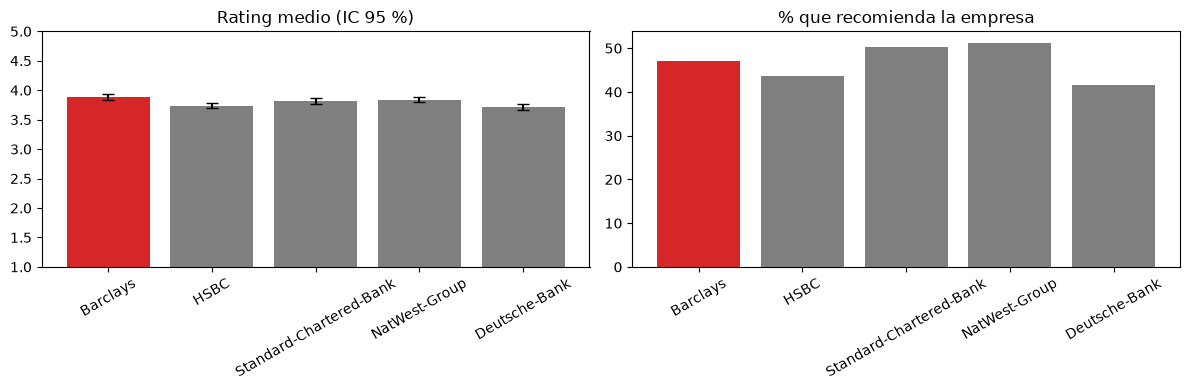

In [58]:
# Rating medio con IC y % de recomendación (la empresa objetivo en rojo)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
colores = ["#d62728" if f == TARGET else "#7f7f7f" for f in resumen.index]

ax[0].bar(resumen.index, resumen["rating_medio"], yerr=resumen["ic95_rating"],
          color=colores, capsize=4)
ax[0].set_title("Rating medio (IC 95 %)")
ax[0].set_ylim(1, 5)

ax[1].bar(resumen.index, resumen["pct_recomienda"], color=colores)
ax[1].set_title("% que recomienda la empresa")

for a in ax:
    a.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig_1_1_resumen.png", dpi=200, bbox_inches="tight")
plt.show()

Barclays tiene el rating medio más alto (3,89), seguido de NatWest-Group (3,84), Standard-Chartered-Bank (3,82), HSBC (3,74) y Deutsche-Bank (3,71). Con intervalos de confianza de unos ±0,05 por empresa, la diferencia entre dos empresas tiene que superar aproximadamente 0,07 para considerarse real. Eso ocurre entre Barclays y HSBC (0,14) o Deutsche-Bank (0,17), pero no entre Barclays y NatWest-Group (0,04) ni Standard-Chartered-Bank (0,07), que quedan en un grupo cabecero estadísticamente indistinguible.

La recomendación neta (% "Sí" menos % "No") sitúa a las mismas empresas en dos bloques: NatWest-Group (35,5), Standard-Chartered-Bank (35,1) y Barclays (33,6) por un lado, con diferencias dentro del ruido muestral (del orden de ±4 puntos), y HSBC (27,1) y Deutsche-Bank (22,8) claramente por debajo. Barclays es la empresa con menos detractores (13,5 %), pero su porcentaje de reseñas que recomiendan (47,1 %) queda por debajo del de NatWest-Group (51,3 %) y Standard-Chartered-Bank (50,3 %), porque el 39,4 % de sus reseñas es "sin opinión" frente al 32,9 % de NatWest-Group. Por último, Barclays tiene la mayor proporción de empleados actuales (66,6 %), que puntúan más alto; con un cálculo rápido, igualar esa proporción a la media de los peers (62,8 %) reduciría su rating en una centésima aproximadamente, por lo que esta composición no explica su ventaja.

### 1.2 Empleados actuales frente a antiguos

Se compara el rating y la recomendación según la situación del empleado. Los antiguos suelen puntuar más bajo en todas las empresas por un sesgo de selección (quien se ha ido tiene más motivos de queja), por lo que la brecha entre grupos importa menos en valor absoluto que el hecho de que una empresa tenga una brecha claramente mayor que sus peers.

In [59]:
base = df[df["situacion"].isin(["Actual", "Antiguo"])]

rating_sit = base.pivot_table(index="firm", columns="situacion",
                              values="overall_rating", aggfunc="mean").loc[FIRMS]
rating_sit["brecha_actual_menos_antiguo"] = rating_sit["Actual"] - rating_sit["Antiguo"]

# % que recomienda por situación (solo reseñas con respuesta)
rec_sit = (base.dropna(subset=["recomienda"])
               .assign(recomienda_si=lambda d: d["recomienda"].eq("Sí") * 100)
               .pivot_table(index="firm", columns="situacion",
                            values="recomienda_si", aggfunc="mean").loc[FIRMS])

print("Rating medio por situación:")
display(rating_sit.round(2))
print("% que recomienda por situación:")
display(rec_sit.round(1))

Rating medio por situación:


situacion,Actual,Antiguo,brecha_actual_menos_antiguo
firm,,,
Barclays,4.00,3.66,0.34
HSBC,3.85,3.57,0.28
Standard-Chartered-Bank,3.92,3.65,0.27
NatWest-Group,3.96,3.63,0.33
Deutsche-Bank,3.89,3.44,0.45


% que recomienda por situación:


situacion,Actual,Antiguo
firm,,
Barclays,49.2,42.8
HSBC,47.8,37.0
Standard-Chartered-Bank,53.5,44.4
NatWest-Group,54.6,45.4
Deutsche-Bank,45.6,34.9


En todas las empresas los empleados actuales puntúan y recomiendan más que los antiguos, como se esperaba por el sesgo de selección. Los de Barclays son los más satisfechos en ambos grupos (4,00 los actuales y 3,66 los antiguos), y la brecha de rating entre ambos (0,34) es similar a la de NatWest-Group (0,33) y algo mayor que la de HSBC (0,28) y Standard-Chartered-Bank (0,27). En recomendación, en cambio, Barclays es la empresa donde menos cae el porcentaje entre actuales y antiguos (6,4 puntos, frente a 9,1 en Standard-Chartered-Bank, 9,2 en NatWest-Group, 10,7 en Deutsche-Bank y 10,8 en HSBC).

Deutsche-Bank es la única empresa donde coinciden la mayor brecha de rating (0,45), los antiguos más críticos (3,44) y una de las mayores caídas en recomendación, lo que apunta a una peor experiencia de salida. En Barclays no hay una señal comparable, por lo que sus motivos de salida se analizarán por temas en la sección 5 y no por sentimiento.

### 1.3 Evolución del rating

Se calcula el rating medio por año y empresa. La ventana va de julio de 2018 a abril de 2023, así que 2018 y 2023 son años parciales (2023 cubre solo algo más de tres meses). Además, un año con pocas reseñas en la muestra da una media poco fiable, por lo que se oculta cualquier punto con menos de `MIN_N_ANIO` reseñas y se muestra debajo la tabla de tamaños para poder interpretarla.

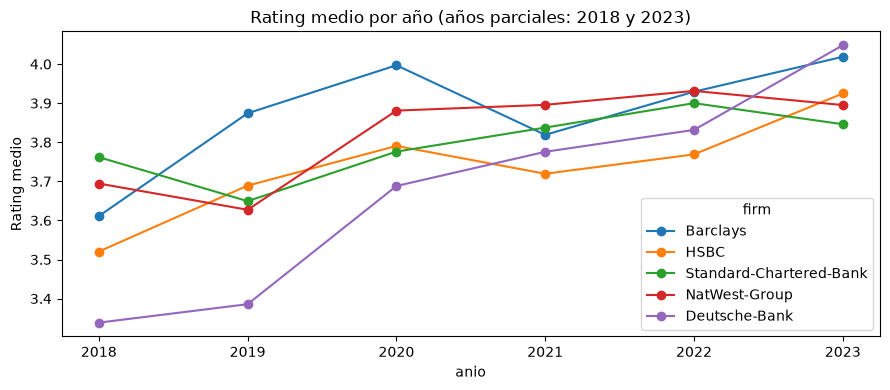

Reseñas por año y empresa (muestra):


firm,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank
anio,,,,,
2018,90,98,63,144,127
2019,286,283,288,330,280
2020,331,339,259,336,327
2021,663,581,597,585,557
2022,523,606,650,481,564
2023,107,93,143,124,145


In [60]:
MIN_N_ANIO = 30   # mínimo de reseñas por empresa y año para mostrar la media

anual = (df.groupby(["firm", "anio"])
           .agg(n=("overall_rating", "size"), rating=("overall_rating", "mean"))
           .reset_index())
anual.loc[anual["n"] < MIN_N_ANIO, "rating"] = np.nan

evolucion = anual.pivot(index="anio", columns="firm", values="rating")[FIRMS]
tamanos = anual.pivot(index="anio", columns="firm", values="n")[FIRMS]

ax = evolucion.plot(marker="o", figsize=(9, 4))
ax.set_title("Rating medio por año (años parciales: 2018 y 2023)")
ax.set_ylabel("Rating medio")
ax.set_xticks(evolucion.index)
plt.tight_layout()
plt.savefig("fig_1_3_evolucion.png", dpi=200, bbox_inches="tight")
plt.show()

print("Reseñas por año y empresa (muestra):")
tamanos

Todas las combinaciones de empresa y año tienen al menos 63 reseñas (el mínimo corresponde a Standard-Chartered-Bank en 2018), por encima del umbral de 30, por lo que no se oculta ningún punto. Aun así, el tamaño condiciona la fiabilidad: con una desviación típica del rating de aproximadamente 1,1 (deducida de los intervalos de confianza de 1.1), la media de un año con unas 100 reseñas (2018 y 2023 en casi todas las empresas) tiene un margen de error de en torno a ±0,2, mientras que con unas 600 (2021 y 2022) baja a ±0,1.

Las cinco empresas terminan 2023 por encima de su valor de 2018, pero con mejoras muy desiguales: Deutsche-Bank mejora 0,71 (de 3,34 a 4,05), Barclays 0,41, HSBC 0,40, NatWest-Group 0,21 y Standard-Chartered-Bank 0,09. Deutsche-Bank es la peor valorada hasta 2020 y converge con el resto desde 2021. Barclays pasa de una posición intermedia en 2018 (3,61, tercera) a liderar en 2019 (3,87) y 2020 (4,00, el valor más alto de ese año), baja en 2021 (3,82) hasta quedar por detrás de NatWest-Group (3,90) y Standard-Chartered-Bank (3,84), y se recupera en 2022 (3,93), empatada en cabeza con NatWest-Group. La caída de 2021 (0,18) supera ligeramente el margen de error de esa diferencia (en torno a ±0,15), por lo que es probable pero no concluyente. Los valores de 2018 y 2023 deben tomarse con cautela: son años parciales y diferencias como la de Deutsche-Bank con Barclays en 2023 (0,03) caen dentro del ruido. El bache de Barclays en 2021 se retomará en el análisis temporal de topics del apartado extra, para ver si tiene una causa identificable.

### 1.4 Coherencia entre rating y recomendación

Como comprobación de calidad, se espera que el rating medio baje al pasar de "Sí" a "Sin opinión" y a "No". Si no fuera así, alguna de las dos variables estaría mal interpretada. Este cruce también servirá más adelante, al contrastar los topics con `overall_rating` y `recommend`.

In [61]:
coherencia = (df.dropna(subset=["recomienda"])
                .pivot_table(index="firm", columns="recomienda",
                             values="overall_rating", aggfunc="mean")
                [["Sí", "Sin opinión", "No"]].loc[FIRMS])
coherencia.round(2)

recomienda,Sí,Sin opinión,No
firm,,,
Barclays,4.30,3.92,2.36
HSBC,4.19,3.77,2.51
Standard-Chartered-Bank,4.23,3.80,2.50
NatWest-Group,4.23,3.86,2.54
Deutsche-Bank,4.21,3.85,2.34


En las cinco empresas el rating baja de forma ordenada al pasar de "Sí" (entre 4,19 y 4,30) a "Sin opinión" (entre 3,77 y 3,92) y a "No" (entre 2,34 y 2,54), lo que valida ambas variables y descarta una mala interpretación de `recommend`. Además, las reseñas "sin opinión" puntúan mucho más cerca de las que recomiendan (a unos 0,4 puntos) que de las que no (a 1,3 o más), de modo que se comportan como empleados en general satisfechos que no emiten una recomendación explícita, más que como críticos. Esto relativiza el 39,4 % de "sin opinión" de Barclays: no indica descontento, sino una oportunidad de convertir esas valoraciones en recomendaciones.

### 1.5 Conclusiones del EDA

Barclays se sitúa, junto con NatWest-Group y Standard-Chartered-Bank, en el grupo mejor valorado del sector, y mantiene una ventaja clara sobre HSBC y Deutsche-Bank tanto en rating como en recomendación neta. Por tanto, el diagnóstico no parte de un problema general de reputación, sino de buscar las debilidades concretas dentro de un posicionamiento ya favorable, lo que se abordará con el análisis de topics.

Hay dos oportunidades que ya se ven antes de analizar el texto. La primera es que Barclays tiene pocos detractores (13,5 %) pero también una proporción alta de reseñas "sin opinión" (39,4 %), que puntúan alto: convertir parte de esa satisfacción tácita en recomendación explícita es una palanca de employer branding. La segunda es que sus empleados antiguos no muestran el deterioro de recomendación que sí aparece en HSBC y Deutsche-Bank, por lo que la rotación de Barclays no parece estar asociada a una experiencia de salida especialmente mala. La evolución temporal muestra que las cinco empresas terminan 2023 por encima de su nivel de 2018 y que Barclays pasa de una posición intermedia en 2018 a la cabecera del grupo desde 2019, salvo en 2021 y en 2023 (año parcial, en el que Deutsche-Bank la supera por tres centésimas, una diferencia dentro del ruido). El retroceso de 2021 es su único bache claro y se analiza en el apartado 7.2, donde se comprueba que lo explica la valoración de los antiguos y que ningún tema lo acompaña.

---
## 2. Sentimiento en pros y cons (control de calidad)

### 2.1 Modelo y planteamiento

Las columnas `pros` y `cons` ya expresan, por su propia naturaleza, un sentimiento esperado: positivo en los pros y negativo en los cons. Esta sección no busca descubrir nada nuevo, sino un control de calidad: si el sentimiento predominante no coincidiera con lo esperado, habría que sospechar del modelo, del truncado de los textos o de la limpieza.

Se utiliza `distilbert-base-uncased-finetuned-sst-2-english`, el modelo propuesto en el enunciado, por cuatro razones. Las reseñas revisadas están redactadas en inglés, que es el idioma del modelo. Fue entrenado con frases cortas, y los textos de este conjunto son breves (mediana de 7 unidades). Al ser una versión destilada de BERT, es lo bastante rápido para ejecutarse en CPU en unos 10 minutos. Y es un modelo contextual, a diferencia de los léxicos como VADER, que no entienden el contexto. Su limitación es que es binario (POSITIVE o NEGATIVE, sin clase neutral), de modo que una reseña neutra se clasifica forzosamente en uno de los dos extremos; se tendrá en cuenta al interpretar los casos discordantes.

El modelo admite un máximo de 512 tokens, por lo que se aplica con `truncation=True`. Antes de clasificar se cuenta cuántos textos superan ese límite, para saber si el truncado puede afectar al control. Las reseñas marcadas como vacías en 0.5 se excluyen. Como el cómputo tarda varios minutos, el resultado se guarda en un fichero y solo se recalcula si cambian los textos.

In [62]:
import os
import time
from tqdm.auto import tqdm
from transformers import AutoTokenizer, pipeline

MODELO_SENTIMIENTO = "distilbert-base-uncased-finetuned-sst-2-english"
RUTA_CACHE_SENT = "sentimiento_resenas.parquet"   # evita repetir el cómputo
TAM_BLOQUE = 500
COLS_SENT = ["pros_sent", "pros_p_pos", "cons_sent", "cons_p_pos"]

# 1) Textos que superan los 512 tokens (se truncarán)
tokenizador = AutoTokenizer.from_pretrained(MODELO_SENTIMIENTO)
for col in ["pros", "cons"]:
    n_tokens = df[col].map(lambda t: len(tokenizador(t)["input_ids"]))
    print(f"{col}: textos con más de 512 tokens = {(n_tokens > 512).sum()}")

def clasificar_textos(textos, clasificador):
    """Devuelve la etiqueta y la probabilidad de POSITIVE de cada texto."""
    etiquetas, p_pos = [], []
    for ini in tqdm(range(0, len(textos), TAM_BLOQUE)):
        res = clasificador(textos[ini:ini + TAM_BLOQUE], batch_size=32,
                           truncation=True, max_length=512)
        etiquetas += [r["label"] for r in res]
        p_pos += [r["score"] if r["label"] == "POSITIVE" else 1 - r["score"] for r in res]
    return etiquetas, p_pos

# 2) Usar el resultado guardado si coincide con los textos actuales; si no, calcular
usar_cache = False
if os.path.exists(RUTA_CACHE_SENT):
    cache = pd.read_parquet(RUTA_CACHE_SENT)
    usar_cache = cache[["pros", "cons"]].equals(df[["pros", "cons"]])

if usar_cache:
    df[COLS_SENT] = cache[COLS_SENT]
    print("Sentimiento cargado desde el fichero guardado.")
else:
    clasificador = pipeline("sentiment-analysis", model=MODELO_SENTIMIENTO)
    inicio = time.time()
    for col in ["pros", "cons"]:
        validas = df.index[~df[f"{col}_vacio"]]            # sin marcadores vacíos
        etiquetas, p_pos = clasificar_textos(df.loc[validas, col].tolist(), clasificador)
        df[f"{col}_sent"] = pd.Series(etiquetas, index=validas)
        df[f"{col}_p_pos"] = pd.Series(p_pos, index=validas)
    print(f"Tiempo de clasificación: {(time.time() - inicio) / 60:.1f} min")
    df[["pros", "cons"] + COLS_SENT].to_parquet(RUTA_CACHE_SENT)

print("Pros clasificados:", df["pros_sent"].notna().sum(),
      "| Cons clasificados:", df["cons_sent"].notna().sum())

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (709 > 512). Running this sequence through the model will result in indexing errors


pros: textos con más de 512 tokens = 0
cons: textos con más de 512 tokens = 3
Sentimiento cargado desde el fichero guardado.
Pros clasificados: 10000 | Cons clasificados: 9995


Solo 3 textos, todos de la columna `cons`, superan los 512 tokens del modelo, por lo que el truncado afecta a una fracción mínima de la muestra y no condiciona el control. Se clasifican 10.000 pros y 9.995 cons (los 5 marcadores vacíos de 0.5 quedan fuera). La clasificación tardó 10,5 minutos en CPU y se guarda en un fichero para no repetirla.

### 2.2 Resultado del control de calidad

Para cada empresa se calcula el porcentaje de pros clasificados como positivos y el de cons clasificados como negativos. Si todo funciona, la gran mayoría debería coincidir con lo esperado. El resto no se considera un error del modelo sin más: puede deberse a reseñas ambiguas o a textos que no expresan un contra, y se revisa en el apartado siguiente.

In [63]:
def porcentaje(col, etiqueta):
    d = df[df[f"{col}_sent"].notna()]
    por_empresa = d.groupby("firm")[f"{col}_sent"].apply(lambda s: (s == etiqueta).mean() * 100)
    return por_empresa, (d[f"{col}_sent"] == etiqueta).mean() * 100

pros_emp, pros_total = porcentaje("pros", "POSITIVE")
cons_emp, cons_total = porcentaje("cons", "NEGATIVE")

control = pd.DataFrame({"pct_pros_positivos": pros_emp,
                        "pct_cons_negativos": cons_emp}).loc[FIRMS]
control.loc["Total"] = [pros_total, cons_total]
control.round(1)

,pct_pros_positivos,pct_cons_negativos
firm,,
Barclays,93.9,81.0
HSBC,94.7,84.5
Standard-Chartered-Bank,91.8,80.4
NatWest-Group,94.2,84.6
Deutsche-Bank,92.0,84.2
Total,93.3,83.0


El control se supera: el 93,3 % de los pros se clasifica como positivo, con un rango entre empresas de 91,8 % (Standard-Chartered-Bank) a 94,7 % (HSBC). En los cons, el 83,0 % se clasifica como negativo (entre 80,4 % y 84,6 %), una proporción menor que se explica en el apartado siguiente. Con unas 2.000 reseñas por empresa, el margen de error de estos porcentajes es de en torno a ±1,7 puntos y el de una diferencia entre dos empresas de ±2,4 aproximadamente, así que las diferencias de dos puntos o menos entre empresas no son relevantes. Barclays (81,0 %) y Standard-Chartered-Bank (80,4 %) se sitúan unos 3 o 4 puntos por debajo de HSBC, NatWest-Group y Deutsche-Bank (84,2–84,6 %), una diferencia algo superior a ese margen que se revisará más adelante.

### 2.3 Casos discordantes

Se leen muestras aleatorias, con semilla fija, de los casos que no coinciden con lo esperado: cons clasificados como positivos y pros clasificados como negativos. La lectura permite explicar qué tipo de reseñas son y decidir si requieren algún tratamiento, en lugar de suponerlo.

In [64]:
N_EJEMPLOS = 12
cons_discordantes = df[df["cons_sent"] == "POSITIVE"]
pros_discordantes = df[df["pros_sent"] == "NEGATIVE"]
print(f"Cons positivos: {len(cons_discordantes)} | Pros negativos: {len(pros_discordantes)}")

print("\nCons clasificados como POSITIVE (muestra):")
display(cons_discordantes.sample(min(N_EJEMPLOS, len(cons_discordantes)), random_state=SEED)
        [["firm", "cons", "cons_p_pos"]].round(3))

print("\nPros clasificados como NEGATIVE (muestra):")
display(pros_discordantes.sample(min(N_EJEMPLOS, len(pros_discordantes)), random_state=SEED)
        [["firm", "pros", "pros_p_pos"]].round(3))

Cons positivos: 1702 | Pros negativos: 668

Cons clasificados como POSITIVE (muestra):


,firm,cons,cons_p_pos
4053,HSBC,No negatives...overall good experience...no bad exp,0.999
4844,HSBC,Politics office environment but good to see,1.000
8632,Standard-Chartered-Bank,The company is always restructuring.,0.587
897,Barclays,I have seen no cons during my tenure with Barclays. Was a happy employee!,0.999
2923,Deutsche-Bank,No Cons as of now,0.957
9750,Standard-Chartered-Bank,"Average pay to the market, not too low but not too high Complex structure",0.948
4902,HSBC,international work placement for students,0.995
1362,Barclays,"None, I really do enjoy working for the company.",0.809
2185,Deutsche-Bank,Still cost cutting. It’s ok.,1.000
8416,Standard-Chartered-Bank,There are none cons about the company,0.983



Pros clasificados como NEGATIVE (muestra):


,firm,pros,pros_p_pos
5452,HSBC,Slow pace if you like that. Good job security.,0.262
2406,Deutsche-Bank,"i get paid, so its coo.",0.326
7589,NatWest-Group,Working Culture Environment Leave policy,0.002
8134,Standard-Chartered-Bank,It is a very long hour working,0.236
3870,Deutsche-Bank,Work life balance salary Holidays Perks Paid leaves Environment,0.045
5460,HSBC,Work culture People Perks Leave policy Mental health,0.120
4559,HSBC,Good pay master Mandatory leaves employee revies,0.140
2987,Deutsche-Bank,"Work life balance culture has eased, and working pressures reduced accordingly.",0.003
8180,Standard-Chartered-Bank,Leaves Allowance Benefits Nothing more,0.018
1387,Barclays,Very Employee Centric and Customer Obsessed,0.005


El 17,0 % de los cons (1.702) se clasifica como positivo y el 6,7 % de los pros (668) como negativo. La lectura de una muestra de 12 casos de cada tipo, que sirve para describir los patrones pero no para estimar su frecuencia, apunta a causas lingüísticas más que a un fallo del modelo. En los cons positivos aparecen tres tipos de texto: declaraciones de que no hay contras ("No Cons as of now", "There are none cons about the company"), contras suavizados o mixtos ("Sometimes long hours, but usually manageable") y algún texto que no expresa un contra. En los pros negativos predominan las listas de sustantivos sin carga emocional ("Working Culture Environment Leave policy"), frases positivas con palabras que el modelo asocia a lo negativo ("too many benefits", "Customer Obsessed") y algún texto ambiguo o mal ubicado.

El modelo es binario y fue entrenado con críticas de cine, por lo que no maneja bien la negación de un contra ni los textos sin sentimiento explícito, y lo hace con mucha confianza (varias probabilidades superan 0,99). Esto tiene dos consecuencias para el resto del trabajo. Primero, el sentimiento se usa solo como control de calidad y no para decidir qué es un problema. Segundo, los cons que declaran ausencia de contras no deben tratarse como quejas, así que se identifican y se separan antes del análisis de topics (apartado siguiente).

### 2.4 Ausencia declarada de contras

Una parte de los cons no contiene ninguna queja, sino la declaración de que no hay contras ("No cons as of now", "I have seen no cons during my tenure"). Estos textos distorsionarían el análisis de topics, porque BERTopic los agruparía en un tema propio que no es un problema de la empresa, y reducirían artificialmente el peso del resto de categorías. Se detectan con expresiones regulares construidas a partir de una lista de fragmentos, para poder ampliarla o corregirla sin tocar el resto del código.

Se prioriza la precisión sobre la cobertura: es preferible dejar sin marcar algún texto de este tipo que marcar una queja real. Por eso no se detecta simplemente cualquier texto que empiece por "no" o "none", ya que "No career growth" o "None of the managers care" son contras reales. Tampoco se marcan los textos que introducen una salvedad ("none, except...", "nothing as such but..."), porque a continuación señalan un contra.

El detector se construyó en tres rondas. Una primera muestra de coincidencias y de textos no marcados sirvió para diseñarlo, una segunda con otra semilla reveló dos tipos de error (salvedades con "but" y ausencias expresadas de formas no previstas, como "No problems encountered"), y se corrigió. La tercera, con una semilla nueva, es la que se reporta como validación final, de modo que la evaluación nunca se hace sobre los mismos textos que sirvieron para corregir el patrón.

In [65]:
# Fragmentos que declaran ausencia de contras (editable)
ADJ = r"(?:(?:such|real|any|big|major|significant|serious|particular) )?"
EXPRESIONES_SIN_CONTRAS = [
    rf"\bno {ADJ}(?:cons|negatives?|downsides?|disadvantages?|complaints?)\b",
    r"\bno (?:(?:real|big|major|significant|serious|particular) )?(?:problems|issues)\b",
    r"\bnone cons?\b",
    r"\bnothing cons?\b",
    r"\bno con\W*$",
    r"\bnothing (?:to complain|negative|bad)\b",
    r"\b(?:can(?:'|’)?t|cannot|can not|couldn(?:'|’)?t) (?:think|find)(?: of)? any\b",
    r"^\W*nothing\W+(?:as of now|as such|such|at all|at the moment|major|significant|serious|coming to mind)\b",
    r"^\W*nothing\W+(?:that )?i\s+(?:can|could|have|came|found|know|think|experienced|encountered)\b",
    r"^\W*nothing\W+(?:much\W+)?to(?:\s+to)?\s+(?:highlight|mention|say|report|add|complain|share)\b",
    r"^\W*no\W+as such\b",
    r"^\W*none\b(?!\s+of\b)",                 # "None", pero no "None of the managers..."
    r"^\W*(?:(?:nothing|nil|none|n/?a|not applicable)\W*)+$",   # "nil nil nil", "n/a"...
]
# Si el texto introduce una salvedad, hay un contra real y no se marca
EXPRESION_EXCEPCION = r"\b(?:except|apart from|other than|besides|but|however|although|though|could be)\b"

PATRON_SIN_CONTRAS = re.compile("|".join(EXPRESIONES_SIN_CONTRAS), re.IGNORECASE)
PATRON_EXCEPCION = re.compile(EXPRESION_EXCEPCION, re.IGNORECASE)

df["cons_sin_contras"] = (df["cons"].str.contains(PATRON_SIN_CONTRAS)
                          & ~df["cons"].str.contains(PATRON_EXCEPCION)
                          & ~df["cons_vacio"])

SEED_VALIDACION = SEED + 2   # tercera muestra: la que se reporta como validación final

def muestra(datos, n=25):
    return datos.sample(min(n, len(datos)), random_state=SEED_VALIDACION)

sin = df["cons_sin_contras"]
print(f"Cons que declaran ausencia de contras: {sin.sum()} ({sin.mean() * 100:.1f} %)")
print("\n% por empresa:")
print((df.groupby("firm")["cons_sin_contras"].mean() * 100).round(1).loc[FIRMS])

# 1) Falsos positivos: leer coincidencias al azar
print("\nCoincidencias (muestra):")
display(muestra(df.loc[sin, ["firm", "cons"]]))

# 2) Falsos negativos: cons que empiezan por no/none/nothing/nil y NO se marcan
empieza = df["cons"].str.match(r"^\W*(?:no|none|nothing|nil)\b", case=False)
print("\nEmpiezan por no/none/nothing y no se marcan (muestra):")
display(muestra(df.loc[empieza & ~sin & ~df["cons_vacio"], ["firm", "cons"]]))

# 3) Cómo los clasificó el modelo
print("\nSentimiento de los cons marcados (%):")
print(df.loc[sin, "cons_sent"].value_counts(normalize=True).mul(100).round(1))

# 4) Control de calidad repetido sin esos textos
reales = df[df["cons_sent"].notna() & ~df["cons_sin_contras"]]
pct_neg = (reales["cons_sent"] == "NEGATIVE").groupby(reales["firm"]).mean().mul(100)
pct_neg.loc["Total"] = (reales["cons_sent"] == "NEGATIVE").mean() * 100
print("\n% de cons negativos, sin los de ausencia declarada:")
print(pct_neg.round(1))

# 5) Probabilidad media de POSITIVE en los cons restantes (¿contras más suaves?)
print("\nProbabilidad media de POSITIVE en los cons restantes:")
print(reales.groupby("firm")["cons_p_pos"].mean().round(3).loc[FIRMS])

print("Cons que empiezan por no/none/nothing/nil y no se marcan:",
      (empieza & ~sin & ~df["cons_vacio"]).sum())

Cons que declaran ausencia de contras: 821 (8.2 %)

% por empresa:
firm
Barclays                   11.0
HSBC                        5.3
Standard-Chartered-Bank     8.6
NatWest-Group               8.5
Deutsche-Bank               7.6
Name: cons_sin_contras, dtype: float64

Coincidencias (muestra):


,firm,cons
6333,NatWest-Group,There is no cons uh
2876,Deutsche-Bank,No complaints about worklife or management
7223,NatWest-Group,No as such in my knowledge
7295,NatWest-Group,no cons as such healthy enviroinment
8115,Standard-Chartered-Bank,No cons at least for me
1034,Barclays,No Cons Only Pros here No Cons Only Pros here No cons
7533,NatWest-Group,none i can think of
7347,NatWest-Group,none that I could think of
3126,Deutsche-Bank,I can't think of any at this time
534,Barclays,nothing bad to mention here



Empiezan por no/none/nothing y no se marcan (muestra):


,firm,cons
3963,Deutsche-Bank,no pay raises and bonuses!
1727,Barclays,No big cons as such Hike could be better More benefits could be given
3685,Deutsche-Bank,No promotions available no matter how hard you try.
2373,Deutsche-Bank,"No fully remote work available. No perks such as happy hours, food or snacks in office, etc. Growth opportunities no..."
3974,Deutsche-Bank,"No major hike, no major bonus"
5291,HSBC,No opportunities to grow or develope these are heavily invested in the Graduates. Promotes Mental wellbeing but does...
799,Barclays,"Nothing specific, just the usual work place issues"
2418,Deutsche-Bank,No growth in terms of package
9027,Standard-Chartered-Bank,Nothing much for me to comment on the Company.
7276,NatWest-Group,no salary growth for too long



Sentimiento de los cons marcados (%):
cons_sent
NEGATIVE    56.9
POSITIVE    43.1
Name: proportion, dtype: float64

% de cons negativos, sin los de ausencia declarada:
firm
Barclays                   83.6
Deutsche-Bank              86.5
HSBC                       86.1
NatWest-Group              87.5
Standard-Chartered-Bank    82.8
Total                      85.3
Name: cons_sent, dtype: float64

Probabilidad media de POSITIVE en los cons restantes:
firm
Barclays                   0.170
HSBC                       0.145
Standard-Chartered-Bank    0.176
NatWest-Group              0.129
Deutsche-Bank              0.140
Name: cons_p_pos, dtype: float64
Cons que empiezan por no/none/nothing/nil y no se marcan: 596


El detector marca 821 cons (8,2 %) como ausencia declarada de contras: Barclays 11,0 %, Standard-Chartered-Bank 8,6 %, NatWest-Group 8,5 %, Deutsche-Bank 7,6 % y HSBC 5,3 %. Es una cifra mínima, porque el detector prioriza la precisión sobre la cobertura y se le escapan algunas formulaciones.

En cada ronda de validación se leyeron 25 coincidencias y 25 textos que empiezan por "no", "none", "nothing" o "nil" y no se marcan, con una semilla distinta cada vez:

| Ronda | Semilla | Marcados con queja real o salvedad (de 25) | Ausencias no detectadas (de 25 no marcados) |
|---|---|---|---|
| 1 | 42 | 2 | 10 |
| 2 | 43 | 2 | 7 |
| 3 | 44 | 1 | 5 |

Tras cada ronda se corrigieron los errores observados (primero las salvedades con "except", después las salvedades con "but" y varias formulaciones de ausencia), por lo que la tercera es la que se reporta como validación final y no se ha retocado el detector después de leerla. En ella, de las 25 coincidencias, 24 son ausencias claras y una contiene un contra real antes de la declaración ("Multi layer approval process. No such cons to describe here.."). De los 25 textos no marcados, 18 son contras reales correctamente excluidos, 5 son ausencias que se escapan ("Nil comments for the moment", "Nothing is bad from my point of view"...) y 2 son mixtos o ambiguos, que se dejan sin marcar a propósito.

Con muestras de 25 casos estas cifras describen los tipos de error, pero no estiman con precisión su frecuencia. Los dos efectos son acotados y conocidos: algún contra real puede quedar marcado como ausencia y salir del análisis de topics, y algunas ausencias no marcadas llegarán al modelo de topics, donde formarán un tema reconocible que se etiquetará como "Sin contras" en la revisión manual de la sección 3. Por este motivo no se amplió más el detector: una lista más agresiva aumentaría el riesgo de marcar quejas reales.

Para acotar cuánto se escapa, se cuenta cuántos cons empiezan por "no", "none", "nothing" o "nil" y no se marcan: son 596. Como en la tercera muestra 5 de 25 eran ausencias declaradas, la estimación central es de unas 120 ausencias no detectadas entre esos textos (intervalo del 95 % entre unas 50 y unas 230). Esta cifra se refiere solo a los textos que empiezan por esas palabras. El análisis de topics de la sección 3 identifica además unas 540 ausencias con otras formulaciones ("Cannot recall anything for this space", "Not Applicable as of now"), por lo que la cobertura real del detector es menor de lo que sugiere esa primera estimación, y el indicador final se construye combinando el detector con esos topics (apartado 3.8).

El modelo de sentimiento clasifica como negativos solo el 56,9 % de los cons que declaran ausencia de contras, lo que confirma que la polaridad no sirve para decidir qué es una queja. Excluidos esos textos, el 85,3 % de los cons restantes se clasifica como negativo, y el resto corresponde a contras suavizados, mixtos o ambiguos del tipo descrito en 2.3.

Entre empresas se mantiene una diferencia de 3 a 4 puntos: Barclays (83,6 %) y Standard-Chartered-Bank (82,8 %) tienen menos cons negativos que HSBC (86,1 %), Deutsche-Bank (86,5 %) y NatWest-Group (87,5 %), lo que supera el margen de error aproximado de una diferencia (±2,4 puntos). La probabilidad media de POSITIVE en esos mismos cons es mayor en Barclays (0,170) y Standard-Chartered-Bank (0,176) que en las otras tres (0,129 a 0,145). La diferencia persiste al excluir también las ausencias detectadas con los topics (apartado 3.8), por lo que no la explica la ausencia de contras no detectada y su causa queda sin identificar.

Además, la proporción de reseñas que declaran no tener contras es un indicador de satisfacción comparable entre empresas: Barclays es la más alta (11,0 %) y la distancia con las demás (entre 2,4 y 5,7 puntos) supera el margen de error aproximado de una diferencia (unos ±1,9 puntos). Debe leerse con cautela, porque el detector reconoce unas formulaciones mejor que otras y su cobertura podría no ser igual en todas las empresas.

### 2.5 Conclusiones de la sección

El control de calidad se supera: el 93,3 % de los pros se clasifica como positivo y el 85,3 % de los cons que expresan una queja se clasifica como negativo, con resultados parecidos en las cinco empresas. Las discrepancias restantes se deben al tipo de texto (listas de palabras sin carga emocional, contras suavizados, ausencias de contras) y no a un fallo de la limpieza o del truncado, que afecta a solo 3 cons. La única diferencia entre empresas que se mantiene es que los cons de Barclays y Standard-Chartered-Bank se clasifican como negativos 3 a 4,5 puntos menos que los de las otras tres, sin causa identificada (apartado 3.8).

El modelo de sentimiento queda como herramienta de control y no se utiliza para decidir qué es un problema. De esta sección se llevan dos cosas a las siguientes: la marca `cons_sin_contras`, que separa del análisis de topics 821 textos que no contienen quejas, y el indicador de ausencia declarada de contras, que se completa en el apartado 3.8 con las ausencias que el detector no recogía.

---
## 3. Topic modeling con BERTopic

### 3.1 Decisiones de diseño

Se utiliza BERTopic por tres razones. Los textos son muy breves (mediana de 7 palabras) y repiten las mismas ideas con palabras distintas ("salary", "pay", "compensation"), por lo que un enfoque basado en bolsa de palabras como LDA no capta que son el mismo tema, mientras que los embeddings sí agrupan por significado. No exige fijar de antemano el número de topics, que se desconoce. Y trata de forma explícita los textos que no encajan en ningún tema (outliers), una decisión que importa en reseñas muy cortas y heterogéneas. Su inconveniente es la variabilidad entre ejecuciones por UMAP, que se controla fijando semillas, sin eliminarla del todo.

Siguiendo la regla de comparabilidad del enunciado, se entrena un único modelo con las reseñas de las cinco empresas juntas para los pros y otro, también conjunto, para los cons. Si se entrenara un modelo por empresa, los topics no coincidirían y no podrían compararse.

Los documentos de entrada son los pros no vacíos y los cons que expresan una queja, es decir, excluyendo los marcadores vacíos y los cons que declaran ausencia de contras (sección 2), que formarían un tema que no es un problema de la empresa. Como los textos están en inglés, se emplea un modelo de embeddings para inglés (`all-MiniLM-L6-v2`), más rápido en CPU y ajustado a ese idioma que el multilingüe de los apuntes. Los nombres de las empresas se eliminan del texto antes de calcular los embeddings, para que los topics representen temas y no empresas: si un tema se definiera por "Barclays" o "SCB", sería propio de una empresa y no se podría comparar. Las decisiones sobre los parámetros de UMAP y HDBSCAN, los outliers y las categorías de negocio se justifican en los apartados siguientes, con los resultados delante.

### 3.2 Preparación de los textos

Se eliminan los nombres de las empresas con una expresión regular construida a partir de una lista, con límites de palabra para no tocar fragmentos de otras palabras, y ordenada de mayor a menor longitud para que "deutsche bank" se elimine entera y no solo "deutsche". Se excluyen a propósito abreviaturas ambiguas como "DB", que en reseñas de tecnología puede significar base de datos. Antes de aplicarla se comprueba cuántas reseñas mencionan cada nombre y en qué empresa, y se leen ejemplos de las abreviaturas más dudosas ("scb", "rbs"), para confirmar que no se elimina nada que no sea un nombre de empresa.

In [66]:
# Nombres de empresa que se eliminan del texto (editable). Sin abreviaturas ambiguas.
NOMBRES_EMPRESA = ["barclays", "hsbc", "natwest", "nat west", "rbs", "standard chartered",
                   "stanchart", "scb", "deutsche bank", "deutsche"]
nombres_ordenados = sorted(NOMBRES_EMPRESA, key=len, reverse=True)   # los más largos primero
PATRON_EMPRESA = re.compile(r"\b(?:" + "|".join(re.escape(n) for n in nombres_ordenados) + r")\b",
                            re.IGNORECASE)

def menciones_por_empresa(col):
    """Reseñas que mencionan cada nombre, en total y por empresa."""
    filas = []
    for nombre in NOMBRES_EMPRESA:
        patron = re.compile(rf"\b{re.escape(nombre)}\b", re.IGNORECASE)
        marca = df[col].str.contains(patron)
        fila = {"nombre": nombre, "total": int(marca.sum())}
        fila.update(df[marca].groupby("firm").size().reindex(FIRMS, fill_value=0).to_dict())
        filas.append(fila)
    return pd.DataFrame(filas).set_index("nombre")

print("Menciones en pros:")
display(menciones_por_empresa("pros"))
print("Menciones en cons:")
display(menciones_por_empresa("cons"))

# Lectura de las abreviaturas más dudosas
for nombre in ["scb", "rbs"]:
    patron = re.compile(rf"\b{nombre}\b", re.IGNORECASE)
    coinciden = df[df["pros"].str.contains(patron) | df["cons"].str.contains(patron)]
    print(f"\n'{nombre}': {len(coinciden)} reseñas (muestra)")
    display(coinciden[["firm", "pros", "cons"]].sample(min(8, len(coinciden)), random_state=SEED))

# Texto sin nombres de empresa y documentos de cada modelo
def quitar_empresa(texto):
    return re.sub(r"\s+", " ", PATRON_EMPRESA.sub("", texto)).strip()

df["pros_txt"] = df["pros"].map(quitar_empresa)
df["cons_txt"] = df["cons"].map(quitar_empresa)

df["en_topics_pros"] = ~df["pros_vacio"] & (df["pros_txt"].str.len() > 0)
df["en_topics_cons"] = (~df["cons_vacio"] & ~df["cons_sin_contras"]
                        & (df["cons_txt"].str.len() > 0))

print("\nDocumentos para el modelo de pros:", df["en_topics_pros"].sum())
print("Documentos para el modelo de cons:", df["en_topics_cons"].sum())
print("Textos que quedan vacíos tras quitar el nombre (pros / cons):",
      (~(df["pros_txt"].str.len() > 0)).sum(), "/", (~(df["cons_txt"].str.len() > 0)).sum())
print("\nDocumentos por empresa:")
display(df.groupby("firm")[["en_topics_pros", "en_topics_cons"]].sum().loc[FIRMS])

Menciones en pros:


,total,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank
nombre,,,,,,
barclays,62,62,0,0,0,0
hsbc,62,0,61,1,0,0
natwest,23,0,0,0,23,0
nat west,0,0,0,0,0,0
rbs,23,0,0,0,23,0
standard chartered,11,0,0,11,0,0
stanchart,0,0,0,0,0,0
scb,34,0,0,34,0,0
deutsche bank,17,0,0,0,0,17


Menciones en cons:


,total,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank
nombre,,,,,,
barclays,42,42,0,0,0,0
hsbc,42,0,42,0,0,0
natwest,14,0,0,0,14,0
nat west,0,0,0,0,0,0
rbs,31,0,0,0,31,0
standard chartered,5,0,0,5,0,0
stanchart,0,0,0,0,0,0
scb,19,0,0,19,0,0
deutsche bank,13,0,0,0,0,13



'scb': 44 reseñas (muestra)


,firm,pros,cons
9520,Standard-Chartered-Bank,"SCB is a very good employer in terms of staff benefits, overall working environment and from professional growth per...","Work pressure is very high, specially on support functions staff. Late hours working is a routine. Occasionally, you..."
9036,Standard-Chartered-Bank,The are global company and lots of international mobility,UAE is not a primary market for SCB
9059,Standard-Chartered-Bank,Good to work scb here,No issues in scb working
9481,Standard-Chartered-Bank,"Here in SCB, the staff benefits are pretty decent.",Job scope can be mundane
9408,Standard-Chartered-Bank,There’s opportunity to make a real impact once you learn how to operate within the bank. People that succeed within ...,Too many decisions “by committee” rather than by authorised individuals. It can take a long time to get things done ...
9721,Standard-Chartered-Bank,All benefits are great in SCB,Nothing as I faced in my 6 years experience
8135,Standard-Chartered-Bank,Scb is a great employer and has great benefits.,New joiner experience is focus
8377,Standard-Chartered-Bank,Everything is good in SCB,No on-site opportunity as long as you are in SCB



'rbs': 49 reseñas (muestra)


,firm,pros,cons
6672,NatWest-Group,Great work life balance in rbs.,No issue as such in rbs.
7744,NatWest-Group,RBS is always give importance to employers,Career growth in the growth is not in always elevating level
7865,NatWest-Group,Employee centrec gud work life,Notice period of 90 rbs
7716,NatWest-Group,Working with 15 years in RBS was great learning exprience throughout the journey in RBS starting the career in entry...,"Salary Package is very low when compared in the market, Transport to and fro not available at least it can be given ..."
6879,NatWest-Group,I have excelled in my banking carrier,its unfortunate that RBS has closed in India
7246,NatWest-Group,"Amazing work culture, diverse and inclusive workplace",RBS is a great place to work and there are no cons I can point out.
7218,NatWest-Group,Good to work with in rbs,Very slow vertical growth in domain
7195,NatWest-Group,* People are generally nice. There are however several left-overs of people giving attitude here and there. This is ...,"* London offices used to be human warehouses compared to other tech companies. Situation has improved in some, mice ..."



Documentos para el modelo de pros: 10000
Documentos para el modelo de cons: 9174
Textos que quedan vacíos tras quitar el nombre (pros / cons): 0 / 0

Documentos por empresa:


,en_topics_pros,en_topics_cons
firm,,
Barclays,2000,1778
HSBC,2000,1893
Standard-Chartered-Bank,2000,1824
NatWest-Group,2000,1831
Deutsche-Bank,2000,1848


Los nombres de empresa aparecen en pocas reseñas: en pros, entre 11 ("standard chartered") y 62 ("barclays" y "hsbc"), y en cons, entre 5 y 42. Casi todas las menciones corresponden a la propia empresa de la reseña; la única excepción es una reseña de Standard-Chartered-Bank que cita a HSBC. Aunque afecta a una fracción pequeña de los textos, enmascararlos evita que se formen topics definidos por un nombre propio, que no serían comparables entre empresas. Las variantes "nat west" y "stanchart" no aparecen, y se mantienen en la lista por si se amplían los datos.

La lectura de muestras de las abreviaturas más dudosas confirma que el enmascarado no elimina nada relevante. "scb" corresponde al banco en las 8 reseñas leídas (todas de Standard-Chartered-Bank), y "rbs" en 7 de 8 (todas de NatWest-Group, cuyo nombre anterior era Royal Bank of Scotland). El caso restante ("Notice period of 90 rbs") parece una errata de otra palabra, y quitarla no altera el tema de la reseña.

Quedan 10.000 documentos para el modelo de pros y 9.174 para el de cons. La diferencia de 826 cons cuadra con las exclusiones de la sección 2: 821 textos con ausencia declarada de contras y 5 marcadores vacíos. Ningún texto queda vacío tras quitar los nombres, y los cons por empresa oscilan entre 1.778 y 1.893, un reparto equilibrado que no hace que una empresa domine los temas.

### 3.3 Embeddings

Se calcula un embedding por reseña con `all-MiniLM-L6-v2` (384 dimensiones), una vez para los pros y otra para los cons. El cálculo es el paso más lento del modelo de topics, y se repetiría cada vez que se probara un parámetro de UMAP o HDBSCAN, por lo que se guarda en disco. El nombre del fichero incluye una huella (hash) de los textos, de manera que si estos cambian se recalcula y nunca se reutiliza un fichero obsoleto.

In [67]:
import os
import time
import hashlib
from sentence_transformers import SentenceTransformer

MODELO_EMBEDDINGS = "sentence-transformers/all-MiniLM-L6-v2"

docs_pros = df.loc[df["en_topics_pros"], "pros_txt"].tolist()
docs_cons = df.loc[df["en_topics_cons"], "cons_txt"].tolist()

def embeddings_con_cache(textos, prefijo):
    """Calcula los embeddings o los carga de disco si los textos no han cambiado."""
    huella = hashlib.md5("\n".join(textos).encode("utf-8")).hexdigest()[:8]
    ruta = f"{prefijo}_{huella}.npy"
    if os.path.exists(ruta):
        print(f"{prefijo}: cargado de {ruta}")
        return np.load(ruta)
    modelo = SentenceTransformer(MODELO_EMBEDDINGS)
    inicio = time.time()
    emb = modelo.encode(textos, batch_size=64, show_progress_bar=True)
    print(f"{prefijo}: calculado en {(time.time() - inicio) / 60:.1f} min")
    np.save(ruta, emb)
    return emb

emb_pros = embeddings_con_cache(docs_pros, "emb_pros")
emb_cons = embeddings_con_cache(docs_cons, "emb_cons")
print("Dimensiones:", emb_pros.shape, emb_cons.shape)

emb_pros: cargado de emb_pros_b273503c.npy
emb_cons: cargado de emb_cons_df715b95.npy
Dimensiones: (10000, 384) (9174, 384)


Los embeddings se calculan en unos 0,3 minutos para cada columna, gracias a la brevedad de los textos y al tamaño reducido del modelo. Se obtienen matrices de 10.000 × 384 para los pros y 9.174 × 384 para los cons. El orden de sus filas coincide con el de los documentos seleccionados en 3.2 (`en_topics_pros` y `en_topics_cons`), y se respetará al asignar cada reseña a su topic.

### 3.4 Reducción de dimensionalidad y tamaño mínimo de topic

Antes de ajustar el modelo se fijan los parámetros que más afectan al resultado. Para UMAP se parte de los valores vistos en clase: 5 dimensiones finales, un vecindario de 15 puntos, `min_dist=0` (agrupaciones compactas, lo que favorece que HDBSCAN encuentre clusters), distancia coseno (adecuada para texto) y semilla fija. La reducción es el paso más costoso, por lo que se calcula una sola vez y se reutiliza para explorar HDBSCAN.

El parámetro decisivo es el tamaño mínimo de un topic (`min_cluster_size`). Desde el punto de vista del negocio, un topic debe tener reseñas suficientes en cada empresa para poder comparar porcentajes: con unas 2.000 reseñas por empresa, un topic de menos de unas 30 reseñas tendría de media menos de 6 por empresa, un número demasiado pequeño para sacar conclusiones. Por otro lado, demasiado grande mezclaría temas distintos, y un número elevado de topics sería difícil de interpretar para RRHH. Se explora un rango de valores y se elige a la vista de tres criterios: un número de topics manejable, un porcentaje moderado de outliers y que ningún topic concentre una parte desproporcionada de las reseñas. Se fija `min_samples=10`, que hace al algoritmo menos conservador y reduce los outliers, algo importante en textos tan breves.

In [68]:
import umap
import hdbscan

# Reducción con UMAP (una sola vez); parámetros según los apuntes
def reducir_umap(emb):
    modelo = umap.UMAP(n_components=5, n_neighbors=15, min_dist=0.0,
                       metric="cosine", random_state=SEED)
    return modelo.fit_transform(emb)

inicio = time.time()
red_pros = reducir_umap(emb_pros)
red_cons = reducir_umap(emb_cons)
print(f"UMAP: {(time.time() - inicio) / 60:.1f} min")

MIN_MUESTRAS = 10
TAMANOS_PRUEBA = [15, 30, 50, 80]

def explorar_tamanos(red):
    filas = []
    for tam in TAMANOS_PRUEBA:
        etiquetas = hdbscan.HDBSCAN(min_cluster_size=tam, min_samples=MIN_MUESTRAS,
                                    metric="euclidean", cluster_selection_method="eom"
                                    ).fit_predict(red)
        en_topic = etiquetas[etiquetas >= 0]
        conteo = np.bincount(en_topic) if len(en_topic) else np.array([0])
        filas.append({"min_cluster_size": tam,
                      "n_topics": len(set(etiquetas)) - (1 if -1 in etiquetas else 0),
                      "pct_outliers": round((etiquetas == -1).mean() * 100, 1),
                      "pct_topic_mayor": round(conteo.max() / len(etiquetas) * 100, 1),
                      "tam_topic_menor": int(conteo[conteo > 0].min()) if conteo.max() > 0 else 0})
    return pd.DataFrame(filas).set_index("min_cluster_size")

print("Pros:")
display(explorar_tamanos(red_pros))
print("Cons:")
display(explorar_tamanos(red_cons))

UMAP: 0.4 min
Pros:


,n_topics,pct_outliers,pct_topic_mayor,tam_topic_menor
min_cluster_size,,,,
15,128,33.7,4.5,15
30,71,30.6,4.9,31
50,50,27.8,4.9,50
80,27,26.3,14.7,93


Cons:


,n_topics,pct_outliers,pct_topic_mayor,tam_topic_menor
min_cluster_size,,,,
15,114,30.6,4.0,15
30,64,31.3,4.2,30
50,39,27.4,7.2,50
80,27,26.1,7.8,88


El número de topics baja rápidamente al aumentar el tamaño mínimo: en los pros pasa de 128 (tamaño 15) a 71 (30), 50 (50) y 27 (80), y en los cons de 114 a 64, 39 y 27. Con 15 y 30 hay demasiados topics para revisarlos a mano y para que RRHH los interprete. El porcentaje de outliers es alto en todos los casos (entre el 26 % y el 34 %) y varía poco con el tamaño, algo esperable en reseñas tan breves, de modo que no es un criterio que discrimine entre las opciones. Con tamaño 80, en los pros un solo topic pasa a concentrar el 14,7 % de las reseñas (frente al 4,9 % con 50), señal de que varios temas se funden en uno genérico.

Se elige un tamaño mínimo de 50 para pros y cons. Es el valor que mantiene un número de topics manejable (50 y 39), evita temas dominantes y garantiza que el topic más pequeño tenga 50 reseñas, unas 10 por empresa de media, lo mínimo para comparar porcentajes entre empresas. Los topics se agruparán después en pocas categorías de negocio interpretables por RRHH, así que perder algo de detalle es asumible, y el porcentaje de outliers se trata explícitamente en el apartado siguiente.

### 3.5 Ajuste de BERTopic

Se ajusta un modelo de BERTopic para los pros y otro para los cons, reutilizando los embeddings calculados y los parámetros de UMAP y HDBSCAN elegidos. Las palabras clave de cada topic se calculan con c-TF-IDF sobre un vectorizador que elimina las palabras vacías del inglés, admite unigramas y bigramas ("work life", "career growth") y descarta los términos presentes en menos de 5 documentos. No se calculan las probabilidades de pertenencia, que no se utilizan y ralentizan el ajuste. Los outliers (topic -1) se dejan por ahora sin tratar, para examinarlos antes de decidir qué hacer con ellos.

Para interpretar cada topic se muestran su tamaño, sus palabras clave y una reseña representativa. Se comprueba además que el porcentaje de outliers sea parecido en las cinco empresas: si una empresa tuviera muchos más, sus resultados en las categorías estarían sesgados.

In [69]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

MIN_TAMANO_TOPIC = 50   # elegido en 3.4

def ajustar_bertopic(docs, emb):
    umap_model = umap.UMAP(n_components=5, n_neighbors=15, min_dist=0.0,
                           metric="cosine", random_state=SEED)
    hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=MIN_TAMANO_TOPIC, min_samples=MIN_MUESTRAS,
                                    metric="euclidean", cluster_selection_method="eom",
                                    prediction_data=True)
    vectorizador = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5)
    modelo = BERTopic(embedding_model=SentenceTransformer(MODELO_EMBEDDINGS),
                      umap_model=umap_model, hdbscan_model=hdbscan_model,
                      vectorizer_model=vectorizador, top_n_words=10,
                      calculate_probabilities=False, verbose=False)
    topics, _ = modelo.fit_transform(docs, embeddings=emb)
    return modelo, np.array(topics)

inicio = time.time()
modelo_pros, topics_pros = ajustar_bertopic(docs_pros, emb_pros)
modelo_cons, topics_cons = ajustar_bertopic(docs_cons, emb_cons)
print(f"Ajuste de los dos modelos: {(time.time() - inicio) / 60:.1f} min")

# Asignar el topic a cada reseña (NA si no entró en el modelo)
df["topic_pros"] = pd.array([pd.NA] * len(df), dtype="Int64")
df["topic_cons"] = pd.array([pd.NA] * len(df), dtype="Int64")
df.loc[df["en_topics_pros"], "topic_pros"] = topics_pros
df.loc[df["en_topics_cons"], "topic_cons"] = topics_cons

# Topics y outliers
for col, nombre in [("topic_pros", "pros"), ("topic_cons", "cons")]:
    d = df[df[col].notna()]
    print(f"\n{nombre}: {d[col].nunique() - 1} topics | outliers: {(d[col] == -1).mean() * 100:.1f} %")
    print("% de outliers por empresa:")
    print(d.groupby("firm")[col].apply(lambda s: (s == -1).mean() * 100).round(1).loc[FIRMS])

def tabla_topics(modelo):
    info = modelo.get_topic_info()
    info = info[info["Topic"] >= 0].copy()
    info["palabras_clave"] = info["Topic"].map(
        lambda t: ", ".join(p for p, _ in modelo.get_topic(t)[:8]))
    info["ejemplo"] = info["Topic"].map(lambda t: modelo.get_representative_docs(t)[0][:90])
    return info[["Topic", "Count", "palabras_clave", "ejemplo"]].set_index("Topic")

with pd.option_context("display.max_rows", None, "display.max_colwidth", 100):
    print("\nTOPICS DE PROS:")
    display(tabla_topics(modelo_pros))
    print("\nTOPICS DE CONS:")
    display(tabla_topics(modelo_cons))

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2071.82it/s]


Ajuste de los dos modelos: 0.5 min

pros: 50 topics | outliers: 27.8 %
% de outliers por empresa:
firm
Barclays                   28.4
HSBC                       25.9
Standard-Chartered-Bank    26.0
NatWest-Group              28.0
Deutsche-Bank              30.8
Name: topic_pros, dtype: float64

cons: 39 topics | outliers: 27.4 %
% de outliers por empresa:
firm
Barclays                   29.7
HSBC                       26.9
Standard-Chartered-Bank    25.4
NatWest-Group              27.2
Deutsche-Bank              27.9
Name: topic_cons, dtype: float64

TOPICS DE PROS:


,Count,palabras_clave,ejemplo
Topic,,,
0,490,"salary, pay, good pay, good salary, benefits, decent, salary good, bonus",Good Pay and emplyee friendly
1,453,"bank, banking, investment, bank good, global, international, learn, finance",german bank so it should be cuite proffesional but not
2,441,"place, place work, good place, great place, work good, work great, work, great",Good in place to work
3,389,"team, teams, great team, good team, team great, team good, great, team work",The management stood firmly with the Team.
4,296,"company, good company, company work, great company, work good, company good, good, work great",Good company to work with.
5,271,"environment, good environment, working environment, nice, office, work environment, environment ...",Good working Environment at Office
6,252,"leave, leave policy, policy, medical, annual, annual leave, benefits, medical benefits","Good leave policy , competative environment"
7,229,"global, international, large, company, organisation, opportunities, big, organization",large multinational company with global network.
8,213,"work culture, culture, culture good, working culture, company culture, company, colleagues, cult...",The Work culture is good



TOPICS DE CONS:


,Count,palabras_clave,ejemplo
Topic,,,
0,656,"salary, pay, market, low, compared, compensation, competitive, industry",give very low pay and salary
1,383,"bureaucracy, big, bureaucratic, large, decision making, decision, making, organisation",Bureaucratic and slow decision making
2,371,"think, good, bad, moment, far, say, till, really","They're good, not bad at all"
3,354,"hours, long, long hours, working hours, working, long working, hours long, overtime",very long working hours sometimes
4,351,"bank, banks, banking, investment, compared, financial, people, like",No con as such with the bank
5,346,"career, progression, career growth, career progression, growth, opportunities, slow, slow career",Be a good to career progression
6,335,"promotion, promotions, promoted, hard, difficult, opportunities, promote, slow",Have to be in with management to get promotion
7,299,"balance, life balance, work life, life, work, worklife, worklife balance, good work",Not enough work life balance
8,280,"technology, technologies, legacy, tech, old, new, stack, outdated",Old computers and bad technology


Los dos modelos se ajustan en unos 0,5 minutos y reproducen el número de topics de la exploración: 50 en los pros y 39 en los cons. El 27,8 % de los pros y el 27,4 % de los cons quedan como outliers (topic -1), una proporción alta pero esperable en textos con una mediana de 7 palabras, muchos de los cuales no encajan en un tema concreto. Por empresa varía entre el 25,9 % (HSBC) y el 30,8 % (Deutsche-Bank) en los pros, y entre el 25,4 % (Standard-Chartered-Bank) y el 29,7 % (Barclays) en los cons. Con unas 2.000 reseñas por empresa, el margen de error de una diferencia entre dos empresas es de unos ±2,8 puntos, por lo que algunas diferencias superan ligeramente el ruido muestral y se tendrán en cuenta al decidir el tratamiento de los outliers.

Se observa que muchos pros son combinaciones de varios temas ("work life balance" con pago, con cultura o con aprendizaje), y que algunos topics de cons (los que giran en torno a "think, good, bad" o "cons, don, say") parecen declaraciones de ausencia de contras que el detector de la sección 2 no recogió porque no empiezan por "no" ni "nothing". Ambas cosas se tratan en los apartados siguientes.

### 3.6 Revisión de los topics dudosos y de los outliers

Antes de agrupar los topics en categorías se leen muestras aleatorias de los que no se interpretan con claridad por sus palabras clave. En los pros son los topics 2 y 4 ("place", "company"), 14 ("good good, think, say") y 45 ("pros, think, speak"); en los cons, el 2 ("think, good, bad"), el 4 ("bank, banks, compared"), el 14 ("cons, don, think"), el 34 ("meetings, customers, centre"), el 35 ("london, uk, outsourcing") y el 37 ("hr, function"). Se leen 10 reseñas aleatorias de cada uno, y no solo la representativa que muestra BERTopic, porque la representativa no informa de la variedad interna del topic.

Para decidir qué hacer con los outliers se comprueba primero qué son: si dependen de la longitud del texto (los más breves tienen menos información para agruparse), cuántos textos de cada tramo son outliers, y se leen 25 al azar.

In [70]:
def leer_topics(docs, topics, ids, n=10):
    docs = np.array(docs, dtype=object)
    rng = np.random.RandomState(SEED)
    for t in ids:
        pos = np.where(topics == t)[0]
        print(f"\n--- Topic {t} ({len(pos)} reseñas) ---")
        for i in rng.choice(pos, min(n, len(pos)), replace=False):
            print("  ·", docs[i][:140])

print("=========== PROS ===========")
leer_topics(docs_pros, topics_pros, [2, 4, 14, 45])
print("\n=========== CONS ===========")
leer_topics(docs_cons, topics_cons, [2, 4, 14, 34, 35, 37])

def analizar_outliers(docs, topics, nombre):
    longitud = pd.Series([len(d.split()) for d in docs])
    es_out = pd.Series(topics == -1)
    print(f"\n{nombre}: mediana de palabras | outliers = {longitud[es_out].median():.0f}"
          f" | resto = {longitud[~es_out].median():.0f}")
    tramos = pd.cut(longitud, [0, 3, 5, 10, 20, 1000], include_lowest=True,
                    labels=["≤3", "4-5", "6-10", "11-20", ">20"])
    print("% de outliers por tramo de longitud (palabras):")
    print((es_out.groupby(tramos).mean() * 100).round(1))
    print(f"Muestra de outliers ({nombre}):")
    idx = np.where(topics == -1)[0]
    for i in np.random.RandomState(SEED).choice(idx, 25, replace=False):
        print("  ·", docs[i][:140])

analizar_outliers(docs_pros, topics_pros, "pros")
analizar_outliers(docs_cons, topics_cons, "cons")

=========== PROS ===========

--- Topic 2 (441 reseñas) ---
  · Not a bad place to work, has its rewards, great benefits, people
  · Awesome place to work good environment
  · The people make this a great place to work
  · Good work environment, Great place to work
  · good place to learn and start a career
  · Good place to work very friendly environment
  · Good place to work for
  · Decent job to start off with
  · For front office, if you are hardworking, here could be a right place
  · Good place to learn the market and the etiquetes

--- Topic 4 (296 reseñas) ---
  · Good company for long term
  · have a great partnership opportunity
  · very good company where to work into
  · Good company to work for
  · Good company to work with here
  · Very good and good quality of service and excellent service and excellent service
  · An excellent company to work for
  · Best company ever worked in life
  · Good company for softwRe engineering and programming
  · Good company to work with


En los pros, los topics 2 y 4 son valoraciones generales ("Good place to work", "Good company to work for"), con la limitación de que algunas reseñas mencionan un tema concreto ("great benefits, people") que se pierde al asignar un solo topic. El 14 mezcla elogios genéricos repetidos con declaraciones de que no se encuentra nada positivo, y el 45 está formado casi por completo por reseñas que dicen que no hay pros ("There is absolutely no pro in working here"), por lo que no puede contarse como un aspecto positivo y recibe una categoría propia.

En los cons, el topic 2 recoge ausencias de contras formuladas de maneras que el detector no contemplaba (9 de las 10 reseñas leídas: "Cannot recall anything for this space", "Not Applicable as of now"), y la lectura del 14 muestra lo mismo ("Nil cons I would say"). Ambos se tratan como "Sin contras (no detectados)", sabiendo que una minoría de sus reseñas sí contiene una queja (una de 10 en el topic 2). El topic 4, pese a su palabra clave "bank", contiene quejas reales y heterogéneas sobre la empresa y el sector. El 34 describe puestos de atención telefónica con clientes difíciles, el 35 la deslocalización de puestos y las decisiones tomadas desde otros países, y el 37 los procesos y la actitud del área de RRHH.

Los outliers no se concentran en los textos más cortos, sino en los más largos: en los pros pasan de en torno al 23–27 % (4 a 10 palabras) al 41 % (más de 20), y en los cons del 23–25 % al 42 %. La lectura de 25 outliers de cada modelo explica el patrón: son mayoritariamente reseñas con contenido real que combinan varios temas ("Good benefits, great brand, caring colleagues"), que un modelo que asigna un único topic por reseña no puede ubicar, junto con algún tema poco frecuente ("Late offer release") y algún texto repetido o sin información. No son, por tanto, ruido sin valor.

### 3.7 Agrupación de los topics en categorías de negocio

Los 50 topics de pros y los 39 de cons se agrupan en un conjunto único de categorías pensadas para RRHH, el mismo en pros y en cons para poder calcular después el balance neto de cada una: Compensación y beneficios, Conciliación y carga de trabajo, Carrera y desarrollo, Dirección y liderazgo, Cultura y ambiente, Equipo y compañeros, Burocracia y procesos, Estabilidad y reestructuraciones, Tecnología y sistemas, Empresa y marca (empresa, sector y posición frente a otros bancos) y Naturaleza del puesto y ubicación. Se añaden tres categorías técnicas que no son temas de negocio: "Genérico" (pros del tipo "Good place to work", que no expresan un tema concreto), "Sin pros declarados" (reseñas que dicen que no hay nada positivo) y "Sin contras (no detectados)" (cons que declaran que no hay nada negativo con formulaciones que el detector de la sección 2 no recogía). Los outliers se tratan en 3.9.

El criterio de asignación es la palabra clave principal de cada topic, contrastada con la lectura de reseñas de 3.6. Los topics que combinan dos temas ("work life balance" con pago, por ejemplo) se asignan a la categoría del primer término y se marcan como mixtos para cuantificar cuánto del análisis depende de esa decisión; el topic 4 de los cons se marca también como mixto porque agrupa quejas heterogéneas bajo la referencia común a "bank". Se asignan a Estabilidad y reestructuraciones tanto la seguridad laboral como los recortes, las reorganizaciones, la deslocalización y la rotación, porque todos describen incertidumbre sobre la continuidad del empleo. La asignación es manual y se comprueba con una palabra de control por topic: si se vuelve a ajustar el modelo y los identificadores cambian, el código falla en lugar de asignar categorías equivocadas.

In [71]:
# Cada topic: (id, primera palabra clave de control)
CATEGORIAS_PROS = {
    "Compensación y beneficios": [(0, "salary"), (6, "leave"), (19, "staff"), (31, "package"),
                                  (35, "benefits work"), (38, "cab"), (39, "pension")],
    "Conciliación y carga de trabajo": [(9, "flexible"), (11, "balance"), (15, "work life"), (17, "home"),
                                        (20, "leaves"), (22, "work life"), (24, "hours"),
                                        (25, "life balance"), (26, "environment"), (30, "shift"),
                                        (40, "balance nice"), (41, "flexible"), (43, "place work"),
                                        (44, "balance good"), (49, "pressure")],
    "Carrera y desarrollo": [(16, "career"), (18, "learning"), (29, "training"), (42, "learning")],
    "Dirección y liderazgo": [(33, "management"), (36, "policies")],
    "Cultura y ambiente": [(5, "environment"), (8, "work culture"), (10, "culture"), (12, "diversity"),
                           (13, "culture work"), (28, "culture"), (37, "employee"), (46, "culture"),
                           (47, "atmosphere")],
    "Equipo y compañeros": [(3, "team"), (21, "people work"), (32, "colleagues"), (48, "people friendly")],
    "Estabilidad y reestructuraciones": [(34, "security")],
    "Tecnología y sistemas": [(27, "technology")],
    "Empresa y marca": [(1, "bank"), (7, "global"), (23, "brand")],
    "Genérico": [(2, "place"), (4, "company"), (14, "good good")],
    "Sin pros declarados": [(45, "pros")],
}
CATEGORIAS_CONS = {
    "Compensación y beneficios": [(0, "salary"), (18, "bonus"), (28, "hike"), (31, "salary"), (38, "increment")],
    "Conciliación y carga de trabajo": [(3, "hours"), (7, "balance"), (20, "pressure"), (29, "shift"), (30, "load")],
    "Carrera y desarrollo": [(5, "career"), (6, "promotion"), (10, "growth"), (21, "growth"), (22, "learning")],
    "Dirección y liderazgo": [(9, "management"), (27, "senior"), (37, "hr")],
    "Cultura y ambiente": [(12, "culture"), (15, "politics")],
    "Equipo y compañeros": [(11, "team")],
    "Burocracia y procesos": [(1, "bureaucracy"), (17, "processes"), (32, "policies")],
    "Estabilidad y reestructuraciones": [(16, "restructuring"), (23, "changes"), (24, "job security"),
                                         (25, "cutting"), (35, "london"), (36, "turnover")],
    "Tecnología y sistemas": [(8, "technology"), (26, "systems")],
    "Naturaleza del puesto y ubicación": [(13, "boring"), (19, "customers"), (33, "location"), (34, "meetings")],
    "Sin contras (no detectados)": [(2, "think"), (14, "cons")],
    "Empresa y marca": [(4, "bank")],
}
MIXTOS_PROS = {13, 15, 20, 25, 26, 28, 35, 40, 41, 42, 43}
MIXTOS_CONS = {4, 21, 31, 34, 35}

def construir_mapa(categorias, modelo):
    mapa = {}
    for categoria, topics in categorias.items():
        for t, palabra in topics:
            assert modelo.get_topic(t)[0][0] == palabra, f"Topic {t} no empieza por '{palabra}'"
            mapa[t] = categoria
    return mapa

mapa_pros = construir_mapa(CATEGORIAS_PROS, modelo_pros)
mapa_cons = construir_mapa(CATEGORIAS_CONS, modelo_cons)
assert set(mapa_pros) == set(range(50)) and set(mapa_cons) == set(range(39)), "Faltan topics"

def asignar_categoria(col, mapa):
    s = df[col].fillna(-99).astype(int)                 # -99 = reseña fuera del modelo
    cat = s.map(mapa).fillna("Sin clasificar")          # -1 (outlier) -> Sin clasificar
    return cat.where(s != -99)

df["cat_pros"] = asignar_categoria("topic_pros", mapa_pros)
df["cat_cons"] = asignar_categoria("topic_cons", mapa_cons)

for col, mixtos, nombre in [("topic_pros", MIXTOS_PROS, "pros"), ("topic_cons", MIXTOS_CONS, "cons")]:
    d = df[df[col].notna()]
    print(f"{nombre}: {d[col].isin(mixtos).mean() * 100:.1f} % de las reseñas están en topics mixtos")

# Guardar los topics por si hay que reajustar el modelo
df[["topic_pros", "topic_cons", "cat_pros", "cat_cons"]].to_parquet("topics_resenas.parquet")

pros: 10.9 % de las reseñas están en topics mixtos
cons: 7.0 % de las reseñas están en topics mixtos


In [72]:
(df["cat_pros"].value_counts(normalize=True) * 100).round(1)

cat_pros
Sin clasificar                      27.8
Conciliación y carga de trabajo     16.3
Cultura y ambiente                  13.0
Compensación y beneficios           11.5
Genérico                             9.1
Empresa y marca                      7.8
Equipo y compañeros                  6.2
Carrera y desarrollo                 4.6
Dirección y liderazgo                1.4
Tecnología y sistemas                0.9
Estabilidad y reestructuraciones     0.7
Sin pros declarados                  0.6
Name: proportion, dtype: float64

In [73]:
(df["cat_cons"].value_counts(normalize=True) * 100).round(1)

cat_cons
Sin clasificar                       27.4
Carrera y desarrollo                 12.1
Compensación y beneficios            10.7
Conciliación y carga de trabajo       9.9
Burocracia y procesos                 6.3
Sin contras (no detectados)           5.9
Estabilidad y reestructuraciones      5.7
Naturaleza del puesto y ubicación     4.4
Dirección y liderazgo                 3.9
Tecnología y sistemas                 3.9
Empresa y marca                       3.8
Cultura y ambiente                    3.8
Equipo y compañeros                   2.1
Name: proportion, dtype: float64

En los pros, las categorías con más peso son Conciliación y carga de trabajo (16,3 %), Cultura y ambiente (13,0 %) y Compensación y beneficios (11,5 %), seguidas de Genérico (9,1 %), Empresa y marca (7,8 %), Equipo y compañeros (6,2 %) y Carrera y desarrollo (4,6 %); las demás no llegan al 2 %, y el 27,8 % son outliers. En los cons dominan Carrera y desarrollo (12,1 %), Compensación y beneficios (10,7 %) y Conciliación y carga de trabajo (9,9 %), seguidas de Burocracia y procesos (6,3 %), Sin contras no detectados (5,9 %) y Estabilidad y reestructuraciones (5,7 %), con un 27,4 % de outliers.

Estos porcentajes se calculan sobre los documentos de cada modelo (10.000 pros y 9.174 cons) y no son comparables entre sí, ni entre empresas, hasta la sección 4, donde se recalculan sobre las reseñas de cada empresa. Aun así, ya se aprecia que Carrera y desarrollo pesa mucho más en los cons (12,1 %) que en los pros (4,6 %), mientras que Cultura y ambiente ocurre al revés (13,0 % en pros y 3,8 % en cons), y que Burocracia y procesos aparece casi solo como queja. Los topics mixtos representan el 10,9 % de los pros y el 7,0 % de los cons, y en la sección 4 se repetirá el balance excluyéndolos para comprobar que esa decisión de asignación no cambia las conclusiones.

### 3.8 Indicador combinado de ausencia de contras

La lectura de los topics de cons mostró que el detector de la sección 2 solo recogía una parte de las reseñas que declaran no tener contras: su estimación de cobertura se limitaba a los textos que empiezan por "no", "none", "nothing" o "nil", y los topics 2 y 14 contienen otras formulaciones ("Cannot recall anything for this space", "Not Applicable as of now"). Se construye un indicador combinado que suma las reseñas marcadas por el detector y las de esos dos topics. Como la pertenencia a un topic no es una garantía reseña a reseña (en la muestra del topic 2, 1 de cada 10 es una queja), el indicador se interpreta como una estimación y no como un recuento exacto.

In [74]:
df["sin_contras_total"] = df["cons_sin_contras"] | (df["cat_cons"] == "Sin contras (no detectados)")

indicador = (df.groupby("firm")[["cons_sin_contras", "sin_contras_total"]].mean()
               .mul(100).round(1).loc[FIRMS])
indicador.columns = ["% solo detector", "% combinado"]
print(f"Total combinado: {df['sin_contras_total'].sum()} reseñas "
      f"({df['sin_contras_total'].mean() * 100:.1f} %)")
display(indicador)

Total combinado: 1362 reseñas (13.6 %)


,% solo detector,% combinado
firm,,
Barclays,11.0,16.6
HSBC,5.3,10.4
Standard-Chartered-Bank,8.6,14.3
NatWest-Group,8.5,14.0
Deutsche-Bank,7.6,12.8


El indicador combinado suma 1.362 reseñas (13,6 % de la muestra): 821 del detector y 541 de los topics 2 y 14, sin solapamiento porque las del detector no entran en el modelo de cons. Por empresa, Barclays tiene el 16,6 %, Standard-Chartered-Bank el 14,3 %, NatWest-Group el 14,0 %, Deutsche-Bank el 12,8 % y HSBC el 10,4 %. El orden es el mismo que con el detector solo (11,0 %, 8,6 %, 8,5 %, 7,6 % y 5,3 %) y todas las cifras suben entre 5,1 y 5,7 puntos, lo que indica que las ausencias no detectadas se reparten de forma parecida entre empresas y que la comparación es estable.

Con unas 2.000 reseñas por empresa, el margen de error de una diferencia entre dos empresas es de unos ±2,2 puntos. Barclays supera claramente a HSBC (6,2 puntos) y a Deutsche-Bank (3,8), y queda en el límite frente a NatWest-Group (2,6) y Standard-Chartered-Bank (2,3). Es un indicador estimado, porque la pertenencia a un topic no garantiza que cada reseña sea una ausencia de contras (1 de las 10 leídas en el topic 2 era una queja).

In [75]:
# Control de calidad repetido sin el indicador combinado
reales2 = df[df["cons_sent"].notna() & ~df["sin_contras_total"]]
pd.DataFrame({
    "% cons negativos": (reales2["cons_sent"] == "NEGATIVE").groupby(reales2["firm"]).mean().mul(100).round(1),
    "prob. media POSITIVE": reales2.groupby("firm")["cons_p_pos"].mean().round(3),
}).loc[FIRMS]

,% cons negativos,prob. media POSITIVE
firm,,
Barclays,83.9,0.166
HSBC,87.1,0.135
Standard-Chartered-Bank,83.2,0.171
NatWest-Group,87.7,0.127
Deutsche-Bank,87.3,0.133


Al excluir también los cons de los topics de ausencia declarada, el porcentaje de cons clasificados como negativos es del 83,9 % en Barclays, 87,1 % en HSBC, 83,2 % en Standard-Chartered-Bank, 87,7 % en NatWest-Group y 87,3 % en Deutsche-Bank. La diferencia entre Barclays y Standard-Chartered-Bank (en torno al 83–84 %) y las otras tres (en torno al 87 %) no desaparece: se mantiene en 3 a 4,5 puntos, por encima del margen de error aproximado de una diferencia (unos ±2,3 puntos), y la probabilidad media de POSITIVE lo confirma (0,166 y 0,171 frente a 0,127–0,135). Por tanto, la ausencia de contras no detectada no explica esa diferencia. No se ha identificado su causa; una explicación sencilla es que los cons de esas dos empresas se redacten de forma algo más suave, pero no se ha verificado. Como el sentimiento se usa solo como control de calidad y no para decidir qué es una queja, esta diferencia no condiciona las comparaciones por topics, y se anota como limitación.

### 3.9 Tratamiento de los outliers

Las opciones son tres: descartar los outliers, asignarlos al topic más cercano o mantenerlos como una categoría propia. Descartarlos infrarrepresentaría las reseñas más largas, que son las que más combinan temas, y su proporción varía entre empresas (hasta unos 5 puntos), de modo que cambiaría los denominadores de forma desigual. Asignarlos a la fuerza al topic más cercano daría a cada reseña un tema aunque la similitud sea baja. Por ello la decisión base es mantenerlos como "Sin clasificar" y calcular los porcentajes de cada categoría sobre todas las reseñas de la empresa, de modo que la categoría restante es visible y ningún texto se descarta.

Para comprobar que esa decisión no condiciona las conclusiones, se repite el cálculo reasignando los outliers al topic más cercano mediante embeddings, solo cuando la similitud supera un umbral, y se mide cuánto cambia la diferencia de Barclays frente a la media de sus peers en cada categoría temática. Si el cambio máximo es pequeño, las conclusiones son robustas a esa decisión.

In [76]:
UMBRALES = [0.0, 0.3, 0.4, 0.5]
NO_TEMATICAS = ["Sin clasificar", "Genérico", "Sin pros declarados", "Sin contras (no detectados)"]

CONFIG = [("pros", modelo_pros, docs_pros, topics_pros, emb_pros, mapa_pros, "en_topics_pros", "cat_pros"),
          ("cons", modelo_cons, docs_cons, topics_cons, emb_cons, mapa_cons, "en_topics_cons", "cat_cons")]

def brecha_vs_peers(cat, firmas):
    """Diferencia (puntos porcentuales) entre Barclays y la media de los peers, por categoría temática."""
    tabla = pd.crosstab(firmas, cat, normalize="index") * 100
    return (tabla.loc[TARGET] - tabla.loc[PEERS].mean()).drop(NO_TEMATICAS, errors="ignore")

filas = []
for umbral in UMBRALES:
    fila = {"umbral": umbral}
    for nombre, modelo, docs, topics, emb, mapa, mascara, col_cat in CONFIG:
        nuevos = np.array(modelo.reduce_outliers(docs, topics.tolist(), strategy="embeddings",
                                                 embeddings=emb, threshold=umbral))
        es_out = topics == -1
        firmas = df.loc[df[mascara], "firm"]
        cat_nueva = pd.Series(nuevos, index=firmas.index).map(mapa).fillna("Sin clasificar")
        base = brecha_vs_peers(df.loc[df[mascara], col_cat], firmas)
        nueva = brecha_vs_peers(cat_nueva, firmas)
        fila[f"{nombre}_pct_outliers_reasignados"] = round((nuevos[es_out] != -1).mean() * 100)
        fila[f"{nombre}_cambio_max_pp"] = round(nueva.sub(base, fill_value=0).abs().max(), 1)
    filas.append(fila)
pd.DataFrame(filas).set_index("umbral")

,pros_pct_outliers_reasignados,pros_cambio_max_pp,cons_pct_outliers_reasignados,cons_cambio_max_pp
umbral,,,,
0.0,100,1.0,100,2.4
0.3,99,1.0,97,2.4
0.4,95,1.1,87,2.3
0.5,86,1.1,67,2.1


Reasignar los outliers al topic más cercano cambia poco la diferencia entre Barclays y la media de los peers: como máximo 1,0–1,1 puntos porcentuales en una categoría de los pros y 2,1–2,4 en una de los cons, según el umbral de similitud. El cambio apenas depende del umbral, aunque sí cambia cuántos outliers se reasignan (en los pros, del 100 % con umbral 0 al 86 % con 0,5, y en los cons, del 100 % al 67 %), lo que indica que los outliers de cons son más heterogéneos y se parecen menos a cualquier topic.

Se mantiene, por tanto, la decisión base (outliers como "Sin clasificar" y porcentajes sobre todas las reseñas de cada empresa), y el resultado de esta comprobación se tiene en cuenta en la sección 4: además del intervalo de confianza de cada diferencia, las diferencias que se interpreten deberán superar el cambio máximo que produce el tratamiento de los outliers (1,1 puntos en los pros y 2,4 en los cons).

### 3.10 Conclusiones de la sección

Se obtienen 50 topics en los pros y 39 en los cons, que se agrupan en 11 categorías de negocio comunes a ambos, además de tres categorías técnicas. Las decisiones técnicas se tomaron con los datos delante: un tamaño mínimo de topic de 50 reseñas (unas 10 por empresa de media), la exclusión del modelo de cons de las reseñas que declaran no tener contras y el mantenimiento de los outliers (27–28 %) como categoría propia, cuya influencia en las comparaciones es acotada (hasta 1,1 puntos en pros y 2,4 en cons).

La lectura de los topics mostró que el detector de la sección 2 solo recogía parte de las ausencias de contras. El indicador combinado, estimado en el 13,6 % de las reseñas, sitúa a Barclays (16,6 %) por delante de sus peers, con ventaja clara sobre HSBC y Deutsche-Bank y más ajustada sobre NatWest-Group y Standard-Chartered-Bank. Las limitaciones que arrastra la sección son que cada reseña se asigna a un solo topic (las que combinan varios temas se asignan a uno), que entre el 7 % y el 11 % de las reseñas están en topics mixtos y que la pertenencia a los topics de "sin contras" es una estimación.

---
## 4. Comparación con peers


### 4.1 Peso de cada categoría en cada empresa

Para cada empresa se calcula el porcentaje de sus 2.000 reseñas cuyos pros caen en cada categoría de negocio, y lo mismo con los cons. El denominador es siempre el total de reseñas de la empresa, incluidas las que no entraron en un topic (outliers, ausencias de contras y marcadores vacíos). Así los porcentajes son comparables entre empresas aunque unas tengan más ausencias de contras u outliers que otras, y ninguna reseña se descarta. Se comparan solo las 11 categorías temáticas; "Genérico", "Sin pros declarados", "Sin contras" y "Sin clasificar" se muestran aparte porque no son temas de negocio.

Estos porcentajes son relativos y hay que leerlos con cuidado: si una empresa tiene pocas quejas de salario, el peso de "salario" en sus cons baja pero el del resto sube aunque nada haya empeorado, y un porcentaje alto de quejas en una categoría no significa por sí solo que la empresa esté peor que el mercado. Por eso, en el apartado siguiente se calcula el balance neto y se compara con el de los peers.

In [77]:
CATS_TEMATICAS = ["Compensación y beneficios", "Conciliación y carga de trabajo", "Carrera y desarrollo",
                  "Dirección y liderazgo", "Cultura y ambiente", "Equipo y compañeros",
                  "Burocracia y procesos", "Estabilidad y reestructuraciones",
                  "Tecnología y sistemas", "Empresa y marca", "Naturaleza del puesto y ubicación"]

# Indicador 0/1 por reseña y categoría; las reseñas fuera del modelo quedan con todo 0
ind_pros = pd.get_dummies(df["cat_pros"]).reindex(columns=CATS_TEMATICAS, fill_value=0).astype(float)
ind_cons = pd.get_dummies(df["cat_cons"]).reindex(columns=CATS_TEMATICAS, fill_value=0).astype(float)

pct_pros = ind_pros.groupby(df["firm"]).mean().mul(100).loc[FIRMS]
pct_cons = ind_cons.groupby(df["firm"]).mean().mul(100).loc[FIRMS]

# Categorías no temáticas, por empresa
no_tematicas = pd.DataFrame({
    "Pros genéricos": (df["cat_pros"] == "Genérico").groupby(df["firm"]).mean() * 100,
    "Pros sin pros declarados": (df["cat_pros"] == "Sin pros declarados").groupby(df["firm"]).mean() * 100,
    "Pros sin clasificar": (df["cat_pros"] == "Sin clasificar").groupby(df["firm"]).mean() * 100,
    "Cons sin contras (combinado)": df["sin_contras_total"].groupby(df["firm"]).mean() * 100,
    "Cons sin clasificar": (df["cat_cons"] == "Sin clasificar").groupby(df["firm"]).mean() * 100,
}).loc[FIRMS].round(1)

# Comprobación: cada reseña está en una y solo una categoría, así que cada empresa suma 100 %
suma_pros = pct_pros.sum(axis=1) + (df["cat_pros"].isin(["Genérico", "Sin pros declarados", "Sin clasificar"])
                                    .groupby(df["firm"]).mean() * 100)
suma_cons = pct_cons.sum(axis=1) + ((df["sin_contras_total"] | (df["cat_cons"] == "Sin clasificar")
                                     | df["cons_vacio"]).groupby(df["firm"]).mean() * 100)
assert np.allclose(suma_pros, 100) and np.allclose(suma_cons, 100), "Los porcentajes no suman 100"
print("Comprobación: pros y cons suman 100 % en las cinco empresas.")

def con_media_peers(tabla):
    t = tabla.T
    t["Media peers"] = tabla.loc[PEERS].mean()
    t["Gap " + TARGET] = t[TARGET] - t["Media peers"]
    return t.round(1)

print("\n% de reseñas con pros en cada categoría:")
display(con_media_peers(pct_pros))
print("\n% de reseñas con cons en cada categoría:")
display(con_media_peers(pct_cons))
print("\nCategorías no temáticas (% de reseñas):")
display(no_tematicas)

Comprobación: pros y cons suman 100 % en las cinco empresas.

% de reseñas con pros en cada categoría:


firm,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank,Media peers,Gap Barclays
Compensación y beneficios,11.8,13.8,12.6,8.9,10.5,11.5,0.3
Conciliación y carga de trabajo,14.8,13.7,14.7,26.0,12.6,16.7,-2.0
Carrera y desarrollo,4.2,5.6,4.8,4.0,4.2,4.6,-0.4
Dirección y liderazgo,1.7,1.2,1.6,1.6,1.0,1.4,0.3
Cultura y ambiente,12.9,12.7,13.1,12.3,13.8,13.0,-0.1
Equipo y compañeros,7.4,6.0,4.6,5.6,7.3,5.9,1.5
Burocracia y procesos,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Estabilidad y reestructuraciones,1.0,0.4,0.8,1.1,0.3,0.6,0.3
Tecnología y sistemas,1.0,0.6,0.9,0.8,1.4,0.9,0.0
Empresa y marca,5.7,10.4,10.6,3.8,8.5,8.3,-2.6



% de reseñas con cons en cada categoría:


firm,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank,Media peers,Gap Barclays
Compensación y beneficios,6.6,11.0,8.9,11.8,10.7,10.6,-4.0
Conciliación y carga de trabajo,9.3,10.0,11.7,6.0,8.2,9.0,0.3
Carrera y desarrollo,9.6,10.0,10.2,14.6,11.2,11.5,-1.9
Dirección y liderazgo,3.7,4.2,3.2,2.9,3.9,3.6,0.1
Cultura y ambiente,4.4,3.5,3.9,2.2,3.2,3.2,1.2
Equipo y compañeros,2.6,1.8,2.1,1.4,2.0,1.8,0.7
Burocracia y procesos,5.3,8.5,6.4,4.0,5.0,6.0,-0.7
Estabilidad y reestructuraciones,4.0,4.8,5.8,6.2,5.6,5.6,-1.6
Tecnología y sistemas,4.2,2.2,3.0,4.1,4.4,3.4,0.8
Empresa y marca,2.6,3.8,3.8,2.8,4.4,3.7,-1.1



Categorías no temáticas (% de reseñas):


,Pros genéricos,Pros sin pros declarados,Pros sin clasificar,Cons sin contras (combinado),Cons sin clasificar
firm,,,,,
Barclays,10.4,0.8,28.4,16.6,26.4
HSBC,8.9,0.6,25.9,10.4,25.5
Standard-Chartered-Bank,9.7,0.6,26.0,14.3,23.2
NatWest-Group,7.7,0.3,28.0,14.0,24.9
Deutsche-Bank,8.6,0.9,30.8,12.8,25.8


Los pros se concentran en pocas categorías: Conciliación y carga de trabajo (entre el 12,6 % y el 26,0 % según la empresa), Cultura y ambiente (entre el 12,3 % y el 13,8 %) y Compensación y beneficios (entre el 8,9 % y el 13,8 %). En Barclays pesan sobre todo Conciliación (14,8 %), Cultura (12,9 %) y Compensación (11,8 %), con valores cercanos a la media de sus peers salvo en Empresa y marca (5,7 % frente a un 8,3 %) y, en menor medida, en Conciliación (2,0 puntos menos). NatWest-Group es un caso aparte en Conciliación: el 26,0 % de sus reseñas, el doble que cualquier otra empresa, lo que eleva mucho la media de los peers en esa categoría y se comprueba en 4.3. En Burocracia y procesos y en Naturaleza del puesto y ubicación no hay ningún topic de pros, porque nadie las destaca como ventaja, y en ellas el balance neto es, por construcción, el peso en cons con signo negativo.

En los cons, las categorías más frecuentes de Barclays son Carrera y desarrollo (9,6 %), Conciliación y carga de trabajo (9,3 %) y Compensación y beneficios (6,6 %). Barclays tiene menos reseñas con quejas de compensación que la media de sus peers (6,6 % frente al 10,6 %, una diferencia de 4,0 puntos, superior al cambio máximo de 2,4 que produce el tratamiento de los outliers en los cons), y algo menos en Carrera (1,9 puntos) y en Estabilidad (1,6). Tiene algo más en Cultura (1,2 puntos), Tecnología (0,8), Naturaleza del puesto (0,7) y Equipo (0,7), pero son diferencias inferiores a 2,4 puntos que no se interpretan por sí solas. Las categorías no temáticas confirman lo visto en la sección 3: Barclays es la empresa con más reseñas que declaran no tener contras (16,6 %) y con más pros genéricos (10,4 %).

### 4.2 Balance neto frente a los peers

El balance neto de una categoría es el porcentaje de reseñas que la destacan en los pros menos el porcentaje que la mencionan en los cons, y mide cuánto pesa como fortaleza frente a como queja. La comparación relevante es el gap: el balance de Barclays menos el balance medio de los cuatro peers. Un gap positivo indica una fortaleza relativa y uno negativo, una debilidad relativa.

Para saber qué gaps son reales y cuáles ruido muestral se calcula un intervalo de confianza del 95 % por bootstrap: se remuestrean con reemplazo las 2.000 reseñas de cada empresa 1.000 veces y se recalcula el gap en cada remuestreo. Este método respeta que los pros y los cons de una misma reseña están relacionados, algo que una fórmula sencilla de diferencia de proporciones no recoge. Un gap solo se interpreta como fortaleza o debilidad si su intervalo no incluye el cero. Como se evalúan 11 categorías a la vez, es esperable que alguna salga significativa por azar, por lo que los casos con el intervalo muy cerca del cero se leen como indicativos.

,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank,Media peers,Gap Barclays,IC95 inf,IC95 sup,Lectura
Compensación y beneficios,5.2,2.9,3.7,-2.8,-0.2,0.9,4.3,2.2,6.3,Fortaleza relativa
Estabilidad y reestructuraciones,-3.0,-4.3,-5.1,-5.1,-5.4,-4.9,1.9,0.8,3.0,Fortaleza relativa
Carrera y desarrollo,-5.4,-4.4,-5.5,-10.7,-7.0,-6.9,1.5,-0.3,3.2,Sin diferencia clara
Equipo y compañeros,4.9,4.2,2.6,4.2,5.3,4.1,0.8,-0.7,2.2,Sin diferencia clara
Burocracia y procesos,-5.3,-8.5,-6.4,-4.0,-5.0,-6.0,0.7,-0.5,1.7,Sin diferencia clara
Dirección y liderazgo,-2.0,-3.0,-1.6,-1.3,-2.8,-2.2,0.2,-0.9,1.3,Sin diferencia clara
Naturaleza del puesto y ubicación,-4.6,-4.5,-3.2,-5.0,-2.8,-3.9,-0.7,-1.7,0.4,Sin diferencia clara
Tecnología y sistemas,-3.3,-1.5,-2.2,-3.2,-3.0,-2.5,-0.8,-1.8,0.2,Sin diferencia clara
Cultura y ambiente,8.5,9.2,9.2,10.0,10.6,9.8,-1.3,-3.3,0.6,Sin diferencia clara
Empresa y marca,3.1,6.6,6.8,1.0,4.1,4.6,-1.6,-3.0,-0.2,Debilidad relativa


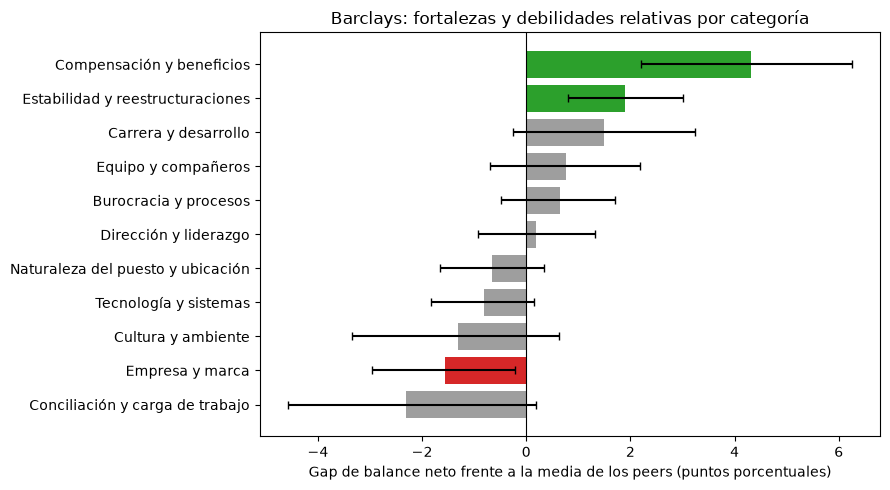

In [78]:
N_BOOT = 1000
rng = np.random.RandomState(SEED)

firmas_idx = {f: np.where(df["firm"].values == f)[0] for f in FIRMS}
P, C = ind_pros.values, ind_cons.values

def balance_firma(idx):
    """Balance neto por categoría (puntos porcentuales) con las reseñas idx de una empresa."""
    return (P[idx].mean(axis=0) - C[idx].mean(axis=0)) * 100

def gap_balance(muestras):
    """Balance de la empresa objetivo menos el balance medio de los peers."""
    bal = {f: balance_firma(muestras[f]) for f in FIRMS}
    return bal[TARGET] - np.mean([bal[f] for f in PEERS], axis=0)

gap_obs = gap_balance(firmas_idx)
gaps_boot = np.array([
    gap_balance({f: rng.choice(idx, len(idx), replace=True) for f, idx in firmas_idx.items()})
    for _ in range(N_BOOT)
])
ic_inf, ic_sup = np.percentile(gaps_boot, [2.5, 97.5], axis=0)

balance = pd.DataFrame({f: balance_firma(firmas_idx[f]) for f in FIRMS}, index=CATS_TEMATICAS)
balance["Media peers"] = balance[PEERS].mean(axis=1)
balance["Gap " + TARGET] = gap_obs
balance["IC95 inf"], balance["IC95 sup"] = ic_inf, ic_sup
balance["Lectura"] = np.where(balance["IC95 inf"] > 0, "Fortaleza relativa",
                      np.where(balance["IC95 sup"] < 0, "Debilidad relativa", "Sin diferencia clara"))
display(balance.sort_values("Gap " + TARGET, ascending=False).round(1))

# Gráfico: gap con su intervalo de confianza
g = balance.sort_values("Gap " + TARGET)
colores = g["Lectura"].map({"Fortaleza relativa": "#2ca02c", "Debilidad relativa": "#d62728",
                            "Sin diferencia clara": "#9e9e9e"})
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(g.index, g["Gap " + TARGET], color=colores,
        xerr=[g["Gap " + TARGET] - g["IC95 inf"], g["IC95 sup"] - g["Gap " + TARGET]], capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Gap de balance neto frente a la media de los peers (puntos porcentuales)")
ax.set_title("Barclays: fortalezas y debilidades relativas por categoría")
plt.tight_layout()
plt.savefig("fig_4_2_gaps.png", dpi=200, bbox_inches="tight")
plt.show()

Con el intervalo de confianza del 95 %, dos categorías muestran una fortaleza relativa de Barclays y una, una debilidad relativa; el resto no se distingue de la media de los peers.

La fortaleza más clara es Compensación y beneficios (gap de +4,3 puntos; IC de 2,2 a 6,3): Barclays tiene un balance de +5,2 frente a +0,9 de la media de los peers, y se debe sobre todo a que tiene menos reseñas con quejas de compensación (6,6 % frente al 10,6 %) y no a que la elogie más (11,8 % frente al 11,5 %). La segunda es Estabilidad y reestructuraciones (+1,9; IC de 0,8 a 3,0), también por tener menos quejas (4,0 % frente al 5,6 %), y es una diferencia pequeña cuya solidez se revisa en 4.3. La única debilidad relativa es Empresa y marca (−1,6; IC de −3,0 a −0,2): en Barclays solo el 5,7 % de las reseñas elogia la empresa, el sector o la marca, frente al 8,3 % de media, sobre todo por la diferencia con HSBC y Standard-Chartered-Bank (en torno al 10,5 %). Su intervalo roza el cero y, al evaluar 11 categorías a la vez, es esperable que alguna salga significativa por azar, por lo que se lee como indicativa.

En el resto de categorías no hay diferencia clara. Conciliación y carga de trabajo parece una debilidad (−2,3; IC de −4,6 a 0,2), pero depende de NatWest-Group, cuyo balance (+19,9) es muy superior al de los otros tres peers (entre +3,0 y +4,4); con los otros tres peers el gap de Barclays sería de unos +1,8. Carrera y desarrollo tampoco diferencia a Barclays (+1,5; IC de −0,3 a 3,2): tiene balance negativo en las cinco empresas (de −4,4 a −10,7) y es la categoría con más peso en los cons del conjunto, de modo que es un problema del sector y no específico de Barclays.

### 4.3 Robustez de los gaps

El gap de cada categoría depende de dos decisiones que conviene comprobar: el tratamiento de los outliers (3.9) y la composición de los peers, porque una media de solo cuatro empresas se mueve mucho si una es atípica, como NatWest-Group en Conciliación. Se recalcula el gap de dos maneras: reasignando los outliers al topic más cercano con un umbral de similitud de 0,5, y excluyendo uno a uno cada peer. Un gap se considera estable si conserva el mismo signo en las cuatro variantes (la base, la de outliers reasignados y los valores mínimo y máximo al excluir un peer). Un gap significativo en 4.2 pero no estable no se utilizará como conclusión firme.

In [79]:
UMBRAL_ROBUSTEZ = 0.5   # umbral de similitud para reasignar outliers

def indicadores_reasignados(modelo, docs, topics, emb, mapa, mascara):
    """Indicadores por categoría tras reasignar los outliers al topic más cercano (si supera el umbral)."""
    nuevos = np.array(modelo.reduce_outliers(docs, topics.tolist(), strategy="embeddings",
                                             embeddings=emb, threshold=UMBRAL_ROBUSTEZ))
    cat = pd.Series(nuevos, index=df.index[df[mascara]]).map(mapa)      # NaN si sigue siendo outlier
    ind = pd.get_dummies(cat).reindex(columns=CATS_TEMATICAS, fill_value=0).astype(float)
    return ind.reindex(df.index, fill_value=0).values

P2 = indicadores_reasignados(modelo_pros, docs_pros, topics_pros, emb_pros, mapa_pros, "en_topics_pros")
C2 = indicadores_reasignados(modelo_cons, docs_cons, topics_cons, emb_cons, mapa_cons, "en_topics_cons")

def gap_con(P_, C_, peers=PEERS):
    bal = {f: (P_[firmas_idx[f]].mean(axis=0) - C_[firmas_idx[f]].mean(axis=0)) * 100 for f in FIRMS}
    return bal[TARGET] - np.mean([bal[f] for f in peers], axis=0)

# Gap excluyendo cada peer por turno
sin_uno = np.array([gap_con(P, C, [p for p in PEERS if p != q]) for q in PEERS])

robustez = pd.DataFrame({
    "Gap base": gap_con(P, C),
    "Gap con outliers reasignados": gap_con(P2, C2),
    "Mín. sin un peer": sin_uno.min(axis=0),
    "Máx. sin un peer": sin_uno.max(axis=0),
}, index=CATS_TEMATICAS)

signos = np.sign(robustez.values)
robustez["Estable"] = np.where((signos == signos[:, [0]]).all(axis=1), "Sí", "No")
robustez["Lectura 4.2"] = balance["Lectura"]
display(robustez.sort_values("Gap base", ascending=False).round(1))

,Gap base,Gap con outliers reasignados,Mín. sin un peer,Máx. sin un peer,Estable,Lectura 4.2
Compensación y beneficios,4.3,7.2,3.1,5.2,Sí,Fortaleza relativa
Estabilidad y reestructuraciones,1.9,2.0,1.8,2.1,Sí,Fortaleza relativa
Carrera y desarrollo,1.5,0.7,0.2,2.3,Sí,Sin diferencia clara
Equipo y compañeros,0.8,0.9,0.3,1.2,Sí,Sin diferencia clara
Burocracia y procesos,0.7,0.8,-0.2,1.3,No,Sin diferencia clara
Dirección y liderazgo,0.2,-0.3,-0.1,0.5,No,Sin diferencia clara
Naturaleza del puesto y ubicación,-0.7,-0.8,-1.0,-0.3,Sí,Sin diferencia clara
Tecnología y sistemas,-0.8,-0.8,-1.1,-0.5,Sí,Sin diferencia clara
Cultura y ambiente,-1.3,-1.0,-1.5,-1.0,Sí,Sin diferencia clara
Empresa y marca,-1.6,-2.1,-2.8,-0.8,Sí,Debilidad relativa


Los dos gaps que 4.2 identificaba como fortalezas relativas se mantienen en las cuatro variantes: Compensación y beneficios va de +3,1 a +7,2 (el valor más alto al reasignar los outliers) y Estabilidad y reestructuraciones de +1,8 a +2,1. La debilidad en Empresa y marca también conserva el signo (de −0,8 a −2,8), aunque su intervalo en 4.2 roza el cero y, al evaluarse 11 categorías a la vez, se lee solo como indicativa.

Conciliación y carga de trabajo, que 4.2 mostraba como posible debilidad, no es estable: su gap va de −4,1 a +1,8 y cambia de signo según el grupo de peers. Con los balances de 4.2, excluir a NatWest-Group (cuyo +19,9 en esta categoría es muy superior al de los otros tres peers) lo deja en unos +1,8, y reasignar los outliers lo empeora hasta −4,1, de modo que no se extrae ninguna conclusión sobre ella. Burocracia y procesos y Dirección y liderazgo también cambian de signo y no son concluyentes. Carrera y desarrollo (de +0,2 a +2,3) y Cultura y ambiente (de −1,0 a −1,5) conservan el signo en todas las variantes, pero sus intervalos de 4.2 incluyen el cero, por lo que son tendencias no confirmadas.

Como quinta variante se excluyen las reseñas cuyo pro o cuyo con está en un topic mixto (los que combinan dos temas y se asignaron por su primer término, un 10,9 % de los pros y un 7,0 % de los cons), y se recalcula el gap con las reseñas restantes. Así se comprueba que la decisión de asignar los topics mixtos a una sola categoría no condiciona las conclusiones.

In [80]:
tp = df["topic_pros"].fillna(-99).astype(int).values
tc = df["topic_cons"].fillna(-99).astype(int).values
sin_mixtos = ~(np.isin(tp, list(MIXTOS_PROS)) | np.isin(tc, list(MIXTOS_CONS)))
idx_sm = {f: np.where((df["firm"].values == f) & sin_mixtos)[0] for f in FIRMS}
print(f"Reseñas que quedan sin topics mixtos: {sin_mixtos.sum()} de {len(df)}")

robustez["Gap sin topics mixtos"] = gap_balance(idx_sm)
cols_gap = ["Gap base", "Gap con outliers reasignados", "Mín. sin un peer", "Máx. sin un peer",
            "Gap sin topics mixtos"]
signos = np.sign(robustez[cols_gap].values)
robustez["Estable"] = np.where((signos == signos[:, [0]]).all(axis=1), "Sí", "No")
display(robustez[cols_gap + ["Estable", "Lectura 4.2"]].sort_values("Gap base", ascending=False).round(1))

Reseñas que quedan sin topics mixtos: 8328 de 10000


,Gap base,Gap con outliers reasignados,Mín. sin un peer,Máx. sin un peer,Gap sin topics mixtos,Estable,Lectura 4.2
Compensación y beneficios,4.3,7.2,3.1,5.2,3.7,Sí,Fortaleza relativa
Estabilidad y reestructuraciones,1.9,2.0,1.8,2.1,1.6,Sí,Fortaleza relativa
Carrera y desarrollo,1.5,0.7,0.2,2.3,0.9,Sí,Sin diferencia clara
Equipo y compañeros,0.8,0.9,0.3,1.2,0.9,Sí,Sin diferencia clara
Burocracia y procesos,0.7,0.8,-0.2,1.3,1.0,No,Sin diferencia clara
Dirección y liderazgo,0.2,-0.3,-0.1,0.5,0.2,No,Sin diferencia clara
Naturaleza del puesto y ubicación,-0.7,-0.8,-1.0,-0.3,-0.0,Sí,Sin diferencia clara
Tecnología y sistemas,-0.8,-0.8,-1.1,-0.5,-0.8,Sí,Sin diferencia clara
Cultura y ambiente,-1.3,-1.0,-1.5,-1.0,-1.4,Sí,Sin diferencia clara
Empresa y marca,-1.6,-2.1,-2.8,-0.8,-3.1,Sí,Debilidad relativa


Tras excluir los topics mixtos quedan 8.328 de las 10.000 reseñas (el 16,7 % tiene un pro o un con en un topic mixto). Los gaps relevantes mantienen su signo y su magnitud: Compensación y beneficios +3,7 (frente a +4,3 en la base), Estabilidad y reestructuraciones +1,6 (+1,9) y Empresa y marca −3,1 (−1,6), que se refuerza. Cultura y ambiente se mantiene en −1,4 (−1,3) y Carrera y desarrollo en +0,9 (+1,5). Por tanto, la decisión de asignar los topics mixtos a una sola categoría no condiciona las conclusiones de 4.2. Conciliación y carga de trabajo, Burocracia y procesos y Dirección y liderazgo siguen sin ser estables.

### 4.4 Contraste de las categorías con el rating y la recomendación

Si una categoría es realmente un problema, las reseñas que se quejan de ella deberían tener un rating más bajo y recomendar menos la empresa que el resto. Se calcula, para cada categoría de cons y de pros, el rating medio de sus reseñas (con su intervalo del 95 %), la diferencia con la media y el porcentaje que no recomienda. Se incluyen también los grupos técnicos como control: las reseñas que declaran no tener contras deberían puntuar por encima de la media, y las que dicen que no hay pros, por debajo. Se trabaja con todas las empresas juntas para tener tamaño suficiente en cada categoría.

In [81]:
grupo_cons = df["cat_cons"].where(~df["sin_contras_total"], "Sin contras (combinado)")

def contraste(grupo, nombre):
    d = df.assign(grupo=grupo).dropna(subset=["grupo"])
    t = d.groupby("grupo").agg(
        n=("overall_rating", "size"),
        rating=("overall_rating", "mean"),
        sd=("overall_rating", "std"),
        pct_no_recomienda=("recomienda", lambda s: (s == "No").mean() * 100),
    )
    t["dif_vs_media"] = t["rating"] - d["overall_rating"].mean()
    t["ic95"] = 1.96 * t["sd"] / np.sqrt(t["n"])
    print(f"\n{nombre} (rating medio del conjunto = {d['overall_rating'].mean():.2f}):")
    return t.drop(columns="sd").sort_values("rating").round(2)

display(contraste(grupo_cons, "Categorías de cons"))
display(contraste(df["cat_pros"], "Categorías de pros"))


Categorías de cons (rating medio del conjunto = 3.80):


,n,rating,pct_no_recomienda,dif_vs_media,ic95
grupo,,,,,
Dirección y liderazgo,359,3.18,31.75,-0.62,0.12
Cultura y ambiente,346,3.21,28.90,-0.60,0.13
Sin clasificar,2515,3.52,23.62,-0.28,0.04
Estabilidad y reestructuraciones,527,3.68,19.73,-0.12,0.09
Empresa y marca,351,3.69,21.65,-0.11,0.11
Carrera y desarrollo,1114,3.80,13.64,-0.01,0.05
Conciliación y carga de trabajo,904,3.81,14.49,0.01,0.07
Naturaleza del puesto y ubicación,402,3.83,16.67,0.03,0.11
Compensación y beneficios,978,3.83,12.58,0.03,0.06



Categorías de pros (rating medio del conjunto = 3.80):


,n,rating,pct_no_recomienda,dif_vs_media,ic95
grupo,,,,,
Sin pros declarados,63,2.25,58.73,-1.55,0.38
Compensación y beneficios,1153,3.45,25.15,-0.35,0.07
Empresa y marca,781,3.56,22.92,-0.25,0.08
Equipo y compañeros,620,3.69,18.23,-0.11,0.08
Estabilidad y reestructuraciones,71,3.72,9.86,-0.08,0.23
Conciliación y carga de trabajo,1633,3.84,14.64,0.04,0.05
Sin clasificar,2782,3.85,14.59,0.05,0.04
Carrera y desarrollo,455,3.91,12.31,0.11,0.09
Tecnología y sistemas,94,3.95,9.57,0.15,0.20


El rating medio del conjunto es 3,80. Como control, las reseñas que declaran no tener contras puntúan por encima (4,54, con solo un 2,3 % que no recomienda) y las que dicen que no hay pros, muy por debajo (2,25), lo que valida que las categorías se corresponden con la satisfacción esperada.

Entre los cons, las categorías cuyas reseñas puntúan significativamente por debajo de la media son Dirección y liderazgo (3,18, un 31,8 % no recomienda) y Cultura y ambiente (3,21, un 28,9 %), seguidas de los outliers (3,52) y, con una diferencia pequeña, Estabilidad y reestructuraciones (3,68). Por el criterio del enunciado, son las que indican un problema real. En cambio, las tres categorías más frecuentes entre las quejas, Carrera y desarrollo, Compensación y beneficios y Conciliación y carga de trabajo, tienen un rating igual al del conjunto (entre 3,80 y 3,83): son quejas habituales que no acompañan a una peor valoración global, y Burocracia y procesos incluso se asocia a una valoración algo mejor (3,99). Mencionar un contra no es, por tanto, equivalente a que ese contra pese en la satisfacción, y por eso la priorización no puede basarse solo en el peso de cada categoría.

Entre los pros, Cultura y ambiente es la categoría asociada a mayor satisfacción (4,05, 0,25 por encima de la media), mientras que Compensación y beneficios (3,45) y Empresa y marca (3,56) se asocian a una valoración inferior, con entre el 23 % y el 25 % de reseñas que no recomiendan. Son correlaciones y no relaciones causales, y se calculan sobre las cinco empresas juntas (el rating medio varía unos 0,17 puntos entre empresas), pero sugieren que quien cita el salario, los beneficios o la marca como único aspecto positivo tiende a estar menos satisfecho. Esto matiza la fortaleza de Barclays en compensación: procede de tener menos quejas (6,6 % frente al 10,6 % de los peers) y no de que se elogie más (11,8 % frente al 11,5 %).

### 4.5 Conclusiones de la comparación con los peers

Frente a sus peers, Barclays presenta una fortaleza relativa clara en Compensación y beneficios y otra, más pequeña, en Estabilidad y reestructuraciones, ambas estables ante el tratamiento de los outliers y la composición del grupo de comparación, y una debilidad indicativa en Empresa y marca. La fortaleza en compensación se debe a que menos reseñas se quejan (6,6 % frente al 10,6 %) y no a que se elogie más, y los pros de esa categoría se asocian a una valoración inferior a la media, por lo que conviene usarla con cautela en employer branding.

Las quejas más frecuentes del sector (Carrera y desarrollo, Compensación y Conciliación) no se asocian a peor valoración, y Barclays no se distingue de sus peers en ellas de forma concluyente. Las categorías cuyas quejas sí acompañan a una peor valoración son Dirección y liderazgo y Cultura y ambiente; en Dirección Barclays está en línea con sus peers y en Cultura presenta una tendencia desfavorable no confirmada (4,4 % de reseñas con quejas frente al 3,2 %, con un gap de balance de −1,3 puntos cuyo intervalo incluye el cero), que se vigilará en el análisis temporal y en la sección de recomendaciones.

---
## 5. Empleados actuales vs. antiguos


### 5.1 Qué cambia entre actuales y antiguos en Barclays

Los cons de quienes ya se han ido son, en la práctica, motivos de salida, y los de quienes siguen indican las fricciones que se toleran. Los antiguos puntúan más bajo en todas las empresas (apartado 1.2) por un sesgo de selección: quien se va tiene más motivos de queja. Por eso la comparación útil es la de temas y no la de sentimiento. Para cada categoría se calcula el porcentaje de reseñas de cada grupo (actuales y antiguos) que la mencionan, usando como denominador las reseñas del grupo, y la diferencia entre antiguos y actuales con un intervalo de confianza del 95 % por bootstrap.

Antes de interpretar las diferencias se comprueba que los dos grupos son comparables en el tiempo, porque si los antiguos escribieron en años distintos a los actuales, una diferencia de temas podría reflejar el año (por ejemplo, el efecto de la pandemia) y no la situación laboral. Como en 4.2, se evalúan 11 categorías a la vez, por lo que los intervalos que rozan el cero se leen como indicativos.

In [82]:
firma = df["firm"].values
situ = df["situacion"].values
idx_act = np.where((firma == TARGET) & (situ == "Actual"))[0]
idx_ant = np.where((firma == TARGET) & (situ == "Antiguo"))[0]
print(f"{TARGET}: {len(idx_act)} reseñas de empleados actuales y {len(idx_ant)} de antiguos")

# 1) ¿Son comparables en el tiempo? (% de reseñas de cada grupo por año)
d = df[df["firm"] == TARGET]
print("\n% de reseñas por año de publicación:")
display((pd.crosstab(d["situacion"], d["anio"], normalize="index") * 100).round(1))

# 2) Diferencia antiguos - actuales por categoría, con IC bootstrap
def tabla_dif(M, idx_a, idx_b, nombre_a="actuales", nombre_b="antiguos"):
    rng_ = np.random.RandomState(SEED)
    obs = (M[idx_b].mean(axis=0) - M[idx_a].mean(axis=0)) * 100
    boot = np.array([(M[rng_.choice(idx_b, len(idx_b))].mean(axis=0)
                      - M[rng_.choice(idx_a, len(idx_a))].mean(axis=0)) * 100 for _ in range(N_BOOT)])
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    t = pd.DataFrame({f"% {nombre_a}": M[idx_a].mean(axis=0) * 100,
                      f"% {nombre_b}": M[idx_b].mean(axis=0) * 100,
                      "Diferencia": obs, "IC95 inf": lo, "IC95 sup": hi}, index=CATS_TEMATICAS)
    t["Lectura"] = np.where(lo > 0, f"Más en {nombre_b}",
                    np.where(hi < 0, f"Más en {nombre_a}", "Sin diferencia clara"))
    return t.round(1).sort_values("Diferencia", ascending=False)

print(f"\nCONS de {TARGET}: antiguos menos actuales (puntos porcentuales)")
display(tabla_dif(C, idx_act, idx_ant))
print(f"\nPROS de {TARGET}: antiguos menos actuales (puntos porcentuales)")
display(tabla_dif(P, idx_act, idx_ant))

# 3) Ausencia declarada de contras por situación
print("\n% de reseñas sin contras (combinado) por situación:")
print((df[df["firm"] == TARGET].groupby("situacion")["sin_contras_total"].mean() * 100).round(1))

Barclays: 1332 reseñas de empleados actuales y 668 de antiguos

% de reseñas por año de publicación:


anio,2018,2019,2020,2021,2022,2023
situacion,,,,,,
Actual,3.9,13.3,15.4,34.6,27.6,5.3
Antiguo,5.7,16.3,18.9,30.2,23.4,5.5



CONS de Barclays: antiguos menos actuales (puntos porcentuales)


,% actuales,% antiguos,Diferencia,IC95 inf,IC95 sup,Lectura
Naturaleza del puesto y ubicación,3.8,6.1,2.4,0.2,4.7,Más en antiguos
Cultura y ambiente,3.8,5.7,1.9,-0.2,4.0,Sin diferencia clara
Estabilidad y reestructuraciones,3.5,4.9,1.4,-0.4,3.1,Sin diferencia clara
Empresa y marca,2.3,3.4,1.2,-0.5,2.8,Sin diferencia clara
Dirección y liderazgo,3.3,4.5,1.2,-0.5,3.2,Sin diferencia clara
Carrera y desarrollo,9.2,10.5,1.2,-1.7,4.0,Sin diferencia clara
Tecnología y sistemas,4.1,4.6,0.6,-1.1,2.5,Sin diferencia clara
Equipo y compañeros,2.5,2.7,0.2,-1.2,1.8,Sin diferencia clara
Burocracia y procesos,5.5,4.9,-0.5,-2.6,1.4,Sin diferencia clara
Compensación y beneficios,7.4,5.1,-2.3,-4.4,-0.1,Más en actuales



PROS de Barclays: antiguos menos actuales (puntos porcentuales)


,% actuales,% antiguos,Diferencia,IC95 inf,IC95 sup,Lectura
Empresa y marca,4.6,7.9,3.4,1.1,5.8,Más en antiguos
Compensación y beneficios,11.0,13.3,2.3,-0.9,5.2,Sin diferencia clara
Equipo y compañeros,6.7,8.8,2.2,-0.2,4.7,Sin diferencia clara
Carrera y desarrollo,3.9,4.9,1.0,-0.8,3.0,Sin diferencia clara
Naturaleza del puesto y ubicación,0.0,0.0,0.0,0.0,0.0,Sin diferencia clara
Burocracia y procesos,0.0,0.0,0.0,0.0,0.0,Sin diferencia clara
Tecnología y sistemas,1.0,0.9,-0.1,-1.0,0.9,Sin diferencia clara
Dirección y liderazgo,1.7,1.6,-0.1,-1.2,1.0,Sin diferencia clara
Estabilidad y reestructuraciones,1.2,0.4,-0.8,-1.5,0.1,Sin diferencia clara
Cultura y ambiente,13.7,11.4,-2.3,-5.4,0.8,Sin diferencia clara



% de reseñas sin contras (combinado) por situación:
situacion
Actual     18.6
Antiguo    12.4
Name: sin_contras_total, dtype: float64


**Comparabilidad temporal.** Los antiguos se concentran algo más en los primeros años (el 40,9 % de sus reseñas es de 2018 a 2020, frente al 32,6 % de los actuales). Es una diferencia moderada, pero significa que parte de la comparación puede reflejar el momento en que se escribió la reseña y no solo la situación laboral. Se tiene en cuenta como limitación, y la evolución temporal de las categorías se analiza en el apartado extra.

**Cons.** Entre las reseñas de Barclays, quienes ya se han ido mencionan más como queja Naturaleza del puesto y ubicación (6,1 % frente al 3,8 %; diferencia de 2,4 puntos, IC de 0,2 a 4,7) y, sin llegar a ser concluyente, Cultura y ambiente (5,7 % frente al 3,8 %; IC de −0,2 a 4,0), además de otras categorías de entorno (Estabilidad, Dirección, Empresa y marca y Carrera, entre 1,2 y 1,4 puntos más). Los empleados actuales, en cambio, se quejan más de Conciliación y carga de trabajo (10,3 % frente al 7,3 %) y de Compensación y beneficios (7,4 % frente al 5,1 %), con intervalos que apenas excluyen el cero. Quienes se van no se quejan más de salario ni de carga de trabajo que quienes se quedan, lo que sugiere que esos temas, aunque frecuentes, no explican por sí solos la salida en Barclays.

**Pros.** Los antiguos destacan más Empresa y marca (7,9 % frente al 4,6 %; IC de 1,1 a 5,8): conservan una buena imagen de la empresa. Los actuales destacan mucho más Conciliación y carga de trabajo (16,9 % frente al 10,5 %; diferencia de −6,4 puntos, IC de −9,4 a −3,0), la diferencia más clara de las tablas. Es coherente con que la conciliación sea una razón para quedarse, aunque la relación no tiene por qué ser causal: pueden quedarse justamente quienes la tienen bien resuelta. Por último, el 18,6 % de los actuales declara no tener contras frente al 12,4 % de los antiguos, una diferencia de 6,2 puntos superior a su margen de error (unos ±3,3).

Se comparan 11 categorías de cons y 9 de pros (las otras 2 no tienen topics de pros), por lo que cabe esperar uno o dos intervalos significativos solo por azar. Las diferencias con el intervalo lejos del cero (Conciliación y Empresa y marca en los pros) son más sólidas que las que lo rozan.

### 5.2 Motivos de salida de Barclays frente a sus peers

Se compara el perfil de cons de los antiguos empleados de Barclays con el de los antiguos de los cuatro peers. Para cada categoría se calcula el porcentaje de reseñas de antiguos que la mencionan en sus cons, y el gap es el de Barclays menos la media de los peers, con un intervalo de confianza del 95 % por bootstrap (se remuestrean las reseñas de antiguos de cada empresa). Un gap positivo indica un motivo de salida más frecuente en Barclays que en el mercado.

Para saber si un gap es específico de quienes se van, se muestra a su lado el gap equivalente entre empleados actuales: si una categoría solo destaca en los antiguos, es un motivo de salida; si destaca igual en actuales y antiguos, es una característica de la empresa. Con unas 700 reseñas de antiguos por empresa, los intervalos son anchos, y solo se interpretan los gaps que los excluyen del cero. Las diferencias inferiores a 2,4 puntos, el cambio máximo que produce el tratamiento de los outliers en los cons (apartado 3.9), se leen con cautela adicional.

In [83]:
idx_por_sit = {s: {f: np.where((firma == f) & (situ == s))[0] for f in FIRMS}
               for s in ["Actual", "Antiguo"]}
print("Reseñas de antiguos por empresa:", {f: len(i) for f, i in idx_por_sit["Antiguo"].items()})

def gap_pct(M, idx_por_firma):
    pct = {f: M[idx_por_firma[f]].mean(axis=0) * 100 for f in FIRMS}
    return pct[TARGET] - np.mean([pct[f] for f in PEERS], axis=0)

rng5 = np.random.RandomState(SEED)
obs_ant = gap_pct(C, idx_por_sit["Antiguo"])
boot_ant = np.array([gap_pct(C, {f: rng5.choice(i, len(i), replace=True)
                                 for f, i in idx_por_sit["Antiguo"].items()}) for _ in range(N_BOOT)])
lo, hi = np.percentile(boot_ant, [2.5, 97.5], axis=0)

salida = pd.DataFrame({f: C[idx_por_sit["Antiguo"][f]].mean(axis=0) * 100 for f in FIRMS},
                      index=CATS_TEMATICAS)
salida["Media peers"] = salida[PEERS].mean(axis=1)
salida["Gap antiguos"] = obs_ant
salida["IC95 inf"], salida["IC95 sup"] = lo, hi
salida["Gap actuales"] = gap_pct(C, idx_por_sit["Actual"])
salida["Lectura"] = np.where(lo > 0, "Motivo de salida más frecuente",
                      np.where(hi < 0, "Motivo de salida menos frecuente", "Sin diferencia clara"))
print("\n% de reseñas de antiguos con cons en cada categoría, y gap de Barclays frente a los peers:")
display(salida.sort_values("Gap antiguos", ascending=False).round(1))

Reseñas de antiguos por empresa: {'Barclays': 668, 'HSBC': 775, 'Standard-Chartered-Bank': 708, 'NatWest-Group': 722, 'Deutsche-Bank': 770}

% de reseñas de antiguos con cons en cada categoría, y gap de Barclays frente a los peers:


,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank,Media peers,Gap antiguos,IC95 inf,IC95 sup,Gap actuales,Lectura
Tecnología y sistemas,4.6,1.7,2.1,3.3,3.5,2.7,2.0,0.4,3.7,0.2,Motivo de salida más frecuente
Naturaleza del puesto y ubicación,6.1,4.8,3.8,5.5,3.2,4.3,1.8,-0.1,3.9,0.1,Sin diferencia clara
Cultura y ambiente,5.7,3.9,5.4,2.6,4.4,4.1,1.6,-0.2,3.5,1.1,Sin diferencia clara
Equipo y compañeros,2.7,1.4,2.5,0.7,2.5,1.8,0.9,-0.4,2.2,0.6,Sin diferencia clara
Dirección y liderazgo,4.5,6.3,4.2,4.2,3.5,4.6,-0.1,-1.7,1.7,0.3,Sin diferencia clara
Empresa y marca,3.4,4.0,3.1,3.5,4.7,3.8,-0.4,-1.9,1.3,-1.4,Sin diferencia clara
Carrera y desarrollo,10.5,9.4,10.0,13.7,10.3,10.9,-0.4,-2.9,2.3,-2.7,Sin diferencia clara
Burocracia y procesos,4.9,8.3,5.8,4.4,3.6,5.5,-0.6,-2.5,1.3,-0.7,Sin diferencia clara
Estabilidad y reestructuraciones,4.9,5.3,7.1,7.3,6.4,6.5,-1.6,-3.4,0.2,-1.5,Sin diferencia clara
Conciliación y carga de trabajo,7.3,11.7,11.4,6.2,9.0,9.6,-2.3,-4.5,-0.0,1.7,Motivo de salida menos frecuente


Con unas 700 reseñas de antiguos por empresa (de 668 a 775), solo un gap queda con el intervalo por encima de cero: Tecnología y sistemas es un motivo de salida más frecuente en Barclays (4,6 % de los antiguos frente al 2,7 % de media de los peers; gap de +2,0, IC de 0,4 a 3,7) y no se aprecia entre los empleados actuales (gap de +0,2), por lo que es específico de quienes se van. Hay que leerlo con cautela: su intervalo está cerca del cero, se evalúan 11 categorías a la vez y, según 4.4, las reseñas con quejas de tecnología puntúan por encima de la media (3,93), de modo que no indican una insatisfacción general.

Con intervalos que incluyen el cero, la dirección de los gaps coincide con la de 5.1: los antiguos de Barclays se quejan algo más de Naturaleza del puesto y ubicación (+1,8), Cultura y ambiente (+1,6) y Equipo y compañeros (+0,9) que los de los peers. En Cultura la diferencia también se observa entre los actuales (+1,1), por lo que es más una característica de la empresa que un motivo de salida específico.

En sentido contrario, los antiguos de Barclays se quejan menos que los de los peers de Compensación y beneficios (gap de −4,1; IC de −6,0 a −2,0), con la misma diferencia entre los actuales (−4,1): es una fortaleza general y no solo de quienes se van. También se quejan menos de Conciliación y carga de trabajo (−2,3; IC de −4,5 a 0,0, en el límite del cero), mientras que entre los actuales el gap es de +1,7, lo que indica que no es un motivo de salida habitual en Barclays. En Carrera y desarrollo, la categoría con más cons del sector, no hay diferencia entre antiguos (−0,4).

### 5.3 Conclusiones de la sección

Los motivos de salida de Barclays no se concentran en las categorías con más quejas del sector. Compensación y Conciliación, pese a ser de las más frecuentes en los cons, aparecen menos entre quienes se han ido que entre quienes se quedan, y entre los antiguos Barclays se sitúa mejor que sus peers en ambas (de forma sólida en compensación y en el límite del cero en conciliación). Lo que distingue a los antiguos de Barclays es una mayor queja por aspectos del entorno: Tecnología y sistemas, el único gap significativo frente a los peers (+2,0 puntos) y específico de los antiguos, y, con intervalos que incluyen el cero, Naturaleza del puesto y ubicación y Cultura y ambiente.

En atracción y retención, Conciliación y carga de trabajo es el pro que más separa a actuales de antiguos (16,9 % frente al 10,5 %), coherente con que sea una razón para quedarse, y Empresa y marca el que más valoran quienes ya se han ido (7,9 % frente al 4,6 %). Las limitaciones son el tamaño de muestra (unas 700 reseñas de antiguos por empresa, que da intervalos anchos y deja la mayoría de las diferencias sin confirmar), la ligera diferencia temporal entre actuales y antiguos y que las asociaciones no son causales: una queja en una reseña no demuestra que fuera el motivo de la salida.

---
## 6. Áreas de mejora y recomendaciones


### 6.1 Matriz de priorización

Para decidir qué áreas de mejora merecen atención se combinan en una matriz criterios que ya se han medido por separado. El eje horizontal es el peso de la categoría en los cons de Barclays (porcentaje de sus reseñas que la mencionan como queja), y el vertical, la desventaja frente a los peers: el gap de balance neto de 4.2 con el signo cambiado, de modo que un valor positivo indica que Barclays está peor que la media de sus peers y uno negativo, que está mejor. El color indica cuánto empeora la valoración de las reseñas que se quejan de esa categoría respecto a la media (4.4), y el tamaño crece con el número de señales que se cumplen entre estas tres: que la desventaja se mantenga con el mismo signo en las cinco variantes de 4.3, que las quejas se asocien a un rating significativamente inferior a la media (4.4) y que sea una queja significativamente más frecuente entre los antiguos de Barclays que entre los de los peers (5.2).

El criterio de prioridad sigue la lógica del encargo: un problema solo es prioritario si Barclays está peor que el mercado. Una categoría sin desventaja queda fuera, por frecuente que sea como queja. Con desventaja, la prioridad es alta si se cumplen al menos dos de las tres señales, media si se cumple una y "vigilar" si no se cumple ninguna. Se prima así la convergencia de evidencias independientes y no un único indicador, porque con 11 categorías evaluadas a la vez cualquier resultado aislado puede deberse al azar.


Rating de las reseñas que se quejan de cada categoría (rating medio del conjunto = 3.80):


,Peso en cons (%),Desventaja vs peers (pp),S1 Desventaja estable,Rating quejas (dif. vs media),S2 Quejas con peor rating,Gap antiguos (pp),S3 Más frecuente en antiguos,Señales,Prioridad
Cultura y ambiente,4.45,1.31,True,-0.60,True,1.62,False,2,Alta
Tecnología y sistemas,4.25,0.81,True,0.13,False,1.98,True,2,Alta
Empresa y marca,2.65,1.56,True,-0.11,False,-0.37,False,1,Media
Naturaleza del puesto y ubicación,4.55,0.66,True,0.03,False,1.79,False,1,Media
Dirección y liderazgo,3.70,-0.19,False,-0.62,True,-0.06,False,0,Sin prioridad (ventaja o en línea)
Burocracia y procesos,5.30,-0.65,False,0.19,False,-0.59,False,0,Sin prioridad (ventaja o en línea)
Equipo y compañeros,2.55,-0.76,False,0.15,False,0.91,False,0,Sin prioridad (ventaja o en línea)
Carrera y desarrollo,9.65,-1.49,False,-0.01,False,-0.38,False,0,Sin prioridad (ventaja o en línea)
Estabilidad y reestructuraciones,4.00,-1.89,False,-0.12,True,-1.57,False,0,Sin prioridad (ventaja o en línea)
Compensación y beneficios,6.60,-4.31,False,0.03,False,-4.06,False,0,Sin prioridad (ventaja o en línea)


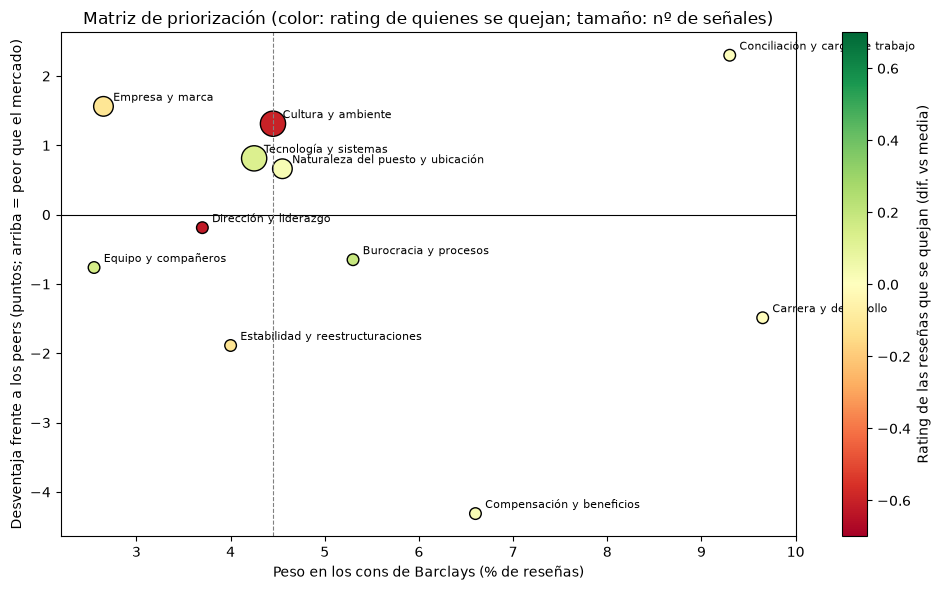

In [84]:
# Rating de las reseñas que se quejan de cada categoría (reutiliza la función de 4.4)
tab_sev = contraste(grupo_cons, "Rating de las reseñas que se quejan de cada categoría")

m = pd.DataFrame(index=CATS_TEMATICAS)
m["Peso en cons (%)"] = pct_cons.loc[TARGET]
m["Desventaja vs peers (pp)"] = -balance["Gap " + TARGET]       # positivo = peor que los peers
m["S1 Desventaja estable"] = (robustez["Estable"] == "Sí") & (m["Desventaja vs peers (pp)"] > 0)
m["Rating quejas (dif. vs media)"] = tab_sev["dif_vs_media"]
m["S2 Quejas con peor rating"] = (tab_sev["dif_vs_media"] + tab_sev["ic95"]) < 0
m["Gap antiguos (pp)"] = salida["Gap antiguos"]
m["S3 Más frecuente en antiguos"] = salida["IC95 inf"] > 0
m["Señales"] = (m[["S1 Desventaja estable", "S2 Quejas con peor rating",
                   "S3 Más frecuente en antiguos"]].sum(axis=1).where(m["Desventaja vs peers (pp)"] > 0, 0))

def prioridad(fila):
    if fila["Desventaja vs peers (pp)"] <= 0:
        return "Sin prioridad (ventaja o en línea)"
    return {0: "Vigilar", 1: "Media", 2: "Alta", 3: "Alta"}[int(fila["Señales"])]

m["Prioridad"] = m.apply(prioridad, axis=1)
display(m.sort_values(["Prioridad", "Desventaja vs peers (pp)"], ascending=[True, False]).round(2))

# Gráfico de la matriz
fig, ax = plt.subplots(figsize=(10, 6))
puntos = ax.scatter(m["Peso en cons (%)"], m["Desventaja vs peers (pp)"],
                    s=70 + 130 * m["Señales"], c=m["Rating quejas (dif. vs media)"],
                    cmap="RdYlGn", vmin=-0.7, vmax=0.7, edgecolor="black")
for nombre, f in m.iterrows():
    ax.annotate(nombre, (f["Peso en cons (%)"], f["Desventaja vs peers (pp)"]),
                textcoords="offset points", xytext=(7, 4), fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(m["Peso en cons (%)"].median(), color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Peso en los cons de Barclays (% de reseñas)")
ax.set_ylabel("Desventaja frente a los peers (puntos; arriba = peor que el mercado)")
ax.set_title("Matriz de priorización (color: rating de quienes se quejan; tamaño: nº de señales)")
plt.colorbar(puntos, label="Rating de las reseñas que se quejan (dif. vs media)")
plt.tight_layout()
plt.savefig("fig_6_1_matriz.png", dpi=200, bbox_inches="tight")
plt.show()

Ninguna categoría con desventaja frente a los peers acumula las tres señales. Dos alcanzan prioridad alta, con dos señales cada una: Cultura y ambiente (desventaja de 1,3 puntos, estable en las cinco variantes; las reseñas que se quejan puntúan 0,60 por debajo de la media, una de las mayores penalizaciones de la tabla junto con Dirección y liderazgo) y Tecnología y sistemas (desventaja de 0,8 puntos, estable; queja significativamente más frecuente entre los antiguos de Barclays que entre los de los peers, 4,6 % frente al 2,7 %). Empresa y marca y Naturaleza del puesto y ubicación quedan en prioridad media, con una sola señal. Conciliación y carga de trabajo queda en "vigilar": su desventaja de 2,3 puntos no es estable y depende de que NatWest-Group destaque la conciliación como pro en el 26 % de sus reseñas.

Las cuatro categorías con más peso entre las quejas de Barclays (Carrera y desarrollo, 9,6 %; Conciliación y carga de trabajo, 9,3 %; Compensación y beneficios, 6,6 %; y Burocracia y procesos, 5,3 %) no tienen una desventaja estable frente al mercado y sus quejas no se asocian a peor valoración (rating entre 3,79 y 3,99, frente a una media de 3,80). Son quejas habituales de todo el sector, y dedicar recursos a ellas no cambiaría la posición de Barclays frente a sus competidores. Las áreas prioritarias pesan menos, alrededor del 4 % de las reseñas cada una, pero es donde Barclays está algo peor que sus peers.

Ninguna de las dos categorías de prioridad alta tiene un gap significativo por sí sola (el intervalo de confianza de 4.2 incluye el cero en ambas), y su prioridad se apoya en la convergencia de señales. Por eso las recomendaciones que siguen proponen validar con datos internos antes de actuar de forma general.

### 6.2 Qué hay dentro de las áreas prioritarias

Para convertir las categorías en acciones concretas, se mira dentro de las que salen con prioridad alta o media: qué topics concentran las quejas y cómo se comparan con los peers, y se leen cinco reseñas reales de Barclays elegidas al azar como ejemplo cualitativo. Los ejemplos ilustran el tipo de queja pero no la demuestran, porque cinco reseñas no son representativas de toda la categoría.

In [85]:
def detalle_topics(cat):
    filas = []
    for t, c in mapa_cons.items():
        if c != cat:
            continue
        marca = df["topic_cons"].fillna(-99).astype(int) == t
        pct = marca.groupby(df["firm"]).mean() * 100
        filas.append({"topic": t, "palabras clave": ", ".join(p for p, _ in modelo_cons.get_topic(t)[:5]),
                      "Barclays (%)": pct[TARGET], "Media peers (%)": pct[PEERS].mean()})
    return pd.DataFrame(filas).set_index("topic").round(1)

prioritarias = m.index[m["Prioridad"].isin(["Alta", "Media"])].tolist()
for cat in prioritarias:
    print(f"\n=== {cat} (prioridad {m.loc[cat, 'Prioridad']}) ===")
    display(detalle_topics(cat))
    ejemplos = df[(df["firm"] == TARGET) & (df["cat_cons"] == cat)]["cons"]
    for texto in ejemplos.sample(min(5, len(ejemplos)), random_state=SEED):
        print("  ·", texto[:170])


=== Cultura y ambiente (prioridad Alta) ===


,palabras clave,Barclays (%),Media peers (%)
topic,,,
12,"culture, toxic, work culture, poor, working culture",2.2,1.7
15,"politics, office politics, political, internal politics, office",2.2,1.5


  · Political culture and constant change
  · Political in nature and hence need to manage that
  · Office politics , employees lack proactiveness
  · Politics exist in many areas
  · Culture could differ considerably depending on which division you were in.

=== Tecnología y sistemas (prioridad Alta) ===


,palabras clave,Barclays (%),Media peers (%)
topic,,,
8,"technology, technologies, legacy, tech, old",3.5,2.6
26,"systems, old, outdated, old systems, german",0.8,0.8


  · Technology a little behind market
  · Technology should be improved for future
  · Dated systems and tech capabilities
  · Technology needs a little improvement
  · technology is not upto date

=== Empresa y marca (prioridad Media) ===


,palabras clave,Barclays (%),Media peers (%)
topic,,,
4,"bank, banks, banking, investment, compared",2.6,3.7


  · Highly frustrating processes, conservative credit appetite
  · Management have difficulty treating their teams like adults. Bank is run from one quarter to the next with no long term sustainable vision.
  · Work Load compare to other banks is not that much.
  · Need a thick skin and people skills when dealing with customers, people get pissy when it comes to their money. Processes slow to change You need to be able to adapt to r
  · salary not competitive compared to similar roles with other banks

=== Naturaleza del puesto y ubicación (prioridad Media) ===


,palabras clave,Barclays (%),Media peers (%)
topic,,,
13,"boring, monotonous, work, place, repetitive",1.5,1.8
19,"customers, sales, targets, customer, target",1.2,1.1
33,"location, far, office, home, distance",1.0,0.5
34,"meetings, customers, centre, job, breaks",1.0,0.5


  · Very monotonous kind of work
  · Sometimes work can be very tedious and monotonous
  · Hybrid roles are becoming more call center-ish
  · No down side, easy going work
  · Saturday Working and rude customers


En Cultura y ambiente, la diferencia con los peers está en los dos topics: el clima tóxico (2,2 % de las reseñas frente al 1,7 %) y la política interna (2,2 % frente al 1,5 %, unas 44 reseñas frente a 30). Las reseñas leídas apuntan a la política interna y a una cultura que cambia según la división. En Tecnología y sistemas, la diferencia está en el topic de tecnología obsoleta (3,5 % frente al 2,6 %), y las cinco reseñas hablan de tecnología y sistemas anticuados o por detrás del mercado.

En Empresa y marca, el topic de cons es menos frecuente en Barclays que en sus peers (2,6 % frente al 3,7 %), de modo que su desventaja no viene de más quejas sino de los pros: solo el 5,7 % de sus reseñas elogia la empresa o la marca, frente al 8,3 % de media (en torno al 10,5 % en HSBC y Standard-Chartered-Bank). Es una oportunidad de comunicación y no un problema de gestión. En Naturaleza del puesto y ubicación, la diferencia se concentra en dos topics muy pequeños (ubicación y puestos de atención telefónica, un 1,0 % frente al 0,5 %, unas 20 reseñas frente a 10 en cada uno), una base demasiado fina y probablemente ligada a la mezcla de áreas y países. Una de las cinco reseñas leídas ("No down side, easy going work") no es en realidad una queja, lo que ilustra el ruido de estos topics.

### 6.3 Recomendaciones para RRHH

Las tres recomendaciones siguientes se redactan para el departamento de Recursos Humanos y se limitan a lo que los datos sostienen. Dos van dirigidas a la retención y una a la atracción de talento.

**1. Investigar la cultura y la política interna antes de actuar (retención).** Es el área donde más señales coinciden. En todas las variantes del análisis, Barclays queda algo por debajo de sus competidores en cultura; las reseñas que se quejan de ella son las que dan la peor valoración (3,2 sobre 5, frente a 3,8 de media, y casi tres de cada diez no recomiendan la empresa), y los antiguos empleados la mencionan más que los actuales (5,7 % frente al 3,8 %). La queja se concentra en la política interna y en que la cultura cambia según la división. Ninguna de estas señales es concluyente por sí sola, así que se propone cruzar el clima laboral y la rotación por división y añadir una pregunta específica en las entrevistas de salida, para localizar dónde ocurre antes de lanzar un programa general.

**2. Revisar las herramientas y sistemas tecnológicos como motivo de salida (retención).** Es el único motivo de salida en el que Barclays se distingue de sus competidores con significación estadística: lo menciona el 4,6 % de sus antiguos empleados frente al 2,7 % en los peers, y no se observa entre los actuales. Las quejas hablan de tecnología y sistemas anticuados o por detrás del mercado. Como las reseñas que lo mencionan no puntúan peor que la media, no parece un descontento general, sino específico de ciertos perfiles, probablemente técnicos, aunque los datos no permiten comprobarlo. Se propone preguntar por ello en las entrevistas de salida y hacer un inventario de las herramientas peor valoradas por los equipos con más rotación.

**3. Comunicar las fortalezas y reforzar la marca empleadora (atracción).** Barclays recibe menos quejas que sus competidores sobre compensación y beneficios (el 6,6 % de sus reseñas frente al 10,6 %) y, en menor medida, sobre estabilidad y reestructuraciones (4,0 % frente al 5,6 %), con una ventaja estable en todas las comprobaciones. Son argumentos creíbles para atraer talento, con un matiz: la ventaja viene de recibir menos críticas y no de recibir más elogios, y quienes citan la compensación como único aspecto positivo puntúan por debajo de la media, por lo que no conviene basar el mensaje solo en el salario. Se aconseja acompañarlo de la cultura y la conciliación, los pros más asociados a satisfacción (4,05 y 3,84 sobre 5), en los que Barclays está en línea con el mercado. Además, solo el 5,7 % de las reseñas de Barclays elogia la empresa o la marca, frente al 8,3 % de media, mientras que los antiguos sí lo hacen (7,9 %): hay margen para reforzar el orgullo de pertenencia y para activar a los antiguos empleados como embajadores.

**Qué no priorizar.** Las quejas más frecuentes (carrera y desarrollo, conciliación, compensación y burocracia) son habituales en todo el sector, no se asocian a una peor valoración y Barclays no está peor que sus competidores en ellas. Invertir en ellas mejoraría el clima en general, pero no cambiaría su posición frente al mercado.

| Palanca | Plan | Evidencia principal | Fiabilidad |
|---|---|---|---|
| Cultura y política interna | Retención | Desventaja estable de 1,3 puntos; quejas con la peor valoración (3,2); más frecuente entre antiguos | Media-baja: ninguna señal significativa por sí sola |
| Tecnología y sistemas | Retención | 4,6 % de los antiguos frente al 2,7 % de los peers; no se ve entre los actuales | Media: significativa, con intervalo cercano al cero |
| Compensación y estabilidad | Atracción | Menos quejas que los peers (ventaja de 4,3 y 1,9 puntos), estable en todas las comprobaciones | Alta en compensación, media en estabilidad |
| Marca empleadora | Atracción | Menos elogios a la empresa que los peers (5,7 % frente al 8,3 %) | Media-baja: el intervalo roza el cero |
| Conciliación y carga de trabajo | Mantener | Principal razón para quedarse (16,9 % de los pros de actuales frente al 10,5 % en antiguos); en línea con los peers | Media |

### 6.4 Limitaciones del análisis y próximos pasos

**Representatividad de Glassdoor.** Las reseñas son voluntarias y las escriben quienes quieren opinar, así que no representan a toda la plantilla y tienden a recoger las experiencias más marcadas. Además, el 39,8 % de las reseñas no indica la antigüedad, y las empresas se comparan con una muestra de 2.000 reseñas cada una (en Barclays, el 20 % de las 9.863 disponibles).

**Mezcla de países y áreas.** Las reseñas proceden de distintos países y áreas de negocio sin que el fichero incluya una variable que permita separarlos; en las lecturas aparecen referencias a India, Reino Unido, Singapur o Emiratos Árabes, y puestos tan distintos como la atención telefónica, la tecnología o la banca de inversión. Una diferencia entre empresas puede reflejar su mezcla de países y áreas (por ejemplo, el peso de los puestos de atención al cliente en la categoría de naturaleza del puesto) y no una diferencia de gestión.

**Precisión de los topics.** Cada reseña se asigna a un único topic, de modo que las que combinan varios temas se asignan a uno solo; el 27–28 % de las reseñas no se asigna a ningún topic; entre el 7 % y el 11 % están en topics que mezclan dos temas, y la pertenencia a los topics de "sin contras" es una estimación (en la muestra revisada, 1 de cada 10 reseñas del topic 2 era una queja). Las categorías de negocio se asignaron manualmente. Para acotar el efecto de estas decisiones se repitió el cálculo con otras cuatro variantes (apartado 4.3) y se conservaron solo las conclusiones que resistían.

**Modelo de sentimiento.** Es binario y se entrenó con críticas de cine, por lo que se usó solo como control de calidad. Queda sin explicar una diferencia de 3 a 4,5 puntos en la proporción de cons clasificados como negativos entre Barclays y Standard-Chartered-Bank frente a las otras tres empresas.

**Estadística.** Se evalúan 11 categorías a la vez, por lo que algún resultado puede salir significativo por azar, y entre los antiguos (unos 700 por empresa) los intervalos son anchos. Los resultados dependen también de la elección de peers (NatWest-Group, por ejemplo, altera la media en conciliación) y la ventana temporal acaba en abril de 2023. Todas las relaciones son asociaciones y no causas: una queja en una reseña no demuestra que fuera el motivo de la salida.

**Próximos pasos.** Contrastar los hallazgos con datos internos (rotación por área y país, entrevistas de salida y encuestas de clima), que permitirían separar países y áreas y confirmar los motivos de salida. Validar la asignación de categorías con una muestra de reseñas etiquetadas a mano, lo que daría una medida directa de su precisión, o con un clasificador de tipo zero-shot. Ampliar el grupo de comparación a más peers, a otros sectores que compitan por el mismo talento y a un periodo más largo. Y repetir el análisis cada año para seguir la evolución de las áreas identificadas.

---
## 7. Extra: evolución temporal y análisis por recomendación y por antigüedad

Estos análisis completan el diagnóstico con tres preguntas: si la posición de Barclays frente a los peers ha cambiado con el tiempo, a qué se debió el descenso del rating de 2021 que se vio en 1.3, y qué temas distinguen a quienes no recomiendan la empresa y a quienes llevan más o menos años en ella. Se mantienen los criterios de las secciones anteriores: los gaps se calculan sobre balance neto y se acompañan de intervalos de confianza del 95 % por bootstrap, y las diferencias con el intervalo sobre el cero se leen como indicativas. Al dividir la muestra en periodos o grupos, cada celda tiene menos reseñas, así que los intervalos son más anchos que en la sección 4 y la mayoría de las diferencias no serán concluyentes.

### 7.1 Evolución de las categorías por periodo

Se agrupan los años en tres periodos que tienen sentido en el tiempo: 2018-2019 (antes de la pandemia), 2020-2021 (pandemia y expansión del trabajo en remoto) y 2022-2023 (después). Agrupar de dos en dos años da tamaños más estables que un análisis anual (entre unas 350 y 1.000 reseñas por empresa y periodo). Recuérdese que 2018 y 2023 son años parciales. Para cada periodo se calcula el gap de balance neto de Barclays frente a la media de los peers (positivo indica una fortaleza relativa) con su intervalo de confianza, y se marca con un asterisco el que excluye el cero. Debajo se muestra el rating y el peso de cada categoría en las reseñas de Barclays, para ver si los cambios vienen de Barclays o del mercado.

Reseñas por empresa y periodo:


periodo,2018-2019,2020-2021,2022-2023
firm,,,
Barclays,376,994,630
HSBC,381,920,699
Standard-Chartered-Bank,351,856,793
NatWest-Group,474,921,605
Deutsche-Bank,407,884,709



Gap de balance de Barclays frente a los peers (* = intervalo del 95 % sin el cero):


,2018-2019,2020-2021,2022-2023
Compensación y beneficios,+2.3,+4.0*,+5.7*
Conciliación y carga de trabajo,-4.0,-3.3*,+0.5
Carrera y desarrollo,-1.1,+1.6,+3.0
Dirección y liderazgo,-0.2,+1.2,-1.1
Cultura y ambiente,-2.2,-0.4,-1.9
Equipo y compañeros,-0.1,+0.5,+1.5
Burocracia y procesos,+1.3,+0.9,+0.0
Estabilidad y reestructuraciones,+4.0*,+0.8,+2.3*
Tecnología y sistemas,+1.0,-1.5,-1.0
Empresa y marca,-1.4,-1.4,-2.2*


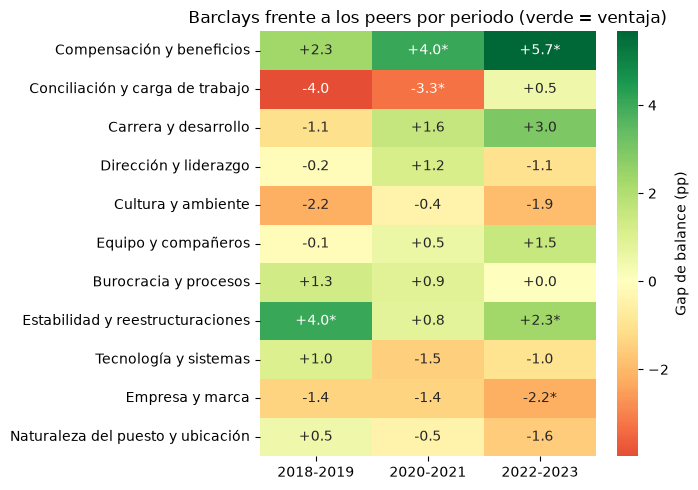


Rating medio por empresa y periodo:


periodo,2018-2019,2020-2021,2022-2023
firm,,,
Barclays,3.81,3.88,3.94
HSBC,3.65,3.75,3.79
Standard-Chartered-Bank,3.67,3.82,3.89
NatWest-Group,3.65,3.89,3.92
Deutsche-Bank,3.37,3.74,3.88



% de reseñas de Barclays con pros en cada categoría, por periodo:


periodo,2018-2019,2020-2021,2022-2023
Compensación y beneficios,12.8,11.4,11.9
Conciliación y carga de trabajo,15.2,12.4,18.3
Carrera y desarrollo,4.3,4.1,4.4
Dirección y liderazgo,1.9,1.8,1.4
Cultura y ambiente,11.4,13.7,12.5
Equipo y compañeros,6.1,7.2,8.4
Burocracia y procesos,0.0,0.0,0.0
Estabilidad y reestructuraciones,1.1,0.6,1.4
Tecnología y sistemas,1.6,0.7,1.0
Empresa y marca,5.6,6.8,4.0



% de reseñas de Barclays con cons en cada categoría, por periodo:


periodo,2018-2019,2020-2021,2022-2023
Compensación y beneficios,6.1,5.7,8.3
Conciliación y carga de trabajo,9.8,8.7,10.0
Carrera y desarrollo,11.2,9.8,8.6
Dirección y liderazgo,5.9,2.8,3.8
Cultura y ambiente,4.8,4.9,3.5
Equipo y compañeros,2.7,2.2,3.0
Burocracia y procesos,4.8,5.3,5.6
Estabilidad y reestructuraciones,3.7,4.7,3.0
Tecnología y sistemas,3.2,4.7,4.1
Empresa y marca,1.9,3.0,2.5


In [86]:
PERIODOS = {2018: "2018-2019", 2019: "2018-2019", 2020: "2020-2021",
            2021: "2020-2021", 2022: "2022-2023", 2023: "2022-2023"}
ORDEN_PERIODOS = ["2018-2019", "2020-2021", "2022-2023"]
df["periodo"] = df["anio"].map(PERIODOS)

print("Reseñas por empresa y periodo:")
display(pd.crosstab(df["firm"], df["periodo"]).loc[FIRMS, ORDEN_PERIODOS])

firma = df["firm"].values
periodo = df["periodo"].values
rng7 = np.random.RandomState(SEED)

def gap_por_periodo(p):
    idx = {f: np.where((firma == f) & (periodo == p))[0] for f in FIRMS}
    obs = gap_balance(idx)
    boot = np.array([gap_balance({f: rng7.choice(i, len(i), replace=True) for f, i in idx.items()})
                     for _ in range(N_BOOT)])
    lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)
    return obs, lo, hi

res = {p: gap_por_periodo(p) for p in ORDEN_PERIODOS}
gap_tab = pd.DataFrame({p: res[p][0] for p in ORDEN_PERIODOS}, index=CATS_TEMATICAS)
signif = pd.DataFrame({p: (res[p][1] > 0) | (res[p][2] < 0) for p in ORDEN_PERIODOS},
                      index=CATS_TEMATICAS)
etiquetas = gap_tab.apply(lambda col: pd.Series(
    [f"{v:+.1f}" + ("*" if s else "") for v, s in zip(col, signif[col.name])], index=col.index))

print("\nGap de balance de Barclays frente a los peers (* = intervalo del 95 % sin el cero):")
display(etiquetas)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(gap_tab, annot=etiquetas, fmt="", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Gap de balance (pp)"}, ax=ax)
ax.set_title("Barclays frente a los peers por periodo (verde = ventaja)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("fig_7_1_periodos.png", dpi=200, bbox_inches="tight")
plt.show()

# Rating y peso de cada categoría en las reseñas de Barclays
d = df[df["firm"] == TARGET]
print("\nRating medio por empresa y periodo:")
display(df.groupby(["firm", "periodo"])["overall_rating"].mean().unstack()[ORDEN_PERIODOS]
        .loc[FIRMS].round(2))
for nombre, ind in [("pros", ind_pros), ("cons", ind_cons)]:
    print(f"\n% de reseñas de Barclays con {nombre} en cada categoría, por periodo:")
    display(ind.loc[d.index].groupby(d["periodo"]).mean().mul(100)
            .loc[ORDEN_PERIODOS].T.round(1))

Barclays tiene un rating medio superior a la media de los peers en los tres periodos, pero la ventaja se estrecha: unos 0,22 puntos en 2018-2019 (3,81 frente a 3,59), 0,08 en 2020-2021 y 0,07 en 2022-2023 (3,94 frente a 3,87), porque los peers mejoran más (en promedio 0,29 puntos frente a los 0,13 de Barclays; Deutsche-Bank pasa de 3,37 a 3,88). Con márgenes de error de unos ±0,1, solo la ventaja del primer periodo es claramente distinta de cero.

Los gaps por categoría confirman las fortalezas ya identificadas: Compensación y beneficios es una ventaja que crece (de +2,3 a +4,0 y +5,7, significativa en los dos últimos periodos) y Estabilidad y reestructuraciones es significativa en el primero y en el último (+4,0 y +2,3). La ventaja en compensación es relativa: el balance de Barclays baja de +6,7 a +3,6 (el peso de sus quejas sube del 5,7 % al 8,3 % en el último periodo), pero el de los peers baja más, de +4,4 a −2,1. Empresa y marca se acentúa como debilidad en el último periodo (−2,2, significativo), con una caída de los elogios de Barclays del 6,8 % al 4,0 %. Cultura y ambiente es desfavorable en los tres periodos (−2,2, −0,4 y −1,9) aunque en ninguno es significativo. Conciliación y carga de trabajo es una desventaja en 2018-2021 (−4,0 y −3,3, esta última significativa) que desaparece en 2022-2023 (+0,5), cuando los pros de conciliación de Barclays suben del 12,4 % al 18,3 %. Carrera y desarrollo mejora de forma sostenida (de −1,1 a +3,0, sin llegar a ser significativa) y Tecnología y sistemas pasa de +1,0 a −1,5 y −1,0.

Se evalúan 33 combinaciones y 6 son significativas, por lo que cabe esperar que alguna sea fruto del azar; se dan más peso a las que repiten el signo en los periodos (compensación, estabilidad, cultura) que a las que aparecen en uno solo.

### 7.2 El descenso del rating de Barclays en 2021

En 1.3 el rating de Barclays cae de 4,00 en 2020 a 3,82 en 2021 y se recupera en 2022 (3,93). Antes de buscar una causa en los temas se comprueba si es un cambio de composición: si en 2021 hay más antiguos (que puntúan menos) o más reseñas con determinada situación, el descenso reflejaría eso y no un empeoramiento. Después se compara 2021 con la media de 2020 y 2022 en cada categoría de pros y de cons, con intervalos por bootstrap. Con 663 reseñas en 2021 y 854 en los años de referencia los intervalos son razonablemente estrechos.

In [87]:
d = df[df["firm"] == TARGET]
diag = d.groupby("anio").agg(
    n=("overall_rating", "size"),
    rating=("overall_rating", "mean"),
    pct_actuales=("situacion", lambda s: (s == "Actual").mean() * 100),
    pct_no_recomienda=("recomienda", lambda s: (s == "No").mean() * 100),
    pct_sin_contras=("sin_contras_total", lambda s: s.mean() * 100),
)
diag["rating_actuales"] = d[d["situacion"] == "Actual"].groupby("anio")["overall_rating"].mean()
diag["rating_antiguos"] = d[d["situacion"] == "Antiguo"].groupby("anio")["overall_rating"].mean()
print("Diagnóstico de composición por año (Barclays):")
display(diag.round(2))

anio = df["anio"].values
idx_2021 = np.where((firma == TARGET) & (anio == 2021))[0]
idx_ref = np.where((firma == TARGET) & np.isin(anio, [2020, 2022]))[0]
print(f"\nBarclays: {len(idx_2021)} reseñas de 2021 frente a {len(idx_ref)} de 2020 y 2022")

print("\nCONS: 2021 menos la media de 2020 y 2022 (puntos porcentuales):")
display(tabla_dif(C, idx_ref, idx_2021, "2020 y 2022", "2021"))
print("\nPROS: 2021 menos la media de 2020 y 2022 (puntos porcentuales):")
display(tabla_dif(P, idx_ref, idx_2021, "2020 y 2022", "2021"))

Diagnóstico de composición por año (Barclays):


,n,rating,pct_actuales,pct_no_recomienda,pct_sin_contras,rating_actuales,rating_antiguos
anio,,,,,,,
2018,90,3.61,57.78,23.33,13.33,3.71,3.47
2019,286,3.87,61.89,13.29,13.29,3.98,3.71
2020,331,4.00,61.93,11.78,17.82,4.01,3.98
2021,663,3.82,69.53,13.27,16.14,3.98,3.45
2022,523,3.93,70.17,13.77,17.02,4.03,3.69
2023,107,4.02,65.42,11.21,24.30,4.16,3.76



Barclays: 663 reseñas de 2021 frente a 854 de 2020 y 2022

CONS: 2021 menos la media de 2020 y 2022 (puntos porcentuales):


,% 2020 y 2022,% 2021,Diferencia,IC95 inf,IC95 sup,Lectura
Tecnología y sistemas,4.2,5.3,1.1,-1.0,3.3,Sin diferencia clara
Cultura y ambiente,4.1,4.8,0.7,-1.4,2.8,Sin diferencia clara
Carrera y desarrollo,9.3,9.8,0.6,-2.4,3.7,Sin diferencia clara
Estabilidad y reestructuraciones,3.9,4.4,0.5,-1.5,2.5,Sin diferencia clara
Burocracia y procesos,5.3,5.7,0.5,-1.7,3.0,Sin diferencia clara
Equipo y compañeros,2.7,2.3,-0.4,-2.0,1.1,Sin diferencia clara
Naturaleza del puesto y ubicación,5.2,4.7,-0.5,-2.7,1.6,Sin diferencia clara
Conciliación y carga de trabajo,9.5,8.6,-0.9,-3.8,2.0,Sin diferencia clara
Compensación y beneficios,6.9,6.0,-0.9,-3.2,1.5,Sin diferencia clara
Empresa y marca,3.3,2.3,-1.0,-2.7,0.7,Sin diferencia clara



PROS: 2021 menos la media de 2020 y 2022 (puntos porcentuales):


,% 2020 y 2022,% 2021,Diferencia,IC95 inf,IC95 sup,Lectura
Empresa y marca,4.1,8.0,3.9,1.5,6.4,Más en 2021
Cultura y ambiente,12.4,14.3,1.9,-1.6,5.2,Sin diferencia clara
Compensación y beneficios,11.1,12.1,0.9,-2.4,4.3,Sin diferencia clara
Naturaleza del puesto y ubicación,0.0,0.0,0.0,0.0,0.0,Sin diferencia clara
Burocracia y procesos,0.0,0.0,0.0,0.0,0.0,Sin diferencia clara
Estabilidad y reestructuraciones,1.1,0.8,-0.3,-1.3,0.6,Sin diferencia clara
Tecnología y sistemas,1.2,0.5,-0.7,-1.7,0.2,Sin diferencia clara
Dirección y liderazgo,2.1,1.2,-0.9,-2.2,0.5,Sin diferencia clara
Equipo y compañeros,8.3,7.2,-1.1,-4.0,1.7,Sin diferencia clara
Carrera y desarrollo,4.8,3.5,-1.3,-3.3,0.6,Sin diferencia clara


El descenso del rating de Barclays en 2021 (de 4,00 a 3,82) no se debe a un cambio de composición: el porcentaje de empleados actuales sube en 2021 (69,5 % frente al 61,9 % en 2020), lo que por sí solo habría elevado la media. Se explica por la valoración de los antiguos, que es de 3,45 en 2021 frente a 3,98 en 2020 y 3,69 en 2022, mientras que la de los actuales apenas cambia (3,98 frente a 4,01 y 4,03). Con unas 200 reseñas de antiguos en 2021 y unas 125 en 2020, el margen de error de cada media es de en torno a ±0,2, de modo que la caída de 0,53 puntos es clara. Parte del descenso refleja además un máximo en 2020, ya que los antiguos de ese año puntúan 3,98, frente a 3,71 en 2019. Es un descenso específico de Barclays: entre 2020 y 2021 el rating de los peers varía entre −0,07 (HSBC) y +0,09 (Deutsche-Bank).

Los temas no explican el descenso. En los cons, la única diferencia significativa va en sentido contrario: en 2021 hay menos quejas sobre Dirección y liderazgo (2,1 % frente al 4,2 % de 2020 y 2022; IC de −3,8 a −0,4). En los pros, 2021 tiene más elogios de Empresa y marca (8,0 % frente al 4,1 %) y menos de Conciliación y carga de trabajo (12,1 % frente al 15,7 %, en el límite de la significación), en línea con el valor bajo de 2020-2021 visto en 7.1. Con 22 comparaciones es esperable que uno o dos resultados salgan significativos por azar. En conjunto, no se identifica ninguna categoría que explique el descenso, que es una caída de la valoración de los antiguos sin más quejas en ningún tema, y los datos no permiten atribuirla a una causa concreta.

### 7.3 Qué temas distinguen a quienes no recomiendan la empresa

La recomendación es la pregunta más directa de Glassdoor sobre satisfacción. Se comparan los temas de los pros y de los cons entre las reseñas que recomiendan la empresa y las que no, para ver qué se asocia al rechazo. Se hace con las cinco empresas juntas, porque en una sola empresa los que no recomiendan son pocos (unas 270 en Barclays) y los intervalos serían muy anchos. Complementa a 4.4, que lo hacía con el rating, y permite ver si las dos medidas señalan lo mismo. Es una asociación y no una causa: quien no recomienda una empresa suele quejarse de más cosas.

In [88]:
idx_si = np.where(df["recomienda"].values == "Sí")[0]
idx_no = np.where(df["recomienda"].values == "No")[0]
print(f"Reseñas que recomiendan: {len(idx_si)} | que no recomiendan: {len(idx_no)}")

print("\nCONS: quienes no recomiendan menos quienes recomiendan (puntos porcentuales):")
display(tabla_dif(C, idx_si, idx_no, "recomiendan", "no recomiendan"))
print("\nPROS: quienes no recomiendan menos quienes recomiendan (puntos porcentuales):")
display(tabla_dif(P, idx_si, idx_no, "recomiendan", "no recomiendan"))

print("% de cons sin clasificar según recomendación:")
print((df.groupby("recomienda")["cat_cons"].apply(lambda s: (s == "Sin clasificar").sum() / s.notna().sum()) * 100)
      .round(1).loc[["Sí", "Sin opinión", "No"]])

Reseñas que recomiendan: 4675 | que no recomiendan: 1596

CONS: quienes no recomiendan menos quienes recomiendan (puntos porcentuales):


,% recomiendan,% no recomiendan,Diferencia,IC95 inf,IC95 sup,Lectura
Dirección y liderazgo,2.7,7.1,4.4,3.2,5.9,Más en no recomiendan
Cultura y ambiente,2.7,6.3,3.6,2.3,4.9,Más en no recomiendan
Estabilidad y reestructuraciones,5.0,6.5,1.6,0.2,2.9,Más en no recomiendan
Empresa y marca,3.4,4.8,1.4,0.2,2.6,Más en no recomiendan
Naturaleza del puesto y ubicación,3.9,4.2,0.3,-0.9,1.3,Sin diferencia clara
Conciliación y carga de trabajo,8.0,8.2,0.2,-1.4,1.8,Sin diferencia clara
Equipo y compañeros,1.9,1.4,-0.5,-1.2,0.3,Sin diferencia clara
Tecnología y sistemas,4.1,2.1,-2.0,-2.9,-1.1,Más en recomiendan
Carrera y desarrollo,11.7,9.5,-2.2,-3.8,-0.6,Más en recomiendan
Compensación y beneficios,10.7,7.7,-3.0,-4.5,-1.4,Más en recomiendan



PROS: quienes no recomiendan menos quienes recomiendan (puntos porcentuales):


,% recomiendan,% no recomiendan,Diferencia,IC95 inf,IC95 sup,Lectura
Compensación y beneficios,9.7,18.2,8.5,6.4,10.7,Más en no recomiendan
Empresa y marca,6.9,11.2,4.3,2.5,6.2,Más en no recomiendan
Equipo y compañeros,5.4,7.1,1.7,0.3,3.1,Más en no recomiendan
Naturaleza del puesto y ubicación,0.0,0.0,0.0,0.0,0.0,Sin diferencia clara
Burocracia y procesos,0.0,0.0,0.0,0.0,0.0,Sin diferencia clara
Dirección y liderazgo,1.7,1.6,-0.1,-0.9,0.6,Sin diferencia clara
Estabilidad y reestructuraciones,0.8,0.4,-0.4,-0.7,0.1,Sin diferencia clara
Tecnología y sistemas,1.2,0.6,-0.6,-1.0,-0.1,Más en recomiendan
Carrera y desarrollo,5.0,3.5,-1.5,-2.5,-0.3,Más en recomiendan
Conciliación y carga de trabajo,17.6,15.0,-2.6,-4.7,-0.6,Más en recomiendan


% de cons sin clasificar según recomendación:
recomienda
Sí             25.0
Sin opinión    25.7
No             37.4
Name: cat_cons, dtype: float64


Las quejas que más separan a quienes no recomiendan la empresa de quienes sí la recomiendan son Dirección y liderazgo (7,1 % frente al 2,7 %; diferencia de 4,4 puntos, IC de 3,2 a 5,9) y Cultura y ambiente (6,3 % frente al 2,7 %; +3,6, IC de 2,3 a 4,9), seguidas, más modestamente, de Estabilidad y reestructuraciones (+1,6) y Empresa y marca (+1,4). Coincide con 4.4, donde las reseñas con quejas de Dirección y de Cultura eran las de peor rating: dos medidas distintas de insatisfacción señalan las mismas categorías. En cambio, quienes recomiendan la empresa mencionan más como queja Burocracia y procesos (−3,6), Compensación y beneficios (−3,0), Carrera y desarrollo (−2,2) y Tecnología y sistemas (−2,0): son quejas compatibles con recomendar la empresa. Se comprobó si esta diferencia se debía a que quienes no recomiendan tienen más cons sin clasificar: así es (el 37,4 % de sus cons son outliers, frente al 25,0 % de quienes sí recomiendan), pero la suma de las categorías temáticas es prácticamente igual en los dos grupos (el 60,7 % y el 60,6 % de las reseñas), por lo que no es un efecto de dilución. La diferencia es real: entre las reseñas con una queja temática, quienes no recomiendan se concentran en la gestión y la cultura, y quienes recomiendan, en quejas más habituales del sector.

En los pros ocurre lo mismo que en 4.4: Cultura y ambiente es el tema que más caracteriza a quienes recomiendan (13,7 % frente al 7,5 %; −6,2, IC de −7,9 a −4,6), mientras que quienes no recomiendan citan más Compensación y beneficios (18,2 % frente al 9,7 %; +8,5, IC de 6,4 a 10,7) y Empresa y marca (11,2 % frente al 6,9 %). Quien destaca el salario o la marca como único aspecto positivo tiende a no recomendar la empresa, lo que refuerza la cautela de la recomendación 3 y sitúa a la cultura como el rasgo asociado a la recomendación. Son asociaciones y no causas.

### 7.4 Análisis por antigüedad

La antigüedad permite ver en qué momento de la trayectoria aparecen las quejas y si el nivel de satisfacción cambia con los años. Se agrupa en cuatro tramos: menos de 1 año, de 1 a 3 años (la etiqueta "more than 1 year", que se interpreta como el tramo hasta el siguiente umbral de Glassdoor, 3 años), de 3 a 5 años y más de 5 años (que reúne los tramos de 5, 8 y 10 años, con pocas reseñas cada uno). Las reseñas sin antigüedad (alrededor del 40 %) no se pueden usar y se indica cuántas son. En los antiguos, la antigüedad es la que tenían al irse. Como el tamaño por tramo y empresa es pequeño, la comparación de temas se hace con las cinco empresas juntas, y la comparación entre empresas se limita al rating.

In [89]:
TRAMOS = {"less than 1y": "Menos de 1 año", "more than 1y": "1 a 3 años",
          "more than 3y": "3 a 5 años", "more than 5y": "Más de 5 años",
          "more than 8y": "Más de 5 años", "more than 10y": "Más de 5 años"}
ORDEN_TRAMOS = ["Menos de 1 año", "1 a 3 años", "3 a 5 años", "Más de 5 años"]
df["tramo_antiguedad"] = df["antiguedad"].map(TRAMOS)     # "n/d" -> NaN

print("Reseñas por tramo de antigüedad (todas las empresas):")
display(df["tramo_antiguedad"].fillna("Sin dato").value_counts()
        .reindex(ORDEN_TRAMOS + ["Sin dato"]))

con_ant = df.dropna(subset=["tramo_antiguedad"])
print("\nRating medio por tramo y empresa:")
display(con_ant.pivot_table(index="tramo_antiguedad", columns="firm", values="overall_rating",
                            aggfunc="mean").loc[ORDEN_TRAMOS, FIRMS].round(2))
print("\nNúmero de reseñas por tramo y empresa:")
display(con_ant.pivot_table(index="tramo_antiguedad", columns="firm", values="overall_rating",
                            aggfunc="size").loc[ORDEN_TRAMOS, FIRMS])
print("\n% que no recomienda, por tramo (todas las empresas):")
display((con_ant.groupby("tramo_antiguedad")["recomienda"].apply(lambda s: (s == "No").mean() * 100)
         .loc[ORDEN_TRAMOS]).round(1))
print("\n% de reseñas con cons en cada categoría, por tramo (todas las empresas):")
display(ind_cons.loc[con_ant.index].groupby(con_ant["tramo_antiguedad"]).mean().mul(100)
        .loc[ORDEN_TRAMOS].T.round(1))

Reseñas por tramo de antigüedad (todas las empresas):


tramo_antiguedad
Menos de 1 año     733
1 a 3 años        1696
3 a 5 años        1499
Más de 5 años     2121
Sin dato          3951
Name: count, dtype: int64


Rating medio por tramo y empresa:


firm,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank
tramo_antiguedad,,,,,
Menos de 1 año,3.92,3.70,3.56,3.70,3.74
1 a 3 años,3.82,3.64,3.70,3.76,3.66
3 a 5 años,3.82,3.65,3.78,3.67,3.60
Más de 5 años,3.86,3.72,3.91,3.89,3.62



Número de reseñas por tramo y empresa:


firm,Barclays,HSBC,Standard-Chartered-Bank,NatWest-Group,Deutsche-Bank
tramo_antiguedad,,,,,
Menos de 1 año,145,149,124,163,152
1 a 3 años,368,342,335,306,345
3 a 5 años,277,283,312,295,332
Más de 5 años,426,418,416,491,370



% que no recomienda, por tramo (todas las empresas):


tramo_antiguedad
Menos de 1 año    18.7
1 a 3 años        21.2
3 a 5 años        20.5
Más de 5 años     19.1
Name: recomienda, dtype: float64


% de reseñas con cons en cada categoría, por tramo (todas las empresas):


tramo_antiguedad,Menos de 1 año,1 a 3 años,3 a 5 años,Más de 5 años
Compensación y beneficios,7.4,9.4,10.6,10.1
Conciliación y carga de trabajo,12.8,10.0,8.1,6.4
Carrera y desarrollo,9.3,11.3,13.0,12.8
Dirección y liderazgo,4.4,3.5,4.0,4.0
Cultura y ambiente,2.7,3.5,3.7,3.6
Equipo y compañeros,1.9,2.2,1.7,1.7
Burocracia y procesos,3.5,4.5,5.2,7.5
Estabilidad y reestructuraciones,2.5,3.8,4.9,7.8
Tecnología y sistemas,3.8,3.6,3.6,3.7
Empresa y marca,2.6,3.8,3.3,3.9


El 39,5 % de las reseñas no informa de la antigüedad, por lo que este análisis se apoya en 6.049 reseñas. El porcentaje que no recomienda es estable entre tramos (del 18,7 % al 21,2 %), sin tendencia clara.

El rating de Barclays es el más alto en los tres primeros tramos: 3,92 entre quienes llevan menos de un año (frente a 3,56-3,74 en los peers), 3,82 de 1 a 3 años y 3,82 de 3 a 5 años, y en los de más de 5 años (3,86) queda por detrás de Standard-Chartered-Bank (3,91) y NatWest-Group (3,89). Su ventaja sobre la media de los peers va de unos 0,25 puntos en el primer tramo a unos 0,08 en el último, aunque con 145 a 426 reseñas por celda los márgenes de error son de ±0,1 a ±0,2 y la tendencia no es concluyente. Los peers evolucionan de formas opuestas: en Standard-Chartered-Bank el rating sube con la antigüedad (de 3,56 a 3,91) y en Deutsche-Bank baja (de 3,74 a 3,62).

En los cons hay gradientes que van en una sola dirección con la antigüedad (cinco empresas juntas). Conciliación y carga de trabajo baja del 12,8 % entre quienes llevan menos de un año al 6,4 % entre los de más de cinco, y Naturaleza del puesto y ubicación del 6,7 % al 3,4 %. En sentido contrario suben Estabilidad y reestructuraciones (del 2,5 % al 7,8 %), Burocracia y procesos (del 3,5 % al 7,5 %), Compensación y beneficios (del 7,4 % al 10,6 % a los 3-5 años) y Carrera y desarrollo (del 9,3 % al 13,0 %). Dirección, Cultura, Equipo y Tecnología no cambian con la antigüedad. El patrón tiene sentido: al principio pesan la carga de trabajo y el tipo de puesto, y con los años, la estabilidad, los procesos y la carrera. Sugiere actuar sobre la carga y la incorporación durante el primer año, y sobre la carrera y la estabilidad a partir del tercero. Son datos transversales: no se sigue a las mismas personas y la antigüedad se mezcla con la época de la reseña y con quién permanece, y no se ha podido contrastar solo con Barclays por el tamaño de muestra.

### 7.5 Conclusiones del apartado extra

La posición de Barclays es estable en lo esencial, con matices importantes. Las dos fortalezas (compensación y estabilidad) se mantienen o se refuerzan con el tiempo, aunque la ventaja en compensación es relativa porque el sector empeora más que Barclays. En cambio, la ventaja general en rating se ha estrechado de 0,22 a 0,07 puntos conforme los peers han mejorado más, y la debilidad en marca empleadora se acentúa en 2022-2023. El bache de 2021 se debe a la valoración de los antiguos, sin ningún tema que lo explique.

Las asociaciones con la recomendación refuerzan el diagnóstico de la sección 6: Dirección y Cultura son las quejas que distinguen a quienes no recomiendan, y la cultura es el pro más asociado a recomendar. Por antigüedad aparece un patrón útil para retención, con quejas sobre carga de trabajo y tipo de puesto al inicio y sobre estabilidad, procesos y carrera más adelante, aunque procede del conjunto de empresas.

---
## 8. Conclusiones finales

**Posición de Barclays.** Barclays se sitúa, junto a NatWest-Group y Standard-Chartered-Bank, en el grupo mejor valorado del sector, con un rating medio de 3,89 frente a 3,74 de HSBC y 3,71 de Deutsche-Bank, y con ventaja clara sobre estos dos también en recomendación neta. Su ventaja se ha estrechado con el tiempo, de 0,22 puntos en 2018-2019 a 0,07 en 2022-2023, porque los peers han mejorado más. Es además la empresa con más reseñas que declaran no tener contras (16,6 %). Por tanto, el diagnóstico no parte de un problema general de reputación, sino de buscar debilidades concretas dentro de un posicionamiento favorable.

**Puntos fuertes.** La fortaleza más sólida es Compensación y beneficios: Barclays recibe menos quejas que sus peers (6,6 % de las reseñas frente al 10,6 %), con una ventaja de 4,3 puntos de balance que resiste todas las comprobaciones y crece con el tiempo, aunque es relativa, porque el sector empeora más que Barclays. La segunda, más pequeña, es Estabilidad y reestructuraciones (+1,9). Dos matices: ambas vienen de recibir menos críticas y no de recibir más elogios, y los pros de compensación se asocian a una valoración inferior a la media, por lo que conviene acompañarlos de los pros más asociados a satisfacción (cultura y conciliación).

**Áreas de mejora.** Ninguna desventaja es concluyente por sí sola, pero tres convergen. Cultura y ambiente es desfavorable en las cinco variantes de robustez y en los tres periodos, sus quejas (política interna y una cultura que cambia según la división) son las de peor valoración (3,2 sobre 5) y las que más distinguen a quienes no recomiendan la empresa, y se mencionan más entre los antiguos. Tecnología y sistemas es el único motivo de salida más frecuente que en el mercado con significación estadística (4,6 % de los antiguos frente al 2,7 %). Empresa y marca es una debilidad de elogios y no de quejas, que se acentúa en 2022-2023 (5,7 % de reseñas que la elogian frente al 8,3 %). Las quejas más frecuentes del sector (carrera, conciliación, compensación y burocracia) no se asocian a peor valoración ni sitúan a Barclays por detrás de los peers, por lo que no deberían ser el foco.

**Palancas.** Para retención, investigar la cultura y la política interna con datos internos antes de actuar, y revisar la tecnología y los sistemas como motivo de salida; por antigüedad, la carga de trabajo y la incorporación durante el primer año, y la carrera y la estabilidad a partir del tercero. Conciliación y carga de trabajo es la razón que más separa a los empleados actuales de los antiguos (16,9 % de pros frente al 10,5 %), por lo que conviene mantenerla. Para atracción, comunicar la compensación y la estabilidad como fortalezas creíbles, apoyadas en cultura y conciliación, y reforzar la marca empleadora, incluyendo a los antiguos empleados, que sí valoran la empresa (7,9 % frente al 4,6 % de los actuales).

**Cautelas.** Las reseñas de Glassdoor no representan a toda la plantilla, mezclan países y áreas, y buena parte de los gaps tiene intervalos que incluyen el cero con muestras de unas 2.000 reseñas por empresa. Todas las relaciones son asociaciones y no causas. Antes de actuar se recomienda contrastar los hallazgos con datos internos (rotación por área y país, entrevistas de salida y encuestas de clima), tal como se detalla en 6.4.